In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글폰트 지정
plt.rcParams['axes.unicode_minus']=False # 한글폰트 사용 시 -기호 깨지는 문제 해결

## 재배지 날씨

In [9]:
# df_농산품주산지날씨 = pd.read_csv('C:\\Users\\acorn\\Downloads\\채소사는날\\농산품주산지날씨.csv') #, encoding = 'ms949'
# df_농산품주산지날씨 = pd.read_csv('C:\\Users\\user\\Downloads\\채소사는날\\농산품주산지날씨.csv')
# df_농산품주산지날씨

In [10]:
# df_농산품주산지날씨.groupby('지역').count().sort_values(by='채소', ascending=False).head()

In [11]:
# df_농산품주산지날씨.groupby('지역').count().sort_values(by='채소', ascending=False).head().index

In [12]:
# df_농산품주산지날씨[df_농산품주산지날씨['지역'].isin(['고창1기', '해남군 삼산면', '해남군 옥천면', '정선군 신동읍', '정선군 임계면'])]

# df_가격 정제

In [59]:
df_가격 = pd.read_csv('C:\\Users\\acorn\\Downloads\\채소사는날\\식품예측 데이터\\일별소매가\\품목_소매가_전부.csv', encoding = 'cp949')

# 컬럼 정리
df_가격.drop(columns = ['index'], inplace = True)
df_가격 = df_가격[['구분', '품목', '평균']]

# 컬럼명 수정
df_가격 = df_가격.rename(columns={'구분':'날짜', '전통시장':'전통시장가격', '유통업체':'유통업체가격', '평균':'평균가격', '품목':'품목명'})

# 형변환
df_가격['날짜'] = pd.to_datetime(df_가격['날짜'])

df_가격['평균가격'] = df_가격['평균가격'].replace(',', '', regex=True).apply(pd.to_numeric, errors='coerce')

df_가격 = df_가격.sort_values(['품목명', '날짜'], ascending=True)



# 품목별 단위 가격 계산 함수
def calculate_1kg_price(row):
    if row['품목명'] == '감자': # 100g
        return row['평균가격'] * 10
    elif row['품목명'] == '건고추': # 600g
        return row['평균가격'] * 10 / 6
    elif row['품목명'] == '시금치': # 100g
        return row['평균가격'] * 10
    elif row['품목명'] == '쌀': # 20kg
        return row['평균가격'] / 20
    elif row['품목명'] == '오이': # 10개
        return row['평균가격'] / 2 # 오이 한 개 무게는 대략 200g -> 5개 1kg
    elif row['품목명'] == '배추': # 1포기
        return row['평균가격'] * 3  / 10 # 표준규격 3포기 한 망에 10kg
    elif row['품목명'] == '양배추': # 1포기
        return row['평균가격'] * 10 / 11 # 양배추 1통은 일반적으로 1100g 전후의 상품이 선별되며, 1.5kg 내외의 상품도 있습니다
    else:
        return row['평균가격']  # 기본적으로 변환하지 않은 값을 반환 # 무는 한 개에 대략 1kg

# '단위가격' 컬럼 생성
df_가격['단위가격'] = df_가격.apply(calculate_1kg_price, axis=1)
df_가격

,날짜,품목명,평균가격,단위가격
0,2014-01-02,감자,202.0,2020.0
1,2014-01-03,감자,208.0,2080.0
2,2014-01-04,감자,208.0,2080.0
3,2014-01-05,감자,208.0,2080.0
4,2014-01-06,감자,281.0,2810.0
...,...,...,...,...
65115,2024-12-01,팽이,529.0,529.0
65116,2024-12-02,팽이,529.0,529.0
65117,2024-12-03,팽이,530.0,530.0
65118,2024-12-04,팽이,534.0,534.0


In [60]:
df_가격.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65120 entries, 0 to 65119
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      65120 non-null  datetime64[ns]
 1   품목명     65120 non-null  object        
 2   평균가격    65120 non-null  float64       
 3   단위가격    65120 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 2.5+ MB


In [61]:
df_가격.isnull().sum()

날짜      0
품목명     0
평균가격    0
단위가격    0
dtype: int64

In [ ]:
# 빈 값 등차로 채우기
# df['가락시장반입량'] = df['가락시장반입량'].interpolate(method='linear')
df.interpolate(method='linear', inplace=True)

# 소수점 반올림
df[['가락시장반입량', '경유가격', '단위가격']] = df[['가락시장반입량', '경유가격', '단위가격']].round(1)

# 2014년1월2일은 뒤에 값으로 채우기
df = df.bfill()

print('\ndf 결측치 있나 확인\n', df.isnull().sum())

# 그래프 그릴 때 사용할 컬럼 생성
df['년월'] = df['날짜'].dt.strftime('%Y-%m')
df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month

df

# 가격과 출하량 merge(결측치 있음)

In [10]:
df_가격 = pd.read_csv('C:\\Users\\acorn\\Downloads\\채소사는날\\식품예측 데이터\\일별소매가\\품목_소매가_전부.csv', encoding = 'cp949')
df_출하량 = pd.read_csv('C:\\Users\\acorn\\Downloads\\채소사는날\\식품예측 데이터\\출하량_가락\\품목_출하량_전부.csv', encoding = 'cp949')

# df_가격
# 컬럼명 수정
df_가격 = df_가격.rename(columns={'구분':'날짜', '전통시장':'전통시장가격', '유통업체':'유통업체가격', '평균':'평균가격', '품목':'품목명'})
# 날짜 datetime 형변환
df_가격['날짜'] = pd.to_datetime(df_가격['날짜'])
# 가격 숫자형 변환
columns_to_convert = ['전통시장가격', '유통업체가격', '평균가격']
df_가격[columns_to_convert] = df_가격[columns_to_convert].replace(',', '', regex=True).apply(pd.to_numeric, errors='coerce')

# df_출하량
# 컬럼명 수정
df_출하량 = df_출하량.rename(columns={'DATE':'날짜', '총반입량':'가락시장반입량'})
# 날짜 datetime형 변환
df_출하량['날짜'] = pd.to_datetime(df_출하량['날짜'].astype(str), format='%Y-%m-%d')
# 컬럼 선택
df_반입량 = df_출하량[['날짜', '품목명', '가락시장반입량']]
print(df_가격.head())
print(df_반입량.head())


# 가격과 출하량 합치기
df_가격_출하량_전체 = pd.merge(df_가격, df_반입량, on=['날짜', '품목명'], how='left')
print(df_가격_출하량_전체)

# 컬럼 선택
df_가격_출하량 = df_가격_출하량_전체[['날짜', '품목명', '평균가격', '가락시장반입량']]
df_가격_출하량

          날짜   평균가격  전통시장가격  유통업체가격 품목명 품목_오이무침 품목_콩나물무채국 품목_새송이버섯야채볶음 품목_무생체  \
0 2014-01-02  202.0   200.0   204.0  감자     NaN       NaN          NaN    NaN   
1 2014-01-03  208.0   200.0   215.0  감자     NaN       NaN          NaN    NaN   
2 2014-01-04  208.0   200.0   215.0  감자     NaN       NaN          NaN    NaN   
3 2014-01-05  208.0   200.0   215.0  감자     NaN       NaN          NaN    NaN   
4 2014-01-06  281.0   217.0   323.0  감자     NaN       NaN          NaN    NaN   

  품목_호박된장찌개  index  
0    호박된장찌개    NaN  
1    호박된장찌개    NaN  
2    호박된장찌개    NaN  
3    호박된장찌개    NaN  
4    호박된장찌개    NaN  
          날짜 품목명  가락시장반입량   전일   전년  서울청과  농협  중앙청과  동화청과  한국청과  대아청과
0 2024-11-09  감자      201  244  184    15   6    16    94    70     0
1 2024-11-08  감자      244  247  249    40  11    38    92    63     0
2 2024-11-07  감자      247  208  236    30   4    49   104    60     0
3 2024-11-06  감자      208  199  234    45  10    23    89    41     0
4 2024-11-05  감자      199  194    0  

,날짜,품목명,평균가격,가락시장반입량
0,2014-01-02,감자,202.0,NaN
1,2014-01-03,감자,208.0,376.0
2,2014-01-04,감자,208.0,262.0
3,2014-01-05,감자,208.0,NaN
4,2014-01-06,감자,281.0,285.0
...,...,...,...,...
65115,2024-12-01,팽이,529.0,NaN
65116,2024-12-02,팽이,529.0,NaN
65117,2024-12-03,팽이,530.0,NaN
65118,2024-12-04,팽이,534.0,NaN


In [14]:
## 품목 수입량
## (농넷에서 다운 받아야 함. 일단 보류)
# df_수입량 = pd.read_excel('C:\\Users\\acorn\\Downloads\\채소사는날\\식품예측 데이터\\수입량\\배추수입데이터_월.xlsx')

# # 컬럼명 수정
# df_수입량 = df_수입량.rename(columns={'DATE':'날짜'})
# # 날짜 datetime형 변환
# df_수입량['날짜'] = pd.to_datetime(df_수입량['날짜'].astype(str), format='%Y%m')

# # 컬럼 선택
# df_수입량 = df_수입량[['날짜', '금액', '중량']]
# df_수입량 = df_수입량.rename(columns={'금액':'수입금액($)', '중량':'수입중량(kg)'})
# # df_수입량

# # 날짜 채우기
# # 날짜 컬럼을 datetime으로 변환
# df_수입량["날짜"] = pd.to_datetime(df_수입량["날짜"])

# # 전체 날짜 범위 생성 (최소 날짜부터 최대 날짜까지)
# all_dates = pd.date_range(start=df_수입량["날짜"].min(), end=df_수입량["날짜"].max(), freq='D')

# # 데이터프레임으로 변환
# all_dates_df = pd.DataFrame({"날짜": all_dates})

# # 원래 데이터프레임과 병합 (left join)
# df_수입량_filled = pd.merge(all_dates_df, df_수입량, on="날짜", how="left")
# df_수입량_filled = df_수입량_filled.ffill()
# df_수입량_filled['수입금액($)'] = df_수입량_filled['수입금액($)'].astype(int)
# df_수입량_filled['수입중량(kg)'] = df_수입량_filled['수입중량(kg)'].astype(int)

# df_수입량_filled

## 경제 관련 변수

In [11]:
# 데이터 합(예전 파일 사용), 환율 새로 받음
df_환율 = pd.read_excel('C:\\Users\\acorn\\Downloads\\채소사는날\\식품예측 데이터\\df_환율.xlsx')
df_데이터합 = pd.read_excel('C:\\Users\\acorn\\Downloads\\채소사는날\\식품예측 데이터\\데이터 합.xlsx')

# # 환율 변수 예전 파일
# df_환율 = df_환율.transpose()
# df_환율 = df_환율.iloc[2:, 1:3].reset_index(drop = True)
# df_환율.columns=['날짜','환율(원/달러)']

# # 컬럼명 수정
# df_환율 = df_환율.rename(columns={'환율(원/달러)':'환율'})

# # '날짜' 열을 datetime 형식으로 변환
# df_환율['날짜'] = df_환율['날짜'].astype(str)
# df_환율['날짜'] = pd.to_datetime(df_환율['날짜'].str.extract(r'(\d{4})(\d{2})')[0] + '-' + df_환율['날짜'].str.extract(r'(\d{4})(\d{2})')[1], format='%Y-%m')

# # '환율' 열을 숫자(float)로 변환
# df_환율['환율'] = df_환율['환율'].str.replace(',', '').astype(float)
# # df_환율

# # 날짜 채우기
# # 날짜 컬럼을 datetime으로 변환
df_환율["날짜"] = pd.to_datetime(df_환율["날짜"])

# # 전체 날짜 범위 생성 (최소 날짜부터 최대 날짜까지)
# all_dates = pd.date_range(start=df_환율["날짜"].min(), end=df_환율["날짜"].max(), freq='D')

# # 데이터프레임으로 변환
# all_dates_df = pd.DataFrame({"날짜": all_dates})

# # 원래 데이터프레임과 병합 (left join)
# df_환율_filled = pd.merge(all_dates_df, df_환율, on="날짜", how="left")
# df_환율_filled = df_환율_filled.ffill()
# # df_환율_filled


# df_데이터합
# 컬럼명 수정
df_데이터합 = df_데이터합.rename(columns={'분류':'날짜', 'GDP(10억원단위)':'GDP', '시간급':'최저시급', '자동차용경유':'경유가격'})
# 컬럼 선택
df_데이터합 = df_데이터합[['날짜', 'GDP', '한은금리', '최저시급', '경유가격']]
# df_데이터합


# merge
# df_경제변수 = pd.merge(df_데이터합, df_환율_filled, on='날짜', how='left')
df_경제변수 = pd.merge(df_데이터합, df_환율, on='날짜', how='left')

# 빈 값 등차로 채우기
df_경제변수['환율'] = df_경제변수['환율'].interpolate(method='linear')
df_경제변수

,날짜,GDP,한은금리,최저시급,경유가격,환율
0,2014-01-02,442669.9,2.5,5210,1706.27,1050.3
1,2014-01-03,442669.9,2.5,5210,1707.15,1055.2
2,2014-01-04,442669.9,2.5,5210,1707.61,1058.6
3,2014-01-05,442669.9,2.5,5210,1707.56,1062.0
4,2014-01-06,442669.9,2.5,5210,1707.80,1065.4
...,...,...,...,...,...,...
3910,2024-09-26,572413.3,3.5,9860,1429.96,1327.2
3911,2024-09-27,572413.3,3.5,9860,1427.87,1318.6
3912,2024-09-28,572413.3,3.5,9860,1425.01,1315.0
3913,2024-09-29,572413.3,3.5,9860,1423.72,1311.4


In [9]:
# df_경제변수.info()

In [66]:
df_경제변수.isnull().sum()

날짜      0
GDP     0
한은금리    0
최저시급    0
경유가격    0
환율      0
dtype: int64

In [5]:
# df_경제변수

In [6]:
# df_경제변수.drop(columns = ['날짜']).sample(5)

In [7]:
# df_경제변수.sample(5)

In [15]:
# # 데이터 Insert 관련. 새로 받은 GDP 파일
# # 원본 데이터 준비
# file_path = 'C:\\Users\\acorn\\Downloads\\채소사는날\\식품예측 데이터\\GDP_분기별_지표누리.xlsx'
# sheet_data = pd.read_excel(file_path, sheet_name='Sheet0', header=None)
# # 데이터 정리
# gdp_data = sheet_data.iloc[3, 1:]  # GDP 데이터
# dates_data = sheet_data.iloc[2, 1:]  # 연도/분기 데이터
# data_df = pd.DataFrame({'날짜': dates_data, 'GDP': gdp_data})
# data_df = data_df.dropna()  # 결측값 제거
# data_df['날짜'] = data_df['날짜'].str.replace(r'(\d{4})(\d)/4', r'\1-Q\2', regex=True)
# data_df['GDP'] = data_df['GDP'].replace('-', '0').replace(',', '', regex=True).astype(float)
# # 분기별 날짜 확장 함수
# def expand_quarter_to_dates(row):
#     year, quarter = row['날짜'].split('-Q')
#     year = int(year)
#     if quarter == '1':
#         start_date, end_date = f"{year}-01-01", f"{year}-03-31"
#     elif quarter == '2':
#         start_date, end_date = f"{year}-04-01", f"{year}-06-30"
#     elif quarter == '3':
#         start_date, end_date = f"{year}-07-01", f"{year}-09-30"
#     elif quarter == '4':
#         start_date, end_date = f"{year}-10-01", f"{year}-12-31"
#     date_range = pd.date_range(start=start_date, end=end_date)
#     return pd.DataFrame({'날짜': date_range, 'GDP': row['GDP']})
# # 확장된 데이터 생성
# expanded_data = pd.concat([expand_quarter_to_dates(row) for _, row in data_df.iterrows()], ignore_index=True)
# expanded_data

## 경제변수 Scaling

In [12]:
# # 경제변수 한꺼번에 그려서 상관성 보기 편하게 Scaling

# df_스케일할것 = df[['가락시장반입량', 'GDP', '한은금리', '최저시급', '경유가격', '환율']] # , '수입금액($)', '수입중량(kg)'
# df_스케일할것 = df_스케일할것.fillna(0)
# df_스케일할것

# MinMaxScaler 초기화
scaler = MinMaxScaler()

# 데이터프레임의 특정 컬럼만 스케일링
# scaled_data = scaler.fit_transform(df_스케일할것)
scaled_data = scaler.fit_transform(df_경제변수.drop(columns = ['날짜']))

# 결과를 데이터프레임으로 변환
# df_X_scaled = pd.DataFrame(scaled_data, columns=df_스케일할것.columns)
df_경제변수_scaled = pd.DataFrame(scaled_data, columns=df_경제변수.drop(columns = ['날짜']).columns)
# df_X_scaled


# 'df'에는 있고 'df_스케일할것'에는 없는 컬럼 구하기
# df_columns = set(df.columns)
# df_스케일할것_columns = set(df_스케일할것.columns)
# unique_columns = df_columns - df_스케일할것_columns
# list(unique_columns)
# df_스케일안한컬럼 = df[list(unique_columns)]


# 스케일 한 것 안 한 것 다시 합치기
# df_scaled = pd.concat([df_스케일안한컬럼, df_X_scaled], axis=1)
# df_scaled
df_경제변수_scaled = pd.concat([df_경제변수['날짜'], df_경제변수_scaled], axis=1)
df_경제변수_scaled

NameError: name 'MinMaxScaler' is not defined

In [26]:
# 그래프 그릴 때 사용할 컬럼 생성
df_경제변수_scaled['년월'] = df_경제변수_scaled['날짜'].dt.strftime('%Y-%m')
df_경제변수_scaled['년'] = df_경제변수_scaled['날짜'].dt.year
df_경제변수_scaled['월'] = df_경제변수_scaled['날짜'].dt.month
df_경제변수_scaled

,날짜,GDP,한은금리,최저시급,경유가격,환율,년월,년,월
0,2014-01-02,0.000000,0.666667,0.0,0.583925,0.140057,2014-01,2014,1
1,2014-01-03,0.000000,0.666667,0.0,0.584718,0.140057,2014-01,2014,1
2,2014-01-04,0.000000,0.666667,0.0,0.585133,0.140057,2014-01,2014,1
3,2014-01-05,0.000000,0.666667,0.0,0.585088,0.140057,2014-01,2014,1
4,2014-01-06,0.000000,0.666667,0.0,0.585304,0.140057,2014-01,2014,1
...,...,...,...,...,...,...,...,...,...
3910,2024-09-26,0.995873,1.000000,1.0,0.334752,0.707457,2024-09,2024,9
3911,2024-09-27,0.995873,1.000000,1.0,0.332867,0.707457,2024-09,2024,9
3912,2024-09-28,0.995873,1.000000,1.0,0.330288,0.707457,2024-09,2024,9
3913,2024-09-29,0.995873,1.000000,1.0,0.329125,0.707457,2024-09,2024,9


In [11]:
# df.groupby('년').agg(년도별_GDP = ('GDP', 'mean'))
# df_경제변수_scaled.groupby('년').agg(연도별_GDP = ('GDP', 'mean'))

# 데이터셋으로 merge(결측치 있음)

In [13]:
# merge
df_eda = pd.merge(df_가격_출하량, df_경제변수, on='날짜', how='left')

df_eda[['경유가격', '환율']] = df_eda[['경유가격', '환율']].round(0)
df_eda.sample(5)

# df_독립변수['단위금액($/kg)'] = df_독립변수['수입금액($)'] / df_독립변수['수입중량(kg)']
# df_독립변수['단위가격(원/kg)'] = df_독립변수['단위금액($/kg)'] / df_독립변수['환율']

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율
35700,2024-08-05,시금치,1794.0,13.0,572413.3,3.5,9860.0,1546.0,1375.0
51652,2024-09-10,양파,2135.0,712.0,572413.3,3.5,9860.0,1474.0,1344.0
35619,2024-05-16,시금치,676.0,62.0,571646.7,3.5,9860.0,1542.0,1345.0
44569,2016-03-12,양배추,3387.0,339.0,468389.8,1.5,6030.0,1095.0,1191.0
1722,2018-09-20,감자,350.0,192.0,508102.0,1.5,7530.0,1446.0,1120.0


In [14]:
list(df_eda['품목명'].unique())

['감자',
 '건고추',
 '고구마',
 '깐마늘',
 '당근',
 '대파',
 '무',
 '배추',
 '시금치',
 '쌀',
 '애호박',
 '양배추',
 '양파',
 '오이',
 '콩나물',
 '새송이버섯',
 '팽이']

In [35]:
# 품목별 단위 가격 계산 함수
def calculate_1kg_price(row):
    if row['품목명'] == '감자':  # 100g
        return row['평균가격'] * 10
    elif row['품목명'] == '건고추':  # 600g
        return row['평균가격'] * 10 / 6
    elif row['품목명'] == '무':  # 무는 한 개에 대략 1kg
        return row['평균가격']
    elif row['품목명'] == '배추':  # 1포기
        return row['평균가격'] * 3 / 10  # 표준규격 3포기 한 망에 10kg
    elif row['품목명'] == '시금치':  # 100g
        return row['평균가격'] * 10
    elif row['품목명'] == '쌀':  # 20kg
        return row['평균가격'] / 20
    elif row['품목명'] == '애호박':  # 1개 대략 300g
        return row['평균가격'] * 10 / 3
    elif row['품목명'] == '양배추':  # 1포기
        return row['평균가격'] * 10 / 11  # 양배추 1통은 일반적으로 1100g 전후의 상품이 선별되며, 1.5kg 내외의 상품도 있습니다
    elif row['품목명'] == '오이':  # 10개
        return row['평균가격'] / 2  # 오이 한 개 무게는 대략 200g -> 5개 1kg
    elif row['품목명'] == '콩나물':  # 340g
        return row['평균가격'] * 100 / 34
    elif row['품목명'] == '새송이버섯':  # 100g
        return row['평균가격'] * 10
    elif row['품목명'] == '팽이':  # 150g
        return row['평균가격'] * 100 / 15
    else:
        return row['평균가격']  # 기본적으로 변환하지 않은 값을 반환

# '단위가격' 컬럼 생성
df_eda['단위가격'] = df_eda.apply(calculate_1kg_price, axis=1)
df_eda['단위가격'] = df_eda['단위가격'].round(1)
df_eda

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,년월,년,월
0,2014-01-02,감자,202.0,NaN,442669.9,2.5,5210.0,1706.0,1050.0,2020.0,2014-01,2014,1
1,2014-01-03,감자,208.0,376.0,442669.9,2.5,5210.0,1707.0,1055.0,2080.0,2014-01,2014,1
2,2014-01-04,감자,208.0,262.0,442669.9,2.5,5210.0,1708.0,1059.0,2080.0,2014-01,2014,1
3,2014-01-05,감자,208.0,NaN,442669.9,2.5,5210.0,1708.0,1062.0,2080.0,2014-01,2014,1
4,2014-01-06,감자,281.0,285.0,442669.9,2.5,5210.0,1708.0,1065.0,2810.0,2014-01,2014,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65115,2024-12-01,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65116,2024-12-02,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65117,2024-12-03,팽이,530.0,NaN,NaN,NaN,NaN,NaN,NaN,3533.3,2024-12,2024,12
65118,2024-12-04,팽이,534.0,NaN,NaN,NaN,NaN,NaN,NaN,3560.0,2024-12,2024,12


# 전처리

In [44]:
# 결측치 확인
df_eda[df_eda.isna().any(axis=1)]

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,년월,년,월
0,2014-01-02,감자,202.0,NaN,442669.9,2.5,5210.0,1706.0,1050.0,2020.0,2014-01,2014,1
3,2014-01-05,감자,208.0,NaN,442669.9,2.5,5210.0,1708.0,1062.0,2080.0,2014-01,2014,1
10,2014-01-12,감자,276.0,NaN,442669.9,2.5,5210.0,1707.0,1058.0,2760.0,2014-01,2014,1
17,2014-01-19,감자,277.0,NaN,442669.9,2.5,5210.0,1705.0,1062.0,2770.0,2014-01,2014,1
24,2014-01-26,감자,295.0,NaN,442669.9,2.5,5210.0,1702.0,1083.0,2950.0,2014-01,2014,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65115,2024-12-01,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65116,2024-12-02,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65117,2024-12-03,팽이,530.0,NaN,NaN,NaN,NaN,NaN,NaN,3533.3,2024-12,2024,12
65118,2024-12-04,팽이,534.0,NaN,NaN,NaN,NaN,NaN,NaN,3560.0,2024-12,2024,12


In [45]:
df_eda.isnull().sum()

날짜             0
품목명            0
평균가격           0
가락시장반입량    34429
GDP         1117
한은금리        1117
최저시급        1117
경유가격        1117
환율          1117
단위가격           0
년월             0
년              0
월              0
dtype: int64

In [19]:
# 순서 정렬
df_eda = df_eda.sort_values(['품목명', '날짜'], ascending=True)

# 그래프 그릴 때 사용할 컬럼 생성
df_eda['년월'] = df_eda['날짜'].dt.strftime('%Y-%m')
df_eda['년'] = df_eda['날짜'].dt.year
df_eda['월'] = df_eda['날짜'].dt.month

# # 빈 값 등차로 채우기
# # df['가락시장반입량'] = df['가락시장반입량'].interpolate(method='linear')
# df.interpolate(method='linear', inplace=True)

# # 1월2일은 뒤에 값으로 채우기
# df = df.bfill()

print(df_eda.isnull().sum())
print(df_eda.info())

df_eda

날짜             0
품목명            0
평균가격           0
가락시장반입량    34429
GDP         1117
한은금리        1117
최저시급        1117
경유가격        1117
환율          1117
단위가격           0
년월             0
년              0
월              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 65120 entries, 0 to 65119
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       65120 non-null  datetime64[ns]
 1   품목명      65120 non-null  object        
 2   평균가격     65120 non-null  float64       
 3   가락시장반입량  30691 non-null  float64       
 4   GDP      64003 non-null  float64       
 5   한은금리     64003 non-null  float64       
 6   최저시급     64003 non-null  float64       
 7   경유가격     64003 non-null  float64       
 8   환율       64003 non-null  float64       
 9   단위가격     65120 non-null  float64       
 10  년월       65120 non-null  object        
 11  년        65120 non-null  int32         
 12  월        65120 non-null  in

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,년월,년,월
0,2014-01-02,감자,202.0,NaN,442669.9,2.5,5210.0,1706.0,1050.0,2020.0,2014-01,2014,1
1,2014-01-03,감자,208.0,376.0,442669.9,2.5,5210.0,1707.0,1055.0,2080.0,2014-01,2014,1
2,2014-01-04,감자,208.0,262.0,442669.9,2.5,5210.0,1708.0,1059.0,2080.0,2014-01,2014,1
3,2014-01-05,감자,208.0,NaN,442669.9,2.5,5210.0,1708.0,1062.0,2080.0,2014-01,2014,1
4,2014-01-06,감자,281.0,285.0,442669.9,2.5,5210.0,1708.0,1065.0,2810.0,2014-01,2014,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65115,2024-12-01,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65116,2024-12-02,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65117,2024-12-03,팽이,530.0,NaN,NaN,NaN,NaN,NaN,NaN,3533.3,2024-12,2024,12
65118,2024-12-04,팽이,534.0,NaN,NaN,NaN,NaN,NaN,NaN,3560.0,2024-12,2024,12


# 데이터프레임 저장

In [20]:
df_eda.to_pickle("df_eda.pkl")
# df_scaled.to_pickle("df_scaled.pkl")
df_eda.to_csv("df_eda.csv")

In [41]:
# df_eda.to_excel("df_eda.xlsx")

# 데이터프레임 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic' # 한글폰트 지정
plt.rcParams['axes.unicode_minus']=False # 한글폰트 사용 시 -기호 깨지는 문제 해결

In [25]:
# df = pd.read_csv('C:\\Users\\acorn\\Downloads\\채소사는날\\df.csv')
# df

In [21]:
df_eda = pd.read_pickle('C:\\Users\\acorn\\Downloads\\채소사는날\\df_eda.pkl')
# df_eda = pd.read_pickle('C:\\Users\\user\\Downloads\\채소사는날\\df_eda.pkl')
df_eda

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,년월,년,월
0,2014-01-02,감자,202.0,NaN,442669.9,2.5,5210.0,1706.0,1050.0,2020.0,2014-01,2014,1
1,2014-01-03,감자,208.0,376.0,442669.9,2.5,5210.0,1707.0,1055.0,2080.0,2014-01,2014,1
2,2014-01-04,감자,208.0,262.0,442669.9,2.5,5210.0,1708.0,1059.0,2080.0,2014-01,2014,1
3,2014-01-05,감자,208.0,NaN,442669.9,2.5,5210.0,1708.0,1062.0,2080.0,2014-01,2014,1
4,2014-01-06,감자,281.0,285.0,442669.9,2.5,5210.0,1708.0,1065.0,2810.0,2014-01,2014,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65115,2024-12-01,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65116,2024-12-02,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,3526.7,2024-12,2024,12
65117,2024-12-03,팽이,530.0,NaN,NaN,NaN,NaN,NaN,NaN,3533.3,2024-12,2024,12
65118,2024-12-04,팽이,534.0,NaN,NaN,NaN,NaN,NaN,NaN,3560.0,2024-12,2024,12


C:\Users\acorn\AppData\Local\Temp\ipykernel_8636\1060476750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='품목명', y='단위가격', palette="Set3")


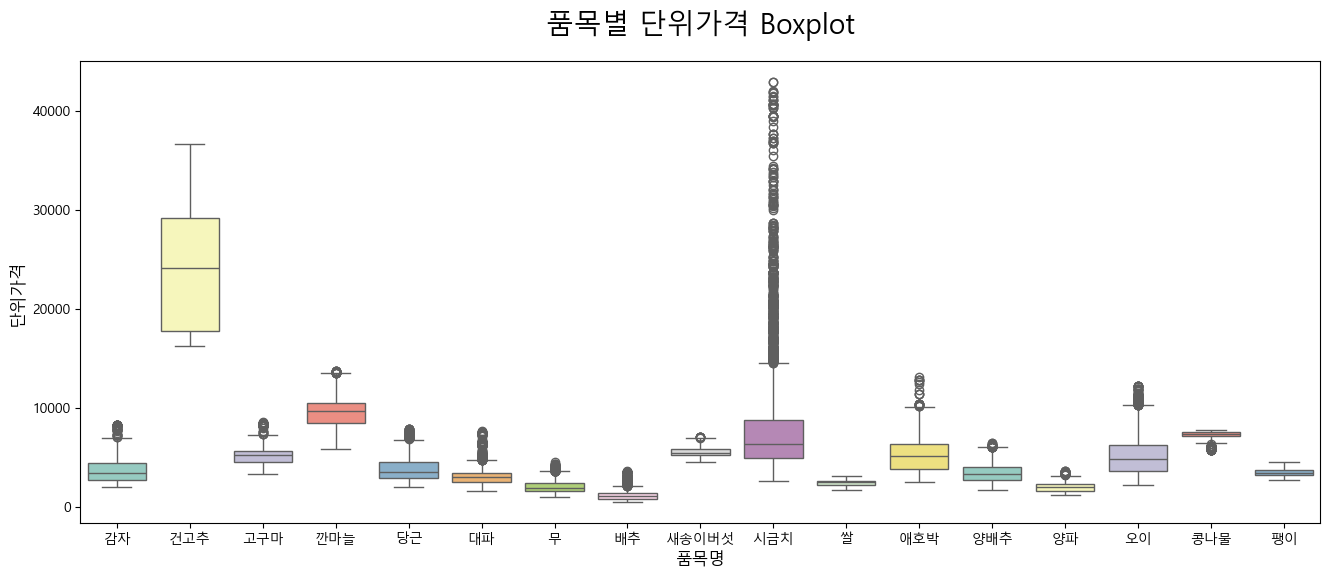

In [22]:
# 그래프 생성
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_eda, x='품목명', y='단위가격', palette="Set3")

# 축 레이블
plt.xlabel('품목명', fontsize=12)
plt.ylabel('단위가격', fontsize=12)

# 제목 추가
plt.title('품목별 단위가격 Boxplot', fontsize=20, pad=20)

# 그래프 저장 및 표시
plt.savefig('품목별_단위가격_Boxplot.png', dpi=200)
plt.show()

# 계절별 출하량이 최대인 품목

In [23]:
def get_season(month):
    """
    월을 계절로 바꾸는 함수
    3,4,5월 -> 봄
    6,7,8월 -> 여름
    9,10,11월 -> 가을
    11,1,2월 -> 겨울
    """
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'


In [34]:
monthly_maxqty_df = (
    df_eda.groupby(['품목명', '월'])['가락시장반입량']
    .mean()
    .reset_index()
    .sort_values(['품목명', '가락시장반입량'],ascending=False) # 내림차순 하고
    .drop_duplicates('품목명', keep='first') # 첫번째만 남기므로 가장 큰 값?
)

# 계절별로 품목 분류
monthly_maxqty_df['계절'] = monthly_maxqty_df['월'].apply(get_season)
seasons = monthly_maxqty_df.groupby('계절')['품목명'].apply(list).to_dict()
print('\n계절별 최저가 품목\n',
      seasons)
print('\n품목명별로 단위가격 평균값이 최저인 월\n',
      monthly_maxqty_df.sort_values('월')
     )


계절별 최저가 품목
 {'가을': ['양배추', '배추', '무'], '겨울': ['팽이', '콩나물', '애호박', '쌀', '시금치', '새송이버섯', '대파', '당근', '깐마늘', '고구마', '건고추'], '봄': ['양파'], '여름': ['오이', '감자']}

품목명별로 단위가격 평균값이 최저인 월
        품목명   월      가락시장반입량  계절
192     팽이   1          NaN  겨울
24     고구마   1   154.038023  겨울
36     깐마늘   1          NaN  겨울
48      당근   1   170.954717  겨울
60      대파   1   408.920000  겨울
108    시금치   1   152.652830  겨울
96   새송이버섯   1          NaN  겨울
132    애호박   1          NaN  겨울
180    콩나물   1          NaN  겨울
120      쌀   1          NaN  겨울
160     양파   5   964.563140   봄
173     오이   6   678.848057  여름
5       감자   6   491.837456  여름
80       무   9   735.872587  가을
152    양배추   9   319.169884  가을
94      배추  11  1029.263359  가을
23     건고추  12     1.416667  겨울


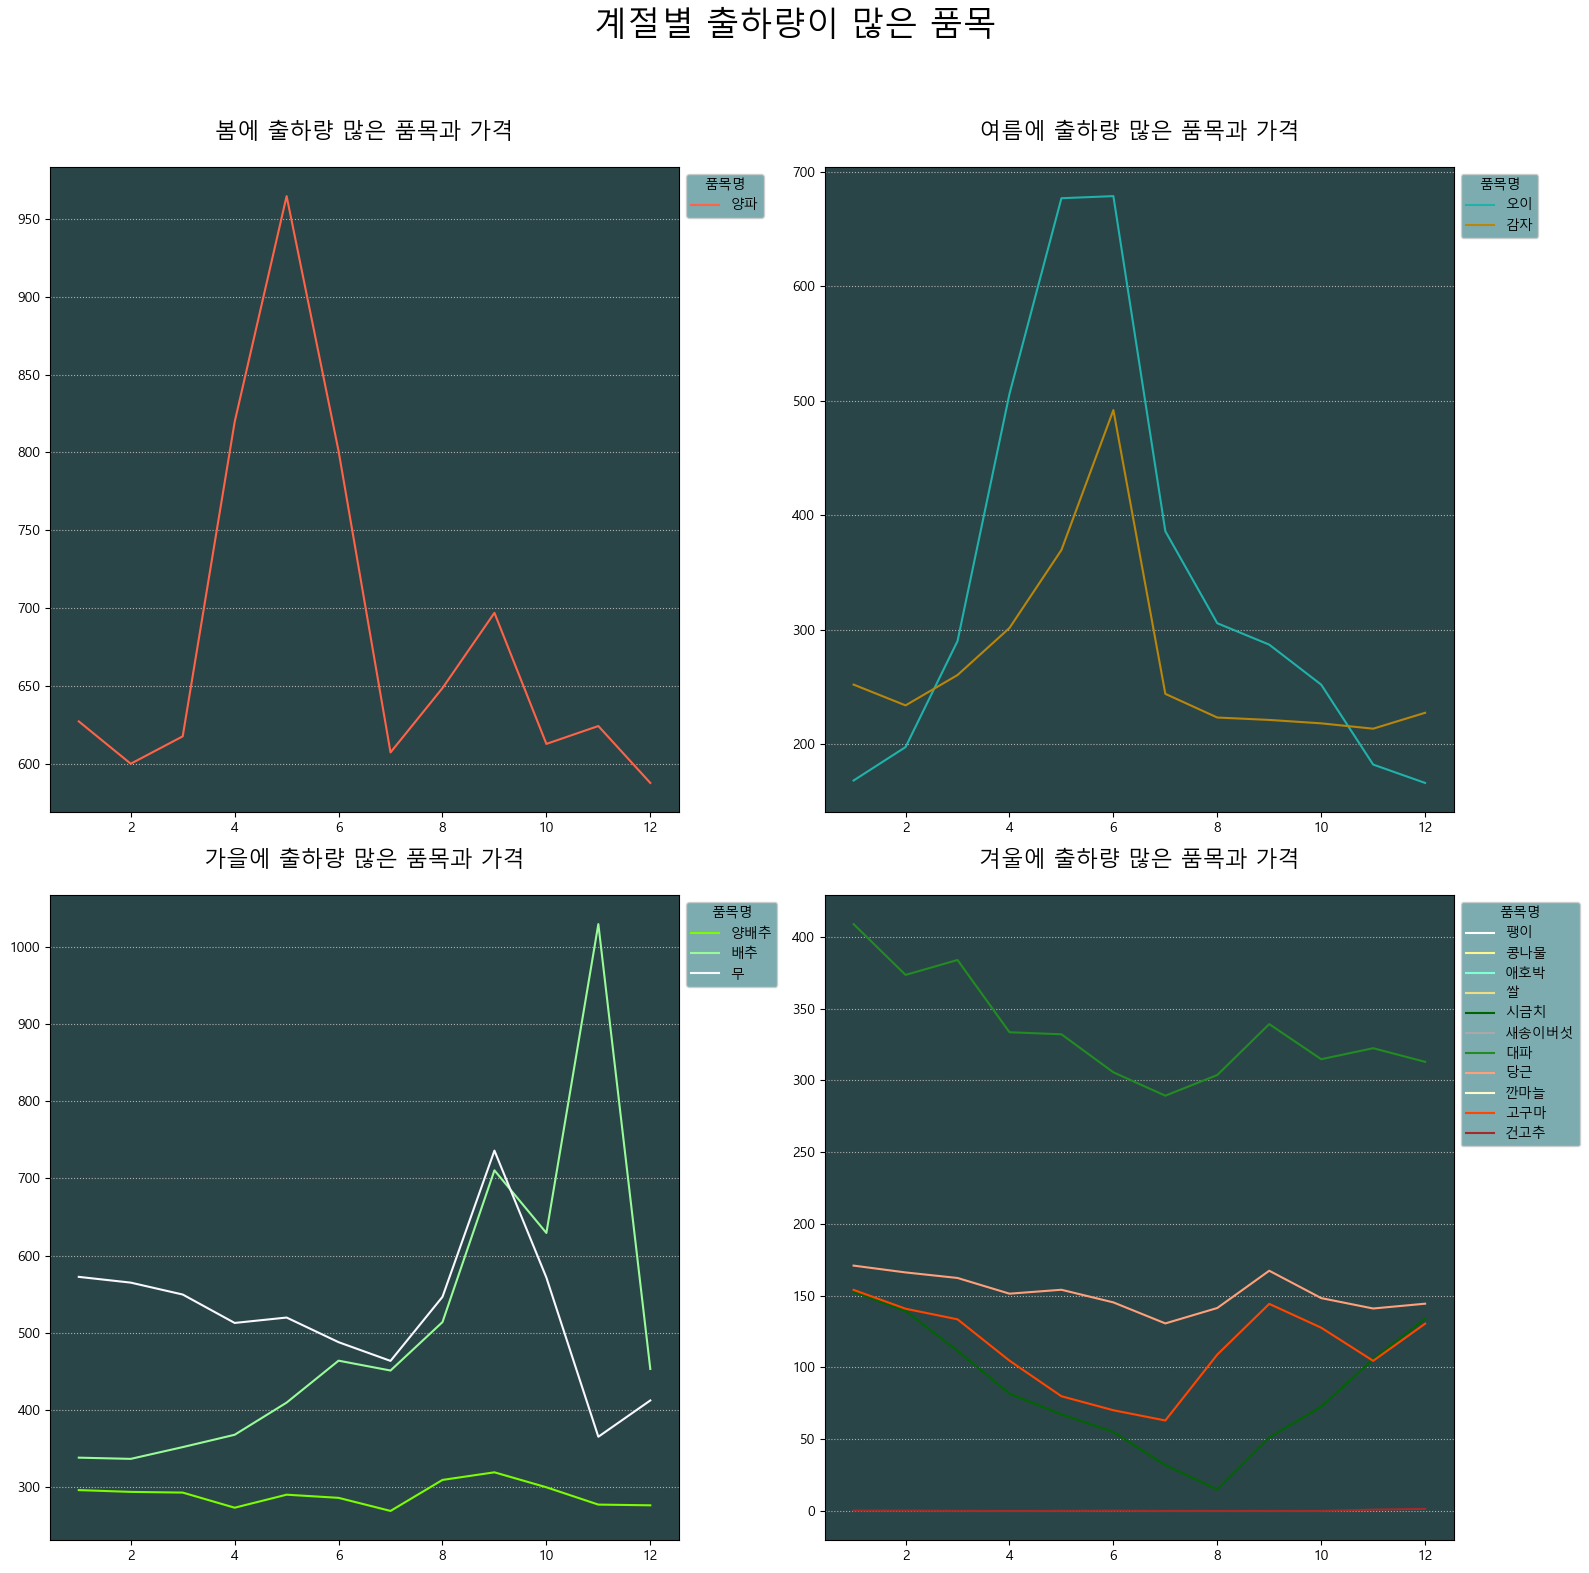

In [162]:
# 품목명과 색상을 매핑하는 딕셔너리 생성
품목명_list = list(df['품목명'].unique())
color_mapping = {
    '감자': '#b8860b',        # 감자의 금빛 갈색
    '건고추': '#a52a2a',      # 건고추의 깊은 적갈색
    '고구마': '#ff4500',      # 고구마의 선명한 주황색
    '깐마늘': '#fffacd',      # 마늘 속살의 연노란색
    '당근': '#ffa07a',        # 당근의 연한 주황색
    '대파': '#228b22',        # 대파의 짙은 녹색
    '무': '#f8f8ff',          # 무의 깨끗한 흰색
    '배추': '#98fb98',        # 배추의 옅은 연녹색
    '새송이버섯': '#a9a9a9',  # 새송이버섯의 중간 회색
    '시금치': '#006400',      # 시금치의 짙은 녹색
    '쌀': '#eedd82',          # 쌀의 밝은 금빛 베이지색
    '애호박': '#7fffd4',      # 애호박의 밝은 청록색
    '양배추': '#7cfc00',      # 양배추의 선명한 연두색
    '양파': '#ff6347',        # 양파의 붉은 황색
    '오이': '#20b2aa',        # 오이의 선명한 청록색
    '콩나물': '#fff68f',      # 콩나물의 부드러운 노란색
    '팽이': '#ffffff'         # 팽이버섯의 순백색
}
bar_colors = [color_mapping.get(item) for item in 품목명_list]


# 그래프 생성
fig = plt.figure(figsize=(16, 16))

# 계절별 그래프 위치 설정
subplot_positions = {
    '봄': 221,
    '여름': 222,
    '가을': 223,
    '겨울': 224
}

# 각 계절별 품목의 월별 평균 단위가격 추이 플롯
for season, pos in subplot_positions.items():
    ax = plt.subplot(pos)  # Subplot 객체 생성
    ax.set_facecolor('#2a4548')  # 서브플롯의 배경색 설정
    
    if season in seasons:
        for item in seasons[season]:
            x = df_eda[df_eda['품목명'] == item].groupby('월').agg(평균=('가락시장반입량', 'mean')).index
            y = df_eda[df_eda['품목명'] == item].groupby('월').agg(평균=('가락시장반입량', 'mean'))['평균']
            
            # 해당 품목의 색상 추출
            item_color = color_mapping.get(item, '#000000')  # 기본값은 검정색
            
            # 품목별 라인 플롯
            plt.plot(x, y, color=item_color, label=item)
            plt.grid(axis='y', ls=':')
        
        # 범례 설정
        legend = plt.legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left')
        legend.get_frame().set_facecolor('#5c979d')  # 범례의 배경색 설정
    
    # 제목 설정
    plt.title(f'{season}에 출하량 많은 품목과 가격', fontsize=16, pad=20)

# 전체 그래프 제목 및 레이아웃 설정
fig.suptitle('계절별 출하량이 많은 품목', size=24)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# 그래프 저장 및 출력
plt.savefig('계절별 출하량이 많은 품목.png', dpi=200)
plt.show()

# 월별 출하량 편차 품목 그래프

In [ ]:
pd.read_csv("

In [163]:
def get_qty_diff_rate(df, period, items):
    """
    df 데이터프레임을 period(년 or 월)별 평균 냈을 때 item(품목)별로 가락시장반입량 편차를 구하기
    Parameters:
    - df : DataFrame
    - period : 그룹화할 기간 (예: '년', '월', '분기' 등)
    - items : 품목명 리스트

    Returns:
    - DataFrame : 품목명과 가락시장반입량편차가 포함된 데이터프레임
    """
    data = []
    for item in items:
        # 품목별 데이터 필터링
        filtered_df = df_eda[df_eda['품목명'] == item]

        # 기간별 평균 단위가격 계산
        grouped = filtered_df.groupby(period).agg(평균=('가락시장반입량', 'mean'))

        # 최소, 최대, 전체 평균 계산
        monthly_min = grouped['평균'].min()
        monthly_max = grouped['평균'].max()
        all_mean = filtered_df['가락시장반입량'].mean()

        # 가격 편차율 계산
        qty_diff_rate = (monthly_max - monthly_min) / all_mean if all_mean != 0 else 0

        # 결과 저장
        data.append({'품목명': item, '가락시장반입량편차': qty_diff_rate})

    # 결과를 데이터프레임으로 반환
    return pd.DataFrame(data)


In [164]:
# 월별 평균가격 편차 구하기
df_monthly_qty_diff_rate = get_qty_diff_rate(df, '월', list(df['품목명'].unique()))

# 정렬 및 정리
df_monthly_qty_diff_rate.sort_values('가락시장반입량편차', ascending=False, inplace=True)

print('\n월별 평균가락시장반입량 편차 품목 내림차순\n', 
      df_monthly_qty_diff_rate
     )
print('\n월별 평균가락시장반입량 편차 50% 이상인 품목\n', 
      df_monthly_qty_diff_rate.loc[df_monthly_qty_diff_rate['가락시장반입량편차'] >= 0.5].sort_values('가락시장반입량편차', ascending = False)
     )
print('\n월별 평균가락시장반입량 편차 10% 이하인 품목\n', 
      df_monthly_qty_diff_rate.loc[df_monthly_qty_diff_rate['가락시장반입량편차'] <= 0.1].sort_values('가락시장반입량편차', ascending = False)
     )

print('\n월별 평균가락시장반입량 편차 품목 오름차순\n', 
      df_monthly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True)
     )


월별 평균가락시장반입량 편차 품목 내림차순
       품목명  가락시장반입량편차
1     건고추   5.026256
8     시금치   1.646989
13     오이   1.477393
7      배추   1.379975
0      감자   1.020527
2     고구마   0.808754
6       무   0.706701
12     양파   0.548816
5      대파   0.365499
4      당근   0.265517
11    양배추   0.172384
3     깐마늘        NaN
9       쌀        NaN
10    애호박        NaN
14    콩나물        NaN
15  새송이버섯        NaN
16     팽이        NaN

월별 평균가락시장반입량 편차 50% 이상인 품목
     품목명  가락시장반입량편차
1   건고추   5.026256
8   시금치   1.646989
13   오이   1.477393
7    배추   1.379975
0    감자   1.020527
2   고구마   0.808754
6     무   0.706701
12   양파   0.548816

월별 평균가락시장반입량 편차 10% 이하인 품목
 Empty DataFrame
Columns: [품목명, 가락시장반입량편차]
Index: []

월별 평균가락시장반입량 편차 품목 오름차순
       품목명  가락시장반입량편차
11    양배추   0.172384
4      당근   0.265517
5      대파   0.365499
12     양파   0.548816
6       무   0.706701
2     고구마   0.808754
0      감자   1.020527
7      배추   1.379975
13     오이   1.477393
8     시금치   1.646989
1     건고추   5.026256
3     깐마늘        NaN
9       쌀       

In [210]:
# df_eda[df_eda['품목명'] == '건고추'].groupby('월').agg(평균=('가락시장반입량', 'mean'))

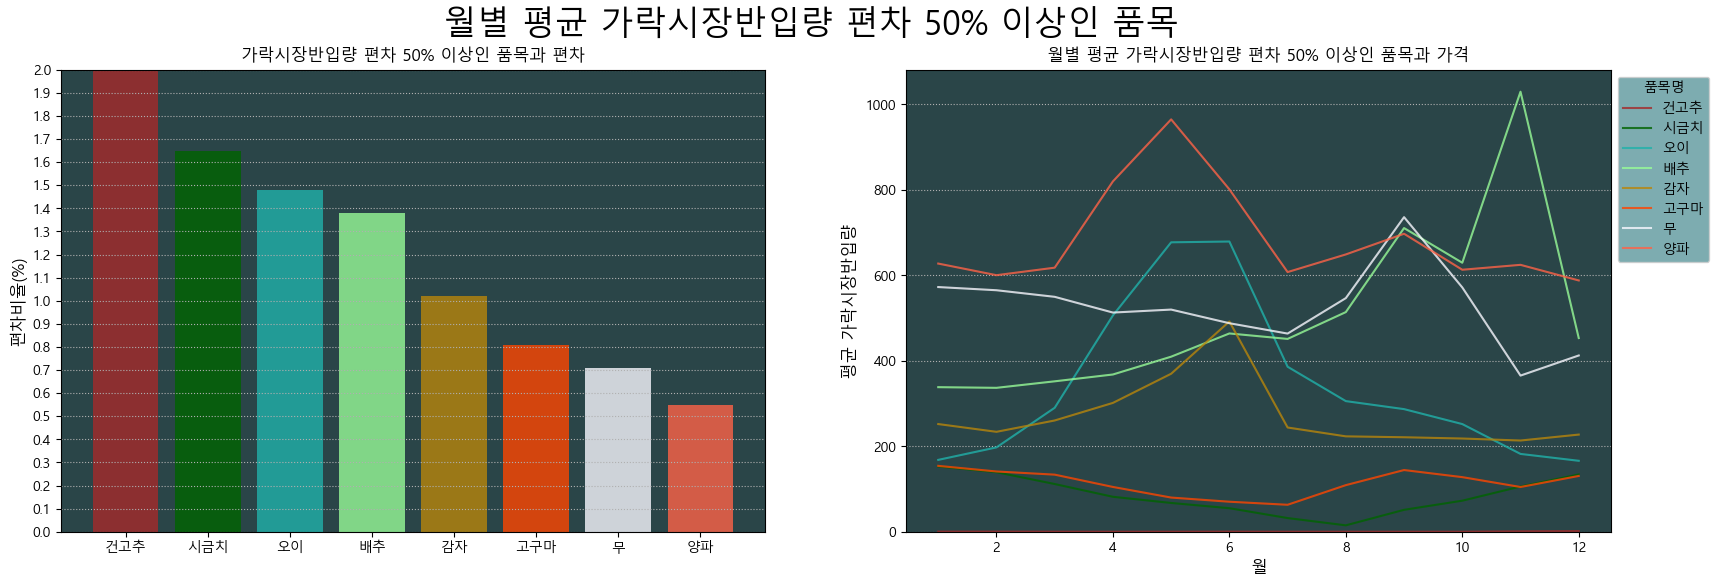

In [215]:
# 품목명과 색상을 매핑하는 딕셔너리 생성
품목명_list = list(df['품목명'].unique())
color_mapping = {
    '감자': '#b8860b',        # 감자의 금빛 갈색
    '건고추': '#a52a2a',      # 건고추의 깊은 적갈색
    '고구마': '#ff4500',      # 고구마의 선명한 주황색
    '깐마늘': '#fffacd',      # 마늘 속살의 연노란색
    '당근': '#ffa07a',        # 당근의 연한 주황색
    '대파': '#228b22',        # 대파의 짙은 녹색
    '무': '#f8f8ff',          # 무의 깨끗한 흰색
    '배추': '#98fb98',        # 배추의 옅은 연녹색
    '새송이버섯': '#a9a9a9',  # 새송이버섯의 중간 회색
    '시금치': '#006400',      # 시금치의 짙은 녹색
    '쌀': '#eedd82',          # 쌀의 밝은 금빛 베이지색
    '애호박': '#7fffd4',      # 애호박의 밝은 청록색
    '양배추': '#7cfc00',      # 양배추의 선명한 연두색
    '양파': '#ff6347',        # 양파의 붉은 황색
    '오이': '#20b2aa',        # 오이의 선명한 청록색
    '콩나물': '#fff68f',      # 콩나물의 부드러운 노란색
    '팽이': '#ffffff'         # 팽이버섯의 순백색
}
bar_colors = [color_mapping.get(item) for item in 품목명_list]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x0 = df_monthly_qty_diff_rate.loc[df_monthly_qty_diff_rate['가락시장반입량편차'] >= 0.5].sort_values('가락시장반입량편차', ascending=False)['품목명']
y0 = df_monthly_qty_diff_rate.loc[df_monthly_qty_diff_rate['가락시장반입량편차'] >= 0.5].sort_values('가락시장반입량편차', ascending=False)['가락시장반입량편차']
x0_colors = [color_mapping[item] for item in x0]  # x0에 해당하는 품목명별 색상 생성
ax[0].bar(x0, y0, color=x0_colors, alpha=0.8)

ax[0].set_facecolor('#2a4548')
ax[0].set_ylim(0, 2)
ax[0].set_yticks(np.arange(0, 2.1, step=0.1))
ax[0].grid(axis='y', ls=':')
ax[0].set_ylabel('편차비율(%)', fontsize=12)
ax[0].set_title('가락시장반입량 편차 50% 이상인 품목과 편차')

# ax[1]
품목_list = df_monthly_qty_diff_rate.loc[df_monthly_qty_diff_rate['가락시장반입량편차'] >= 0.5, '품목명'].unique()

for item in 품목_list:
    # 월별 평균 계산
    x = df_eda[df_eda['품목명'] == item].groupby('월').agg(평균=('가락시장반입량', 'mean')).index
    y = df_eda[df_eda['품목명'] == item].groupby('월').agg(평균=('가락시장반입량', 'mean'))['평균']
    
    # 데이터 플롯
    ax[1].plot(x, y, color=color_mapping[item], alpha=0.8, label=item)

ax[1].set_facecolor('#2a4548')
ax[1].grid(axis='y', ls=':')
ax[1].set_xlabel('월', fontsize=12)
ax[1].set_ylabel('평균 가락시장반입량', fontsize=12)
ax[1].set_ylim(0)
ax[1].set_title('월별 평균 가락시장반입량 편차 50% 이상인 품목과 가격')
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left', facecolor='#5c979d')

# 제목 및 저장
fig.suptitle('월별 평균 가락시장반입량 편차 50% 이상인 품목', fontsize=24)
fig.savefig('월별 평균 가락시장반입량 편차 50% 이상인 품목.png', dpi=200)
plt.show()

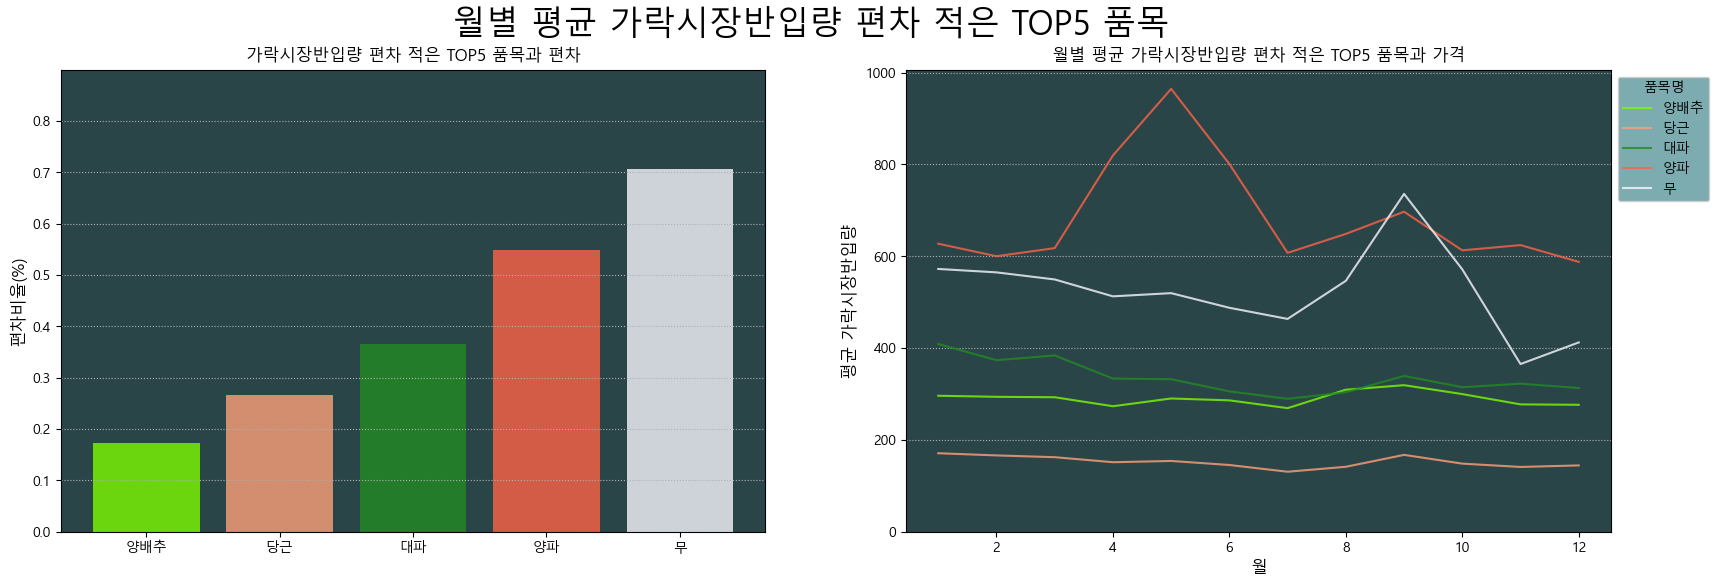

In [167]:
# 품목명과 색상을 매핑하는 딕셔너리 생성
품목명_list = list(df['품목명'].unique())
color_mapping = {
    '감자': '#b8860b',        # 감자의 금빛 갈색
    '건고추': '#a52a2a',      # 건고추의 깊은 적갈색
    '고구마': '#ff4500',      # 고구마의 선명한 주황색
    '깐마늘': '#fffacd',      # 마늘 속살의 연노란색
    '당근': '#ffa07a',        # 당근의 연한 주황색
    '대파': '#228b22',        # 대파의 짙은 녹색
    '무': '#f8f8ff',          # 무의 깨끗한 흰색
    '배추': '#98fb98',        # 배추의 옅은 연녹색
    '새송이버섯': '#a9a9a9',  # 새송이버섯의 중간 회색
    '시금치': '#006400',      # 시금치의 짙은 녹색
    '쌀': '#eedd82',          # 쌀의 밝은 금빛 베이지색
    '애호박': '#7fffd4',      # 애호박의 밝은 청록색
    '양배추': '#7cfc00',      # 양배추의 선명한 연두색
    '양파': '#ff6347',        # 양파의 붉은 황색
    '오이': '#20b2aa',        # 오이의 선명한 청록색
    '콩나물': '#fff68f',      # 콩나물의 부드러운 노란색
    '팽이': '#ffffff'         # 팽이버섯의 순백색
}
bar_colors = [color_mapping.get(item) for item in 품목명_list]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x0 = df_monthly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True).head(5)['품목명']
y0 = df_monthly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True).head(5)['가락시장반입량편차']
x0_colors = [color_mapping[item] for item in x0]  # x0에 해당하는 품목명별 색상 생성
ax[0].bar(x0, y0, color=x0_colors, alpha=0.8)

ax[0].set_facecolor('#2a4548')
ax[0].set_ylim(0, 0.9)
ax[0].set_yticks(np.arange(0, 0.9, step=0.1))
ax[0].grid(axis='y', ls=':')
ax[0].set_ylabel('편차비율(%)', fontsize=12)
ax[0].set_title('가락시장반입량 편차 적은 TOP5 품목과 편차')

# ax[1]
품목_list = df_monthly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True).head(5)['품목명'].unique()

for item in 품목_list:
    # 월별 평균 계산
    x = df_eda[df_eda['품목명'] == item].groupby('월').agg(평균=('가락시장반입량', 'mean')).index
    y = df_eda[df_eda['품목명'] == item].groupby('월').agg(평균=('가락시장반입량', 'mean'))['평균']
    
    # 데이터 플롯
    ax[1].plot(x, y, color=color_mapping[item], alpha=0.8, label=item)

ax[1].set_facecolor('#2a4548')
ax[1].grid(axis='y', ls=':')
ax[1].set_xlabel('월', fontsize=12)
ax[1].set_ylabel('평균 가락시장반입량', fontsize=12)
ax[1].set_ylim(0)
ax[1].set_title('월별 평균 가락시장반입량 편차 적은 TOP5 품목과 가격')
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left', facecolor='#5c979d')

# 제목 및 저장
fig.suptitle('월별 평균 가락시장반입량 편차 적은 TOP5 품목', fontsize=24)
fig.savefig('월별 평균 가락시장반입량 편차 적은 TOP5 품목.png', dpi=200)
plt.show()

# 연도별 출하량 편차 품목 그래프

In [211]:
# 연도별 평균가격 편차 구하기
df_yearly_qty_diff_rate = get_qty_diff_rate(df, '년', list(df['품목명'].unique()))

# 정렬 및 정리
df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending=False, inplace=True)

print('\연도별 평균가락시장반입량 편차 품목 내림차순\n', 
      df_yearly_qty_diff_rate
     )
print('\연도별 평균가락시장반입량 편차 50% 이상인 품목\n', 
      df_yearly_qty_diff_rate.loc[df_yearly_qty_diff_rate['가락시장반입량편차'] >= 0.5].sort_values('가락시장반입량편차', ascending = False)
     )
print('\연도별 평균가락시장반입량 편차 10% 이하인 품목\n', 
      df_yearly_qty_diff_rate.loc[df_yearly_qty_diff_rate['가락시장반입량편차'] <= 0.1].sort_values('가락시장반입량편차', ascending = False)
     )


print('\연도별 평균가락시장반입량 편차 품목 내림차순\n', 
      df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = False)
     )

print('\연도별 평균가락시장반입량 편차 품목 오름차순\n', 
      df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True)
     )

\연도별 평균가락시장반입량 편차 품목 내림차순
       품목명  가락시장반입량편차
1     건고추   2.854669
8     시금치   0.491925
7      배추   0.374630
2     고구마   0.332188
12     양파   0.235107
4      당근   0.214974
11    양배추   0.203539
6       무   0.173219
0      감자   0.159094
13     오이   0.131902
5      대파   0.066276
3     깐마늘        NaN
9       쌀        NaN
10    애호박        NaN
14    콩나물        NaN
15  새송이버섯        NaN
16     팽이        NaN
\연도별 평균가락시장반입량 편차 50% 이상인 품목
    품목명  가락시장반입량편차
1  건고추   2.854669
\연도별 평균가락시장반입량 편차 10% 이하인 품목
   품목명  가락시장반입량편차
5  대파   0.066276
\연도별 평균가락시장반입량 편차 품목 내림차순
       품목명  가락시장반입량편차
1     건고추   2.854669
8     시금치   0.491925
7      배추   0.374630
2     고구마   0.332188
12     양파   0.235107
4      당근   0.214974
11    양배추   0.203539
6       무   0.173219
0      감자   0.159094
13     오이   0.131902
5      대파   0.066276
3     깐마늘        NaN
9       쌀        NaN
10    애호박        NaN
14    콩나물        NaN
15  새송이버섯        NaN
16     팽이        NaN
\연도별 평균가락시장반입량 편차 품목 오름차순
       품목명  가락시장반입량편차
5      대파   

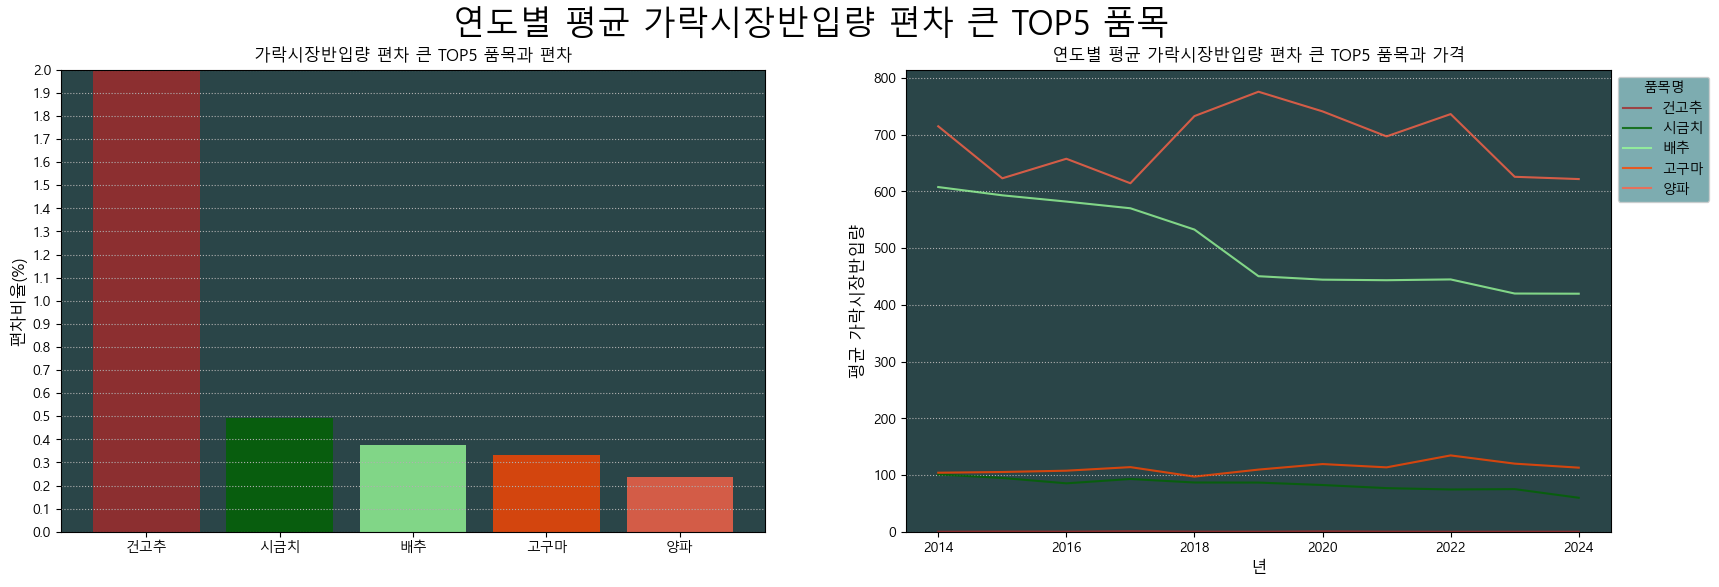

In [217]:
# 품목명과 색상을 매핑하는 딕셔너리 생성
품목명_list = list(df['품목명'].unique())
color_mapping = {
    '감자': '#b8860b',        # 감자의 금빛 갈색
    '건고추': '#a52a2a',      # 건고추의 깊은 적갈색
    '고구마': '#ff4500',      # 고구마의 선명한 주황색
    '깐마늘': '#fffacd',      # 마늘 속살의 연노란색
    '당근': '#ffa07a',        # 당근의 연한 주황색
    '대파': '#228b22',        # 대파의 짙은 녹색
    '무': '#f8f8ff',          # 무의 깨끗한 흰색
    '배추': '#98fb98',        # 배추의 옅은 연녹색
    '새송이버섯': '#a9a9a9',  # 새송이버섯의 중간 회색
    '시금치': '#006400',      # 시금치의 짙은 녹색
    '쌀': '#eedd82',          # 쌀의 밝은 금빛 베이지색
    '애호박': '#7fffd4',      # 애호박의 밝은 청록색
    '양배추': '#7cfc00',      # 양배추의 선명한 연두색
    '양파': '#ff6347',        # 양파의 붉은 황색
    '오이': '#20b2aa',        # 오이의 선명한 청록색
    '콩나물': '#fff68f',      # 콩나물의 부드러운 노란색
    '팽이': '#ffffff'         # 팽이버섯의 순백색
}
bar_colors = [color_mapping.get(item) for item in 품목명_list]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x0 = df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = False).head(5)['품목명']
y0 = df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = False).head(5)['가락시장반입량편차']
x0_colors = [color_mapping[item] for item in x0]  # x0에 해당하는 품목명별 색상 생성
ax[0].bar(x0, y0, color=x0_colors, alpha=0.8)

ax[0].set_facecolor('#2a4548')
ax[0].set_ylim(0, 2)
ax[0].set_yticks(np.arange(0, 2.1, step=0.1))
ax[0].grid(axis='y', ls=':')
ax[0].set_ylabel('편차비율(%)', fontsize=12)
ax[0].set_title('가락시장반입량 편차 큰 TOP5 품목과 편차')

# ax[1]
품목_list = df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = False).head(5)['품목명'].unique()

for item in 품목_list:
    # 월별 평균 계산
    x = df_eda[df_eda['품목명'] == item].groupby('년').agg(평균=('가락시장반입량', 'mean')).index
    y = df_eda[df_eda['품목명'] == item].groupby('년').agg(평균=('가락시장반입량', 'mean'))['평균']
    
    # 데이터 플롯
    ax[1].plot(x, y, color=color_mapping[item], alpha=0.8, label=item)

ax[1].set_facecolor('#2a4548')
ax[1].grid(axis='y', ls=':')
ax[1].set_xlabel('년', fontsize=12)
ax[1].set_ylabel('평균 가락시장반입량', fontsize=12)
ax[1].set_ylim(0)
ax[1].set_title('연도별 평균 가락시장반입량 편차 큰 TOP5 품목과 가격')
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left', facecolor='#5c979d')

# 제목 및 저장
fig.suptitle('연도별 평균 가락시장반입량 편차 큰 TOP5 품목', fontsize=24)
fig.savefig('연도별 평균 가락시장반입량 편차 큰 TOP5 품목.png', dpi=200)
plt.show()

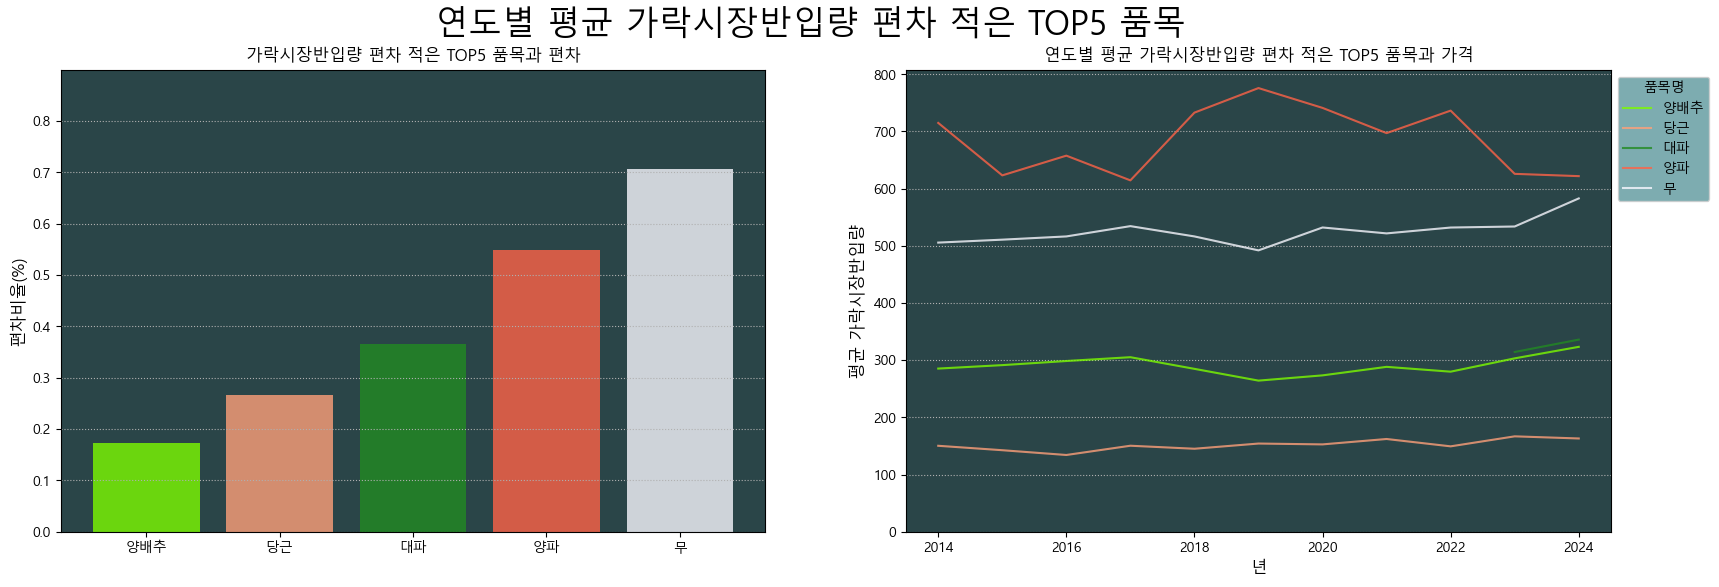

In [206]:
# 품목명과 색상을 매핑하는 딕셔너리 생성
품목명_list = list(df['품목명'].unique())
color_mapping = {
    '감자': '#b8860b',        # 감자의 금빛 갈색
    '건고추': '#a52a2a',      # 건고추의 깊은 적갈색
    '고구마': '#ff4500',      # 고구마의 선명한 주황색
    '깐마늘': '#fffacd',      # 마늘 속살의 연노란색
    '당근': '#ffa07a',        # 당근의 연한 주황색
    '대파': '#228b22',        # 대파의 짙은 녹색
    '무': '#f8f8ff',          # 무의 깨끗한 흰색
    '배추': '#98fb98',        # 배추의 옅은 연녹색
    '새송이버섯': '#a9a9a9',  # 새송이버섯의 중간 회색
    '시금치': '#006400',      # 시금치의 짙은 녹색
    '쌀': '#eedd82',          # 쌀의 밝은 금빛 베이지색
    '애호박': '#7fffd4',      # 애호박의 밝은 청록색
    '양배추': '#7cfc00',      # 양배추의 선명한 연두색
    '양파': '#ff6347',        # 양파의 붉은 황색
    '오이': '#20b2aa',        # 오이의 선명한 청록색
    '콩나물': '#fff68f',      # 콩나물의 부드러운 노란색
    '팽이': '#ffffff'         # 팽이버섯의 순백색
}
bar_colors = [color_mapping.get(item) for item in 품목명_list]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x0 = df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True).head(5)['품목명']
y0 = df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True).head(5)['가락시장반입량편차']
x0_colors = [color_mapping[item] for item in x0]  # x0에 해당하는 품목명별 색상 생성
ax[0].bar(x0, y0, color=x0_colors, alpha=0.8)

ax[0].set_facecolor('#2a4548')
ax[0].set_ylim(0, 0.9)
ax[0].set_yticks(np.arange(0, 0.9, step=0.1))
ax[0].grid(axis='y', ls=':')
ax[0].set_ylabel('편차비율(%)', fontsize=12)
ax[0].set_title('가락시장반입량 편차 적은 TOP5 품목과 편차')

# ax[1]
품목_list = df_yearly_qty_diff_rate.sort_values('가락시장반입량편차', ascending = True).head(5)['품목명'].unique()

for item in 품목_list:
    # 월별 평균 계산
    x = df_eda[df_eda['품목명'] == item].groupby('년').agg(평균=('가락시장반입량', 'mean')).index
    y = df_eda[df_eda['품목명'] == item].groupby('년').agg(평균=('가락시장반입량', 'mean'))['평균']
    
    # 데이터 플롯
    ax[1].plot(x, y, color=color_mapping[item], alpha=0.8, label=item)

ax[1].set_facecolor('#2a4548')
ax[1].grid(axis='y', ls=':')
ax[1].set_xlabel('년', fontsize=12)
ax[1].set_ylabel('평균 가락시장반입량', fontsize=12)
ax[1].set_ylim(0)
ax[1].set_title('연도별 평균 가락시장반입량 편차 적은 TOP5 품목과 가격')
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left', facecolor='#5c979d')

# 제목 및 저장
fig.suptitle('연도별 평균 가락시장반입량 편차 적은 TOP5 품목', fontsize=24)
fig.savefig('연도별 평균 가락시장반입량 편차 적은 TOP5 품목.png', dpi=200)
plt.show()

# 경제변수와 상관 있는 품목 가격

In [176]:
df_eda

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,년월,년,월
0,2014-01-02,감자,202.0,NaN,442669.9,2.5,5210.0,1706.0,1050.0,2020.0,2014-01,2014,1
1,2014-01-03,감자,208.0,376.0,442669.9,2.5,5210.0,1707.0,1055.0,2080.0,2014-01,2014,1
2,2014-01-04,감자,208.0,262.0,442669.9,2.5,5210.0,1708.0,1059.0,2080.0,2014-01,2014,1
3,2014-01-05,감자,208.0,NaN,442669.9,2.5,5210.0,1708.0,1062.0,2080.0,2014-01,2014,1
4,2014-01-06,감자,281.0,285.0,442669.9,2.5,5210.0,1708.0,1065.0,2810.0,2014-01,2014,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65115,2024-12-01,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,529.0,2024-12,2024,12
65116,2024-12-02,팽이,529.0,NaN,NaN,NaN,NaN,NaN,NaN,529.0,2024-12,2024,12
65117,2024-12-03,팽이,530.0,NaN,NaN,NaN,NaN,NaN,NaN,530.0,2024-12,2024,12
65118,2024-12-04,팽이,534.0,NaN,NaN,NaN,NaN,NaN,NaN,534.0,2024-12,2024,12


In [177]:
list(df_eda['품목명'].unique())

['감자',
 '건고추',
 '고구마',
 '깐마늘',
 '당근',
 '대파',
 '무',
 '배추',
 '새송이버섯',
 '시금치',
 '쌀',
 '애호박',
 '양배추',
 '양파',
 '오이',
 '콩나물',
 '팽이']

In [178]:
# '날짜'를 인덱스로 설정
df_eda_reindex = df_eda.set_index('날짜')

# '품목명'별 '평균가격'을 컬럼으로 변환
df_eda_pivot = df_eda_reindex.pivot_table(index='날짜', columns='품목명', values='평균가격')
df_eda_pivot

품목명,감자,건고추,고구마,깐마늘,당근,대파,무,배추,새송이버섯,시금치,쌀,애호박,양배추,양파,오이,콩나물,팽이
날짜,,,,,,,,,,,,,,,,,
2014-01-02,202.0,10018.0,3717.0,6746.0,2625.0,2077.0,1358.0,2515.0,643.0,354.0,46082.0,1502.0,2349.0,1779.0,10572.0,NaN,614.0
2014-01-03,208.0,10018.0,3816.0,6693.0,2606.0,2079.0,1358.0,2515.0,633.0,349.0,45964.0,1502.0,2349.0,1759.0,10551.0,NaN,624.0
2014-01-04,208.0,10018.0,3816.0,6693.0,2606.0,2079.0,1358.0,2515.0,633.0,349.0,45964.0,1502.0,2349.0,1759.0,10551.0,NaN,624.0
2014-01-05,208.0,10018.0,3816.0,6693.0,2606.0,2079.0,1358.0,2515.0,633.0,349.0,45964.0,1502.0,2349.0,1759.0,10551.0,NaN,624.0
2014-01-06,281.0,10018.0,3895.0,6518.0,2663.0,2078.0,1445.0,2530.0,625.0,348.0,45964.0,1490.0,2349.0,1746.0,10610.0,NaN,626.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,527.0,NaN,NaN,NaN,NaN,NaN,NaN,2381.0,529.0
2024-12-02,346.0,18457.0,5288.0,8872.0,6753.0,3806.0,2993.0,3478.0,534.0,967.0,54760.0,1761.0,4614.0,1975.0,17921.0,2412.0,529.0
2024-12-03,351.0,18218.0,5318.0,8878.0,6755.0,3803.0,3044.0,3421.0,538.0,958.0,54656.0,1761.0,4598.0,2010.0,17854.0,2412.0,530.0


In [172]:
df_경제변수

,날짜,GDP,한은금리,최저시급,경유가격,환율
0,2014-01-02,442669.9,2.5,5210,1706.27,1050.3
1,2014-01-03,442669.9,2.5,5210,1707.15,1055.2
2,2014-01-04,442669.9,2.5,5210,1707.61,1058.6
3,2014-01-05,442669.9,2.5,5210,1707.56,1062.0
4,2014-01-06,442669.9,2.5,5210,1707.80,1065.4
...,...,...,...,...,...,...
3910,2024-09-26,572413.3,3.5,9860,1429.96,1327.2
3911,2024-09-27,572413.3,3.5,9860,1427.87,1318.6
3912,2024-09-28,572413.3,3.5,9860,1425.01,1315.0
3913,2024-09-29,572413.3,3.5,9860,1423.72,1311.4


In [180]:
df_eda_pivot_economy_merged = pd.merge(df_eda_pivot, df_경제변수, on='날짜', how='left')
df_eda_pivot_economy_merged

,날짜,감자,건고추,고구마,깐마늘,당근,대파,무,배추,새송이버섯,...,양배추,양파,오이,콩나물,팽이,GDP,한은금리,최저시급,경유가격,환율
0,2014-01-02,202.0,10018.0,3717.0,6746.0,2625.0,2077.0,1358.0,2515.0,643.0,...,2349.0,1779.0,10572.0,NaN,614.0,442669.9,2.5,5210.0,1706.27,1050.3
1,2014-01-03,208.0,10018.0,3816.0,6693.0,2606.0,2079.0,1358.0,2515.0,633.0,...,2349.0,1759.0,10551.0,NaN,624.0,442669.9,2.5,5210.0,1707.15,1055.2
2,2014-01-04,208.0,10018.0,3816.0,6693.0,2606.0,2079.0,1358.0,2515.0,633.0,...,2349.0,1759.0,10551.0,NaN,624.0,442669.9,2.5,5210.0,1707.61,1058.6
3,2014-01-05,208.0,10018.0,3816.0,6693.0,2606.0,2079.0,1358.0,2515.0,633.0,...,2349.0,1759.0,10551.0,NaN,624.0,442669.9,2.5,5210.0,1707.56,1062.0
4,2014-01-06,281.0,10018.0,3895.0,6518.0,2663.0,2078.0,1445.0,2530.0,625.0,...,2349.0,1746.0,10610.0,NaN,626.0,442669.9,2.5,5210.0,1707.80,1065.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3986,2024-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,527.0,...,NaN,NaN,NaN,2381.0,529.0,NaN,NaN,NaN,NaN,NaN
3987,2024-12-02,346.0,18457.0,5288.0,8872.0,6753.0,3806.0,2993.0,3478.0,534.0,...,4614.0,1975.0,17921.0,2412.0,529.0,NaN,NaN,NaN,NaN,NaN
3988,2024-12-03,351.0,18218.0,5318.0,8878.0,6755.0,3803.0,3044.0,3421.0,538.0,...,4598.0,2010.0,17854.0,2412.0,530.0,NaN,NaN,NaN,NaN,NaN
3989,2024-12-04,350.0,18218.0,5313.0,8957.0,6742.0,3841.0,3075.0,3396.0,535.0,...,4517.0,1984.0,17813.0,2421.0,534.0,NaN,NaN,NaN,NaN,NaN


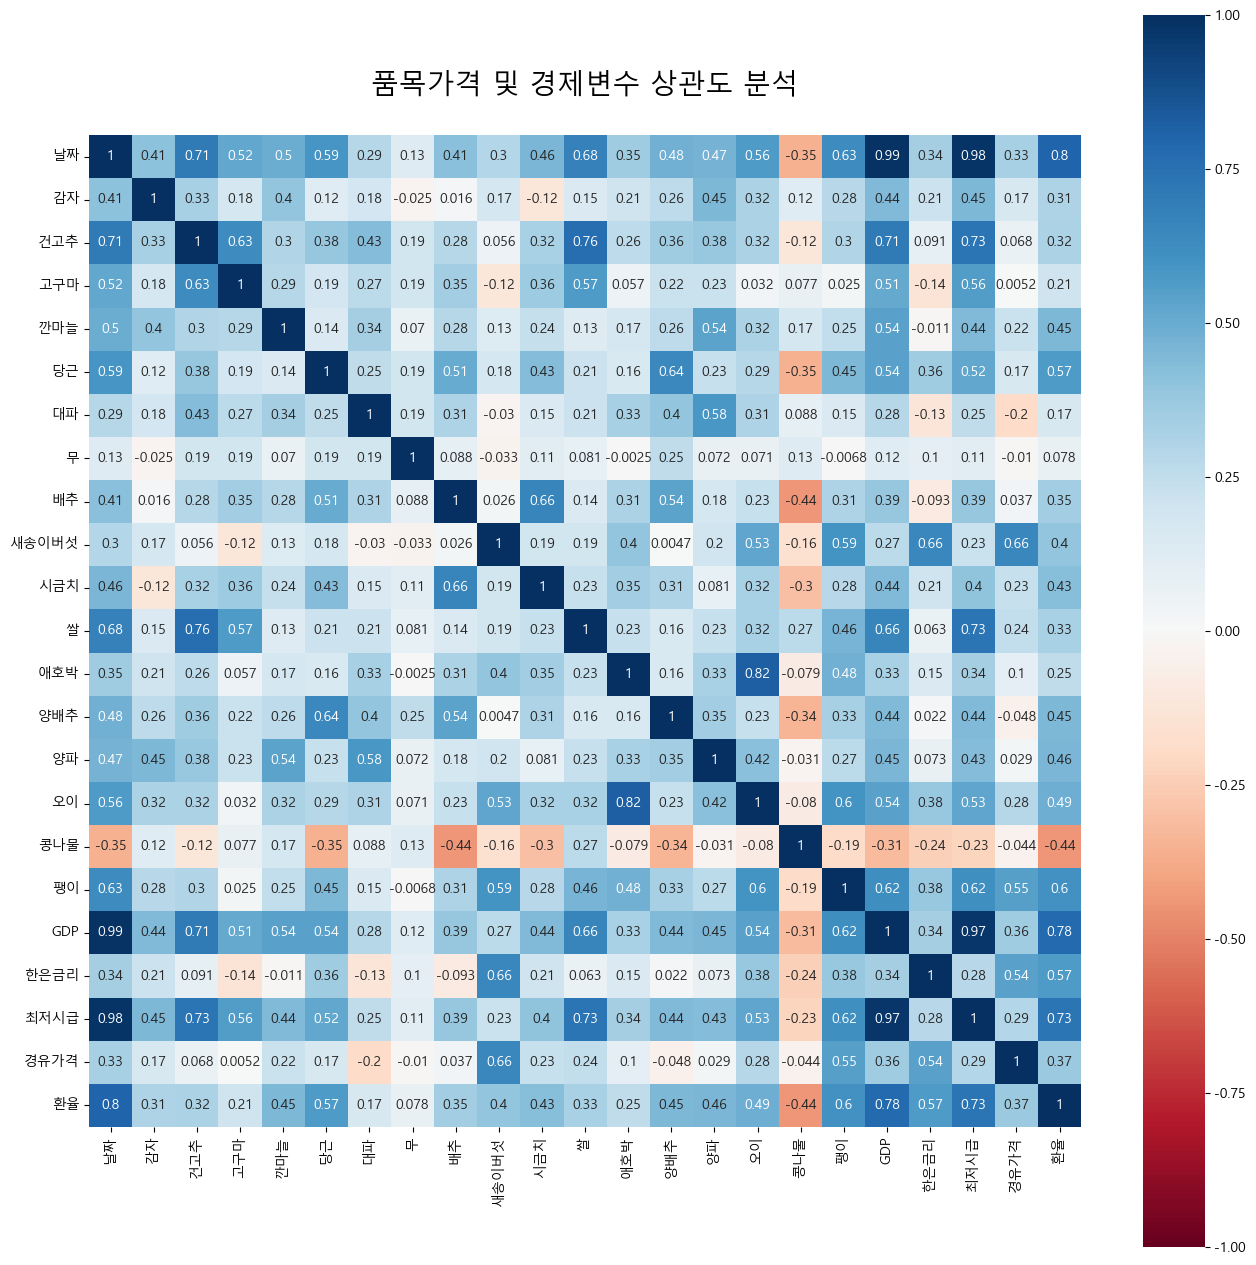

In [201]:
df_eda_pivot_economy_merged_corr = df_eda_pivot_economy_merged.corr() # , '년월', '년', '월'
# 시본 히트맵 사각형 그리기
# 히트맵 그리기
plt.figure(figsize=(16, 16))
sns.heatmap(
    df_eda_pivot_economy_merged_corr, 
    annot=True, 
    cmap='RdBu',  # -1은 파란색, 1은 빨간색
    vmin=-1,      # 컬러맵 최소값
    vmax=1,       # 컬러맵 최대값
    center=0,     # 0을 기준으로 색상 분리
    annot_kws={"size": 10},  # 주석 글자 크기
    square=True   # 정사각형 셀 유지
)
plt.title('품목가격 및 경제변수 상관도 분석', fontsize = 20, pad = 30)
# 그래프 저장 및 출력
plt.savefig('품목가격_경제변수_상관도_분석.png', dpi=200)
plt.show()

In [186]:
df_경제변수.columns.unique()

Index(['날짜', 'GDP', '한은금리', '최저시급', '경유가격', '환율'], dtype='object')

In [200]:
df_eda_pivot_corr_iloc = df_eda_pivot_economy_merged_corr.iloc[1:18,-5:]
# df_eda_pivot_corr_iloc
df_eda_pivot_corr_iloc[df_eda_pivot_corr_iloc >= 0.5]

# 건고추, 고구마, 쌀, 오이, 당근 ~ GDP, 최저시급
# 깐마늘 ~ GDP
# 새송이버섯 ~ 금리, 경유
# 팽이 ~ GDP, 최저시급, 경유

,GDP,한은금리,최저시급,경유가격,환율
감자,NaN,NaN,NaN,NaN,NaN
건고추,0.707267,NaN,0.728944,NaN,NaN
고구마,0.510360,NaN,0.557883,NaN,NaN
깐마늘,0.540399,NaN,NaN,NaN,NaN
당근,0.541069,NaN,0.517776,NaN,0.566983
대파,NaN,NaN,NaN,NaN,NaN
무,NaN,NaN,NaN,NaN,NaN
배추,NaN,NaN,NaN,NaN,NaN
새송이버섯,NaN,0.655097,NaN,0.655642,NaN
시금치,NaN,NaN,NaN,NaN,NaN


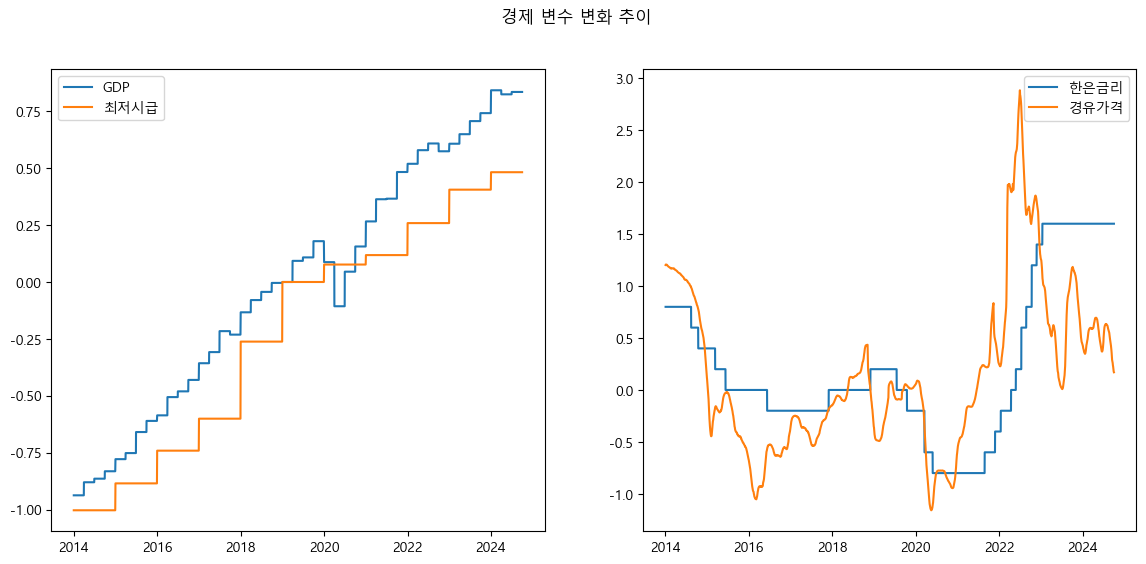

In [36]:
from sklearn.preprocessing import RobustScaler

# 날짜 제외한 수치 데이터
# numeric_data = df_경제변수.drop(columns=['날짜'])
numeric_data = df_경제변수[['GDP', '한은금리', '최저시급', '경유가격', '환율']]

scaler = RobustScaler()

scaled_data = scaler.fit_transform(numeric_data)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_data.columns)
# scaled_df
# 날짜 열과 병합
scaled_df = pd.concat([df_경제변수['날짜'], scaled_df], axis=1)
# scaled_df

# 연도별
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# ax[0]
x00 = scaled_df['날짜']
y00 = scaled_df['GDP']
ax[0].plot(x00, y00, label='GDP')

x001 = scaled_df['날짜']
y001 = scaled_df['최저시급']
ax[0].plot(x001, y001, label='최저시급')

# ax[0].set_ylim(0)
ax[0].legend()

# ax[1]
x01 = scaled_df['날짜']
y01 = scaled_df['한은금리']
ax[1].plot(x01, y01, label='한은금리')

x011 = scaled_df['날짜']
y011 = scaled_df['경유가격']
ax[1].plot(x011, y011, label='경유가격')

# ax[1].set_ylim(0)
ax[1].legend()
ax[1].set_title(' ')

# 전체 제목
fig.suptitle('경제 변수 변화 추이')

fig.savefig('경제_변수_변화_추이_scaler_robust.png', dpi=200)
plt.show()

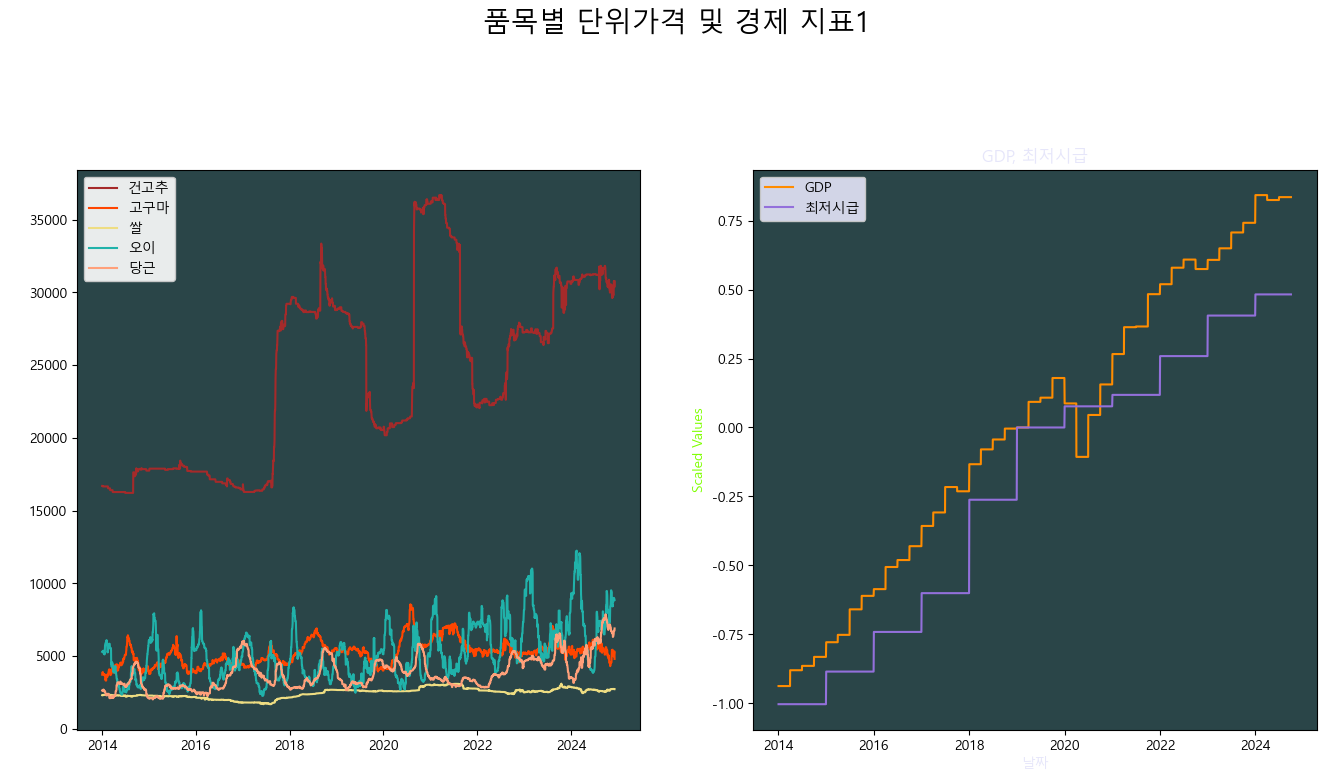

In [78]:
color_mapping = {
    '감자': '#b8860b',        # 감자의 금빛 갈색
    '건고추': '#a52a2a',      # 건고추의 깊은 적갈색
    '고구마': '#ff4500',      # 고구마의 선명한 주황색
    '깐마늘': '#fffacd',      # 마늘 속살의 연노란색
    '당근': '#ffa07a',        # 당근의 연한 주황색
    '대파': '#228b22',        # 대파의 짙은 녹색
    '무': '#f8f8ff',          # 무의 깨끗한 흰색
    '배추': '#98fb98',        # 배추의 옅은 연녹색
    '새송이버섯': '#a9a9a9',  # 새송이버섯의 중간 회색
    '시금치': '#006400',      # 시금치의 짙은 녹색
    '쌀': '#eedd82',          # 쌀의 밝은 금빛 베이지색
    '애호박': '#7fffd4',      # 애호박의 밝은 청록색
    '양배추': '#7cfc00',      # 양배추의 선명한 연두색
    '양파': '#ff6347',        # 양파의 붉은 황색
    '오이': '#20b2aa',        # 오이의 선명한 청록색
    '콩나물': '#fff68f',      # 콩나물의 부드러운 노란색
    '팽이': '#ffffff'         # 팽이버섯의 순백색
}

fig = plt.figure(figsize=(16, 16))

# 서브플롯 221
plt.subplot(221)
for 품목 in ['건고추', '고구마', '쌀', '오이', '당근']:
    x = df_eda[df_eda['품목명'] == 품목]['날짜']
    y = df_eda[df_eda['품목명'] == 품목]['단위가격']
    plt.plot(x, y, label=품목, color=color_mapping[품목])
plt.gca().set_facecolor('#2a4548')
plt.xlabel('날짜', color='white')  # 축 레이블 색상
plt.ylabel('단위가격', color='white')
plt.title('건고추, 고구마, 쌀, 오이, 당근', color='white')  # 제목 색상
plt.legend(facecolor='white', framealpha=0.9)  # 범례 배경 흰색

# 서브플롯 222
plt.subplot(222)
x_gdp = scaled_df['날짜']
y_gdp = scaled_df['GDP']
plt.plot(x_gdp, y_gdp, label='GDP', color='#ff8c00')  # 밝은 오렌지색
x_min_wage = scaled_df['날짜']
y_min_wage = scaled_df['최저시급']
plt.plot(x_min_wage, y_min_wage, label='최저시급', color='#9370db')  # 라벤더색
plt.gca().set_facecolor('#2a4548')
plt.xlabel('날짜', color='lavender')  # 축 레이블 색상
plt.ylabel('Scaled Values', color='#7fff00')  # 연두색
plt.title('GDP, 최저시급', color='lavender')  # 제목 색상
plt.legend(facecolor='lavender', framealpha=0.9)  # 범례 배경 연보라색

plt.suptitle('품목별 단위가격 및 경제 지표1', size=20)
plt.show()


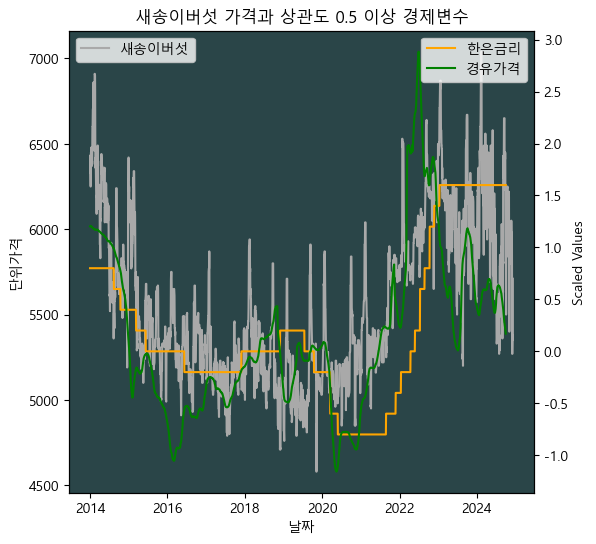

In [83]:
fig = plt.figure(figsize=(6, 6))

품목 = '새송이버섯'
x = df_eda[df_eda['품목명'] == 품목]['날짜']
y = df_eda[df_eda['품목명'] == 품목]['단위가격']
plt.plot(x, y, label=품목, color=color_mapping[품목])
plt.xlabel('날짜')
plt.ylabel('단위가격')
plt.gca().set_facecolor('#2a4548')
plt.legend(loc='upper left')

plt2 = plt.gca().twinx()
x_interest = scaled_df['날짜']
y_interest = scaled_df['한은금리']
plt2.plot(x_interest, y_interest, label='한은금리', color='orange')
x_diesel = scaled_df['날짜']
y_diesel = scaled_df['경유가격']
plt2.plot(x_diesel, y_diesel, label='경유가격', color='green')
plt2.set_ylabel('Scaled Values')
plt2.legend(loc='upper right')

plt.title('새송이버섯 가격과 상관도 0.5 이상 경제변수')

fig.savefig('새송이버섯 가격과 상관도 0.5 이상 경제변수.png', dpi=200)
plt.show()

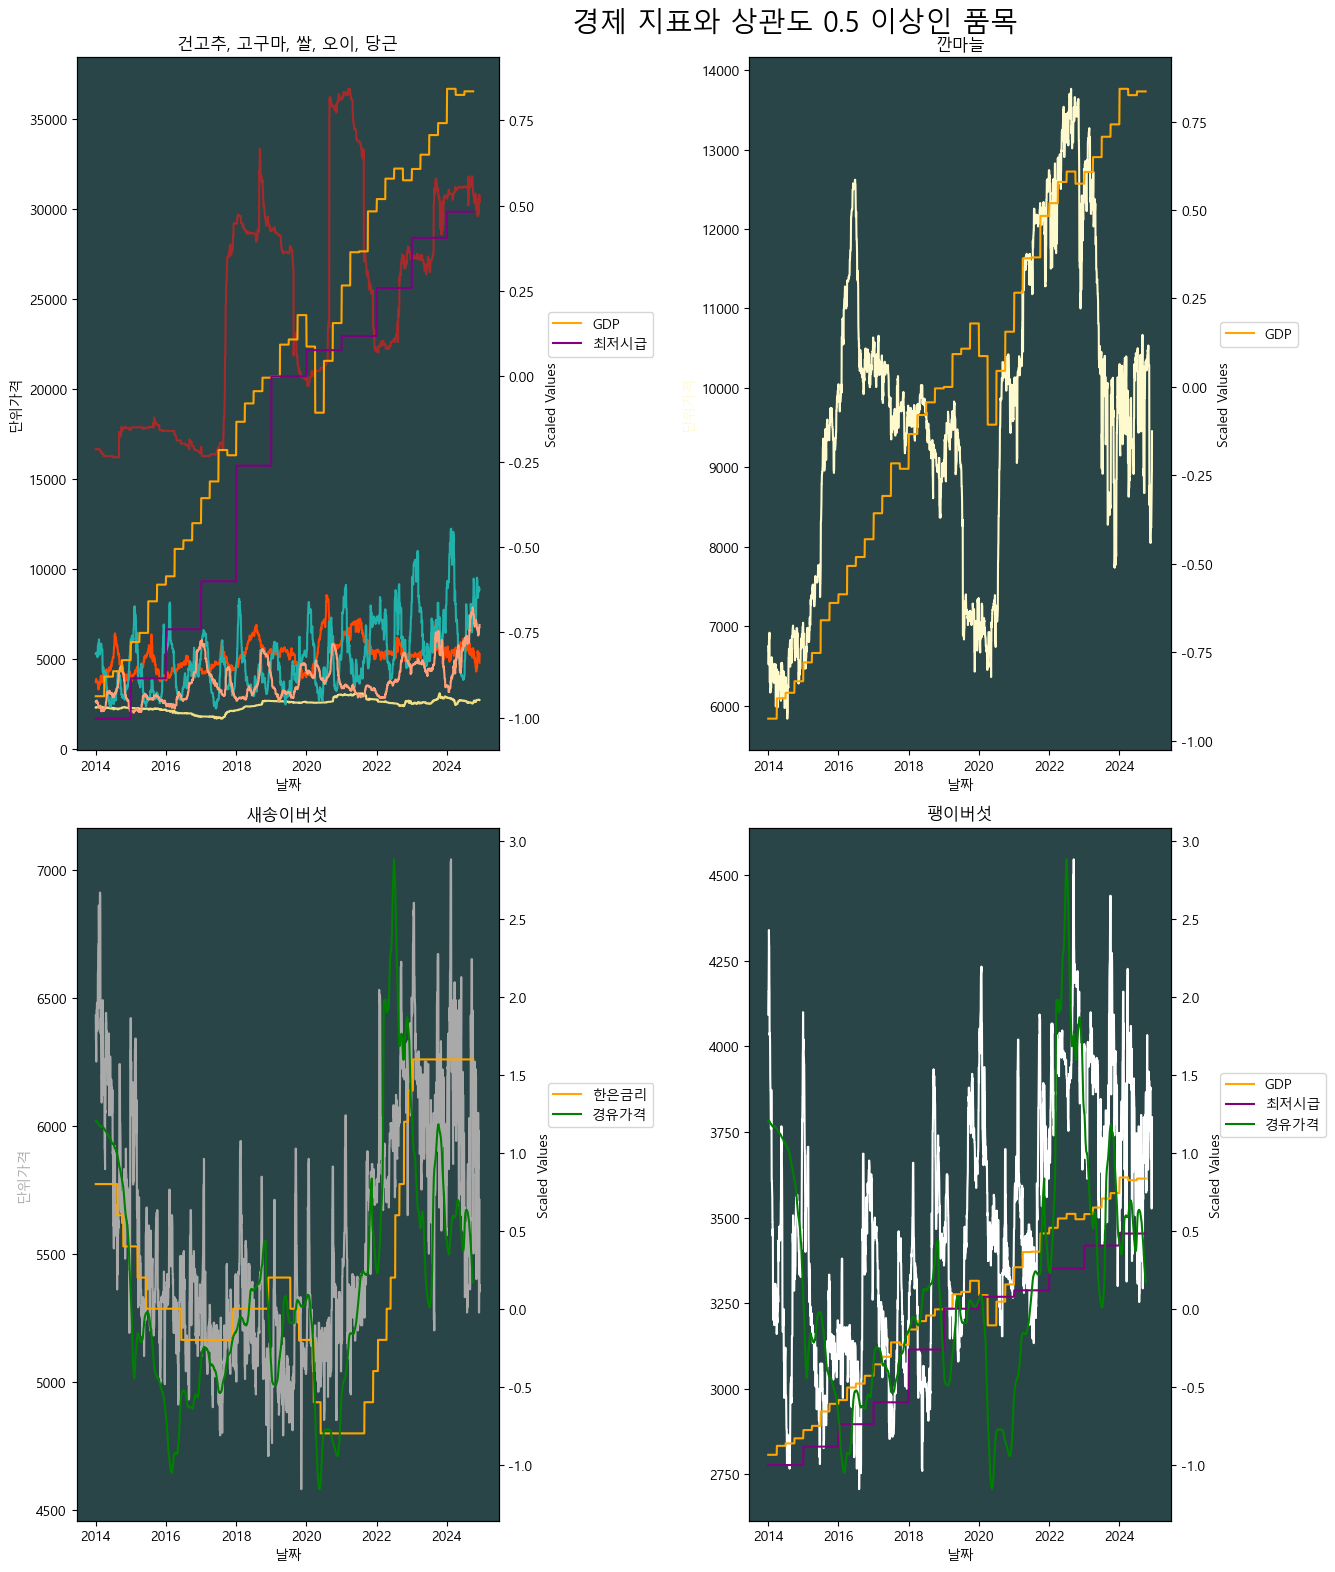

In [98]:
# 품목명_list = list(df_eda['품목명'].unique())
color_mapping = {
    '감자': '#b8860b',        # 감자의 금빛 갈색
    '건고추': '#a52a2a',      # 건고추의 깊은 적갈색
    '고구마': '#ff4500',      # 고구마의 선명한 주황색
    '깐마늘': '#fffacd',      # 마늘 속살의 연노란색
    '당근': '#ffa07a',        # 당근의 연한 주황색
    '대파': '#228b22',        # 대파의 짙은 녹색
    '무': '#f8f8ff',          # 무의 깨끗한 흰색
    '배추': '#98fb98',        # 배추의 옅은 연녹색
    '새송이버섯': '#a9a9a9',  # 새송이버섯의 중간 회색
    '시금치': '#006400',      # 시금치의 짙은 녹색
    '쌀': '#eedd82',          # 쌀의 밝은 금빛 베이지색
    '애호박': '#7fffd4',      # 애호박의 밝은 청록색
    '양배추': '#7cfc00',      # 양배추의 선명한 연두색
    '양파': '#ff6347',        # 양파의 붉은 황색
    '오이': '#20b2aa',        # 오이의 선명한 청록색
    '콩나물': '#fff68f',      # 콩나물의 부드러운 노란색
    '팽이': '#ffffff'         # 팽이버섯의 순백색
}
# bar_colors = [color_mapping.get(item) for item in 품목명_list]

fig = plt.figure(figsize=(16, 16))
    
# 서브플롯 221
plt.subplot(221)
for 품목 in ['건고추', '고구마', '쌀', '오이', '당근']:
    x = df_eda[df_eda['품목명'] == 품목]['날짜']
    y = df_eda[df_eda['품목명'] == 품목]['단위가격']
    plt.plot(x, y, label=품목, color=color_mapping[품목])
    plt.gca().set_facecolor('#2a4548')
plt.xlabel('날짜')
plt.ylabel('단위가격')
plt2 = plt.gca().twinx()
x_gdp = scaled_df['날짜']
y_gdp = scaled_df['GDP']
plt2.plot(x_gdp, y_gdp, label='GDP', color='orange')
x_min_wage = scaled_df['날짜']
y_min_wage = scaled_df['최저시급']
plt2.plot(x_min_wage, y_min_wage, label='최저시급', color='purple')
plt2.set_ylabel('Scaled Values')
plt.title('건고추, 고구마, 쌀, 오이, 당근')

# 범례 추가
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.8))
plt2.legend(loc='center left', bbox_to_anchor=(1.1, 0.6))

# 서브플롯 222
plt.subplot(222)
품목 = '깐마늘'
x = df_eda[df_eda['품목명'] == 품목]['날짜']
y = df_eda[df_eda['품목명'] == 품목]['단위가격']
plt.plot(x, y, label=품목, color=color_mapping[품목])
plt.gca().set_facecolor('#2a4548')
plt.xlabel('날짜')
plt.ylabel('단위가격', color=color_mapping[품목])
plt2 = plt.gca().twinx()
x_gdp = scaled_df['날짜']
y_gdp = scaled_df['GDP']
plt2.plot(x_gdp, y_gdp, label='GDP', color='orange')
plt2.set_ylabel('Scaled Values')
plt.title('깐마늘')

# 범례 추가
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.8))
plt2.legend(loc='center left', bbox_to_anchor=(1.1, 0.6))

# 서브플롯 223
plt.subplot(223)
품목 = '새송이버섯'
x = df_eda[df_eda['품목명'] == 품목]['날짜']
y = df_eda[df_eda['품목명'] == 품목]['단위가격']
plt.plot(x, y, label=품목, color=color_mapping[품목])
plt.gca().set_facecolor('#2a4548')
plt.xlabel('날짜')
plt.ylabel('단위가격', color=color_mapping[품목])
plt2 = plt.gca().twinx()
x_interest = scaled_df['날짜']
y_interest = scaled_df['한은금리']
plt2.plot(x_interest, y_interest, label='한은금리', color='orange')
x_diesel = scaled_df['날짜']
y_diesel = scaled_df['경유가격']
plt2.plot(x_diesel, y_diesel, label='경유가격', color='green')
plt2.set_ylabel('Scaled Values')
plt.title('새송이버섯')

# 범례 추가
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.8))
plt2.legend(loc='center left', bbox_to_anchor=(1.1, 0.6))

# 서브플롯 224 
plt.subplot(224)
품목 = '팽이'
x = df_eda[df_eda['품목명'] == 품목]['날짜']
y = df_eda[df_eda['품목명'] == 품목]['단위가격']
plt.plot(x, y, label=품목, color=color_mapping[품목])
plt.gca().set_facecolor('#2a4548')
plt.xlabel('날짜')
plt.ylabel('단위가격', color=color_mapping[품목])
plt2 = plt.gca().twinx()
x_gdp = scaled_df['날짜']
y_gdp = scaled_df['GDP']
plt2.plot(x_gdp, y_gdp, label='GDP', color='orange')
x_min_wage = scaled_df['날짜']
y_min_wage = scaled_df['최저시급']
plt2.plot(x_min_wage, y_min_wage, label='최저시급', color='purple')
x_diesel = scaled_df['날짜']
y_diesel = scaled_df['경유가격']
plt2.plot(x_diesel, y_diesel, label='경유가격', color='green')
plt2.set_ylabel('Scaled Values')
plt.title('팽이버섯')

# 범례 추가
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.8))
plt2.legend(loc='center left', bbox_to_anchor=(1.1, 0.6))

# 전체 제목 및 레이아웃 조정
fig.suptitle('경제 지표와 상관도 0.5 이상인 품목', size=20)
fig.tight_layout(rect=[0, 0, 0.85, 1])  # 그래프를 오른쪽 여유 공간 포함하도록 조정

plt.savefig('경제 지표와 상관도 0.5 이상인 품목.png', dpi=200)

plt.show()

# 상관도 보기

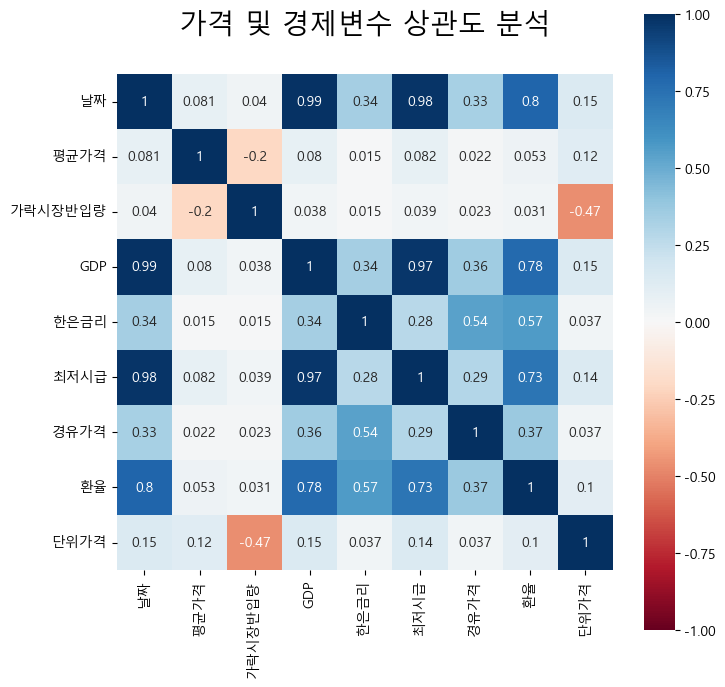

In [49]:
df_corr = df.drop(columns = ['품목명']).corr() # , '년월', '년', '월'
# 시본 히트맵 사각형 그리기
# 히트맵 그리기
plt.figure(figsize=(8, 8))
sns.heatmap(
    df_corr, 
    annot=True, 
    cmap='RdBu',  # -1은 파란색, 1은 빨간색
    vmin=-1,      # 컬러맵 최소값
    vmax=1,       # 컬러맵 최대값
    center=0,     # 0을 기준으로 색상 분리
    annot_kws={"size": 10},  # 주석 글자 크기
    square=True   # 정사각형 셀 유지
)
plt.title('가격 및 경제변수 상관도 분석', fontsize = 20, pad = 30)
# 그래프 저장 및 출력
plt.savefig('가격_경제변수_상관도_분석_전체.png', dpi=200)
plt.show()

# GDP ~ 최저시급, 환율
# 한은금리 ~ 경유가격, 환율

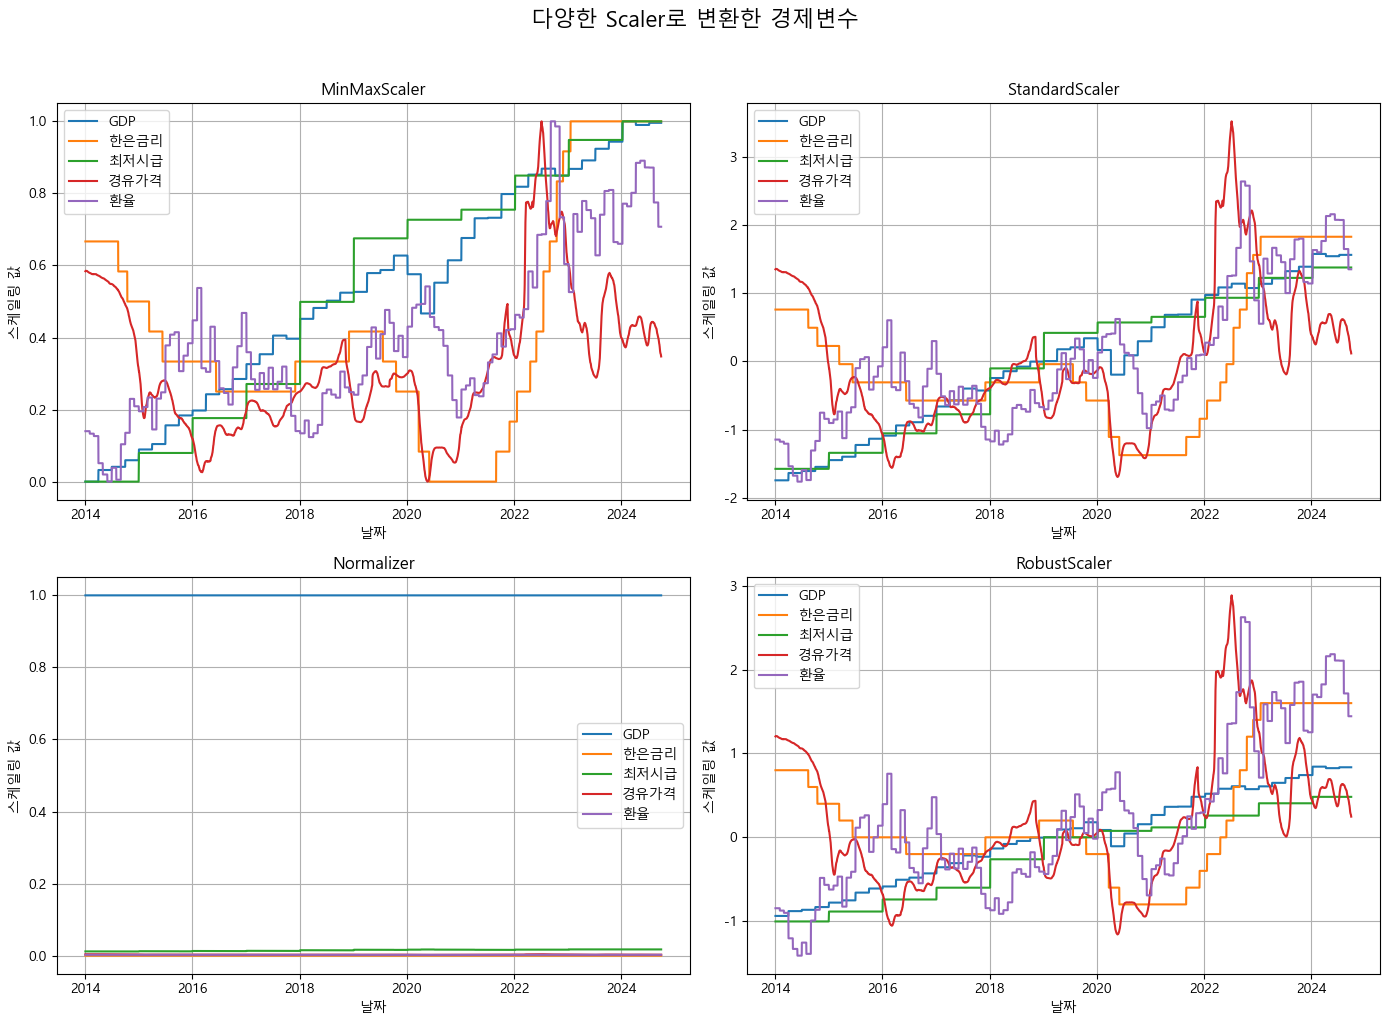

In [70]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import RobustScaler

# 날짜 제외한 수치 데이터
# numeric_data = df_경제변수.drop(columns=['날짜'])
numeric_data = df[['GDP', '한은금리', '최저시급', '경유가격', '환율']]

# 각 스케일러 객체
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'Normalizer': Normalizer(),
    'RobustScaler': RobustScaler(),
}

# 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 각 스케일러 적용 및 시각화
for i, (name, scaler) in enumerate(scalers.items()):
    scaled_data = scaler.fit_transform(numeric_data)
    scaled_df = pd.DataFrame(scaled_data, columns=numeric_data.columns)
    
    # 날짜 열과 병합
    scaled_df = pd.concat([df_경제변수['날짜'], scaled_df], axis=1)
    
    # 시각화
    for col in numeric_data.columns:
        axes[i].plot(scaled_df['날짜'], scaled_df[col], label=col)
    
    axes[i].set_title(name)
    axes[i].set_xlabel('날짜')
    axes[i].set_ylabel('스케일링 값')
    axes[i].legend(loc='best')
    axes[i].grid(True)

plt.suptitle('다양한 Scaler로 변환한 경제변수', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('Scaler로_변환한_경제변수.png', dpi=200)
plt.show()

# GDP ~ 최저시급, 환율
# 한은금리 ~ 경유가격

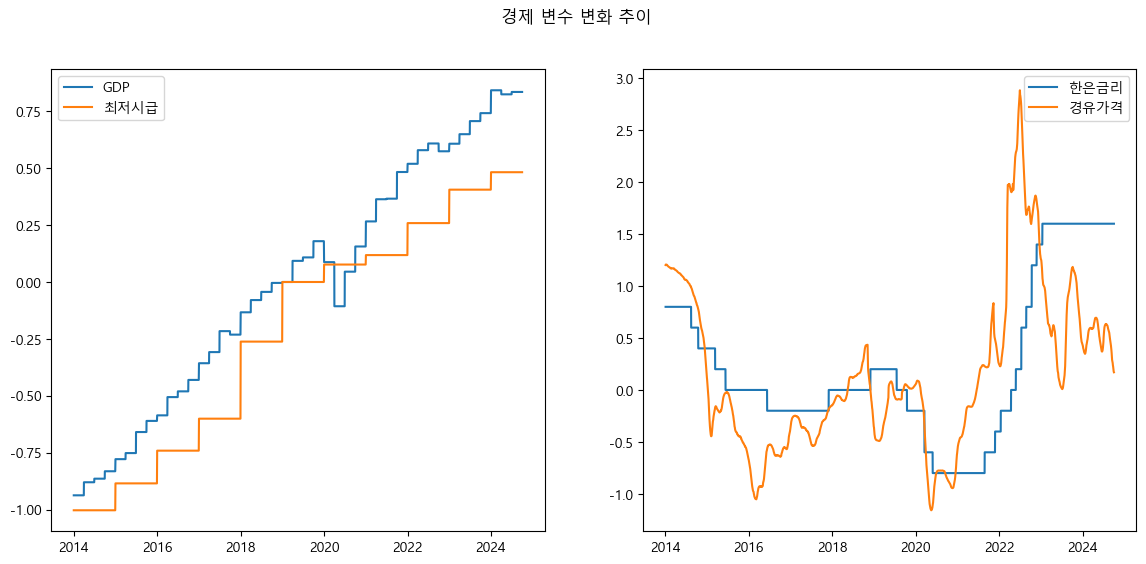

In [109]:
from sklearn.preprocessing import RobustScaler

# 날짜 제외한 수치 데이터
# numeric_data = df_경제변수.drop(columns=['날짜'])
numeric_data = df_경제변수[['GDP', '한은금리', '최저시급', '경유가격', '환율']]

scaler = RobustScaler()

scaled_data = scaler.fit_transform(numeric_data)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_data.columns)
# scaled_df
# 날짜 열과 병합
scaled_df = pd.concat([df_경제변수['날짜'], scaled_df], axis=1)
# scaled_df

# 연도별
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# ax[0]
x00 = scaled_df['날짜']
y00 = scaled_df['GDP']
ax[0].plot(x00, y00, label='GDP')

x001 = scaled_df['날짜']
y001 = scaled_df['최저시급']
ax[0].plot(x001, y001, label='최저시급')

# ax[0].set_ylim(0)
ax[0].legend()

# ax[1]
x01 = scaled_df['날짜']
y01 = scaled_df['한은금리']
ax[1].plot(x01, y01, label='한은금리')

x011 = scaled_df['날짜']
y011 = scaled_df['경유가격']
ax[1].plot(x011, y011, label='경유가격')

# ax[1].set_ylim(0)
ax[1].legend()
ax[1].set_title(' ')

# 전체 제목
fig.suptitle('경제 변수 변화 추이')

fig.savefig('경제_변수_변화_추이_scaler_robust.png', dpi=200)
plt.show()

품목명            감자      건고추     고구마      깐마늘      당근      대파       무      배추  \
날짜                                                                            
2014-01-02  202.0  10018.0  3717.0   6746.0  2625.0  2077.0  1358.0  2515.0   
2014-01-03  208.0  10018.0  3816.0   6693.0  2606.0  2079.0  1358.0  2515.0   
2014-01-04  208.0  10018.0  3816.0   6693.0  2606.0  2079.0  1358.0  2515.0   
2014-01-05  208.0  10018.0  3816.0   6693.0  2606.0  2079.0  1358.0  2515.0   
2014-01-06  281.0  10018.0  3895.0   6518.0  2663.0  2078.0  1445.0  2530.0   
...           ...      ...     ...      ...     ...     ...     ...     ...   
2024-09-26  306.0  18626.0  5586.0  10329.0  7844.0  3620.0  1694.0  9680.0   
2024-09-27  305.0  18579.0  5576.0  10329.0  7822.0  3722.0  1704.0  9963.0   
2024-09-28  305.0  18579.0  5576.0  10329.0  7822.0  3722.0  1704.0  9963.0   
2024-09-29  305.0  18579.0  5576.0  10329.0  7822.0  3722.0  1704.0  9963.0   
2024-09-30  305.0  18579.0  5599.0  10329.0  7642.0 

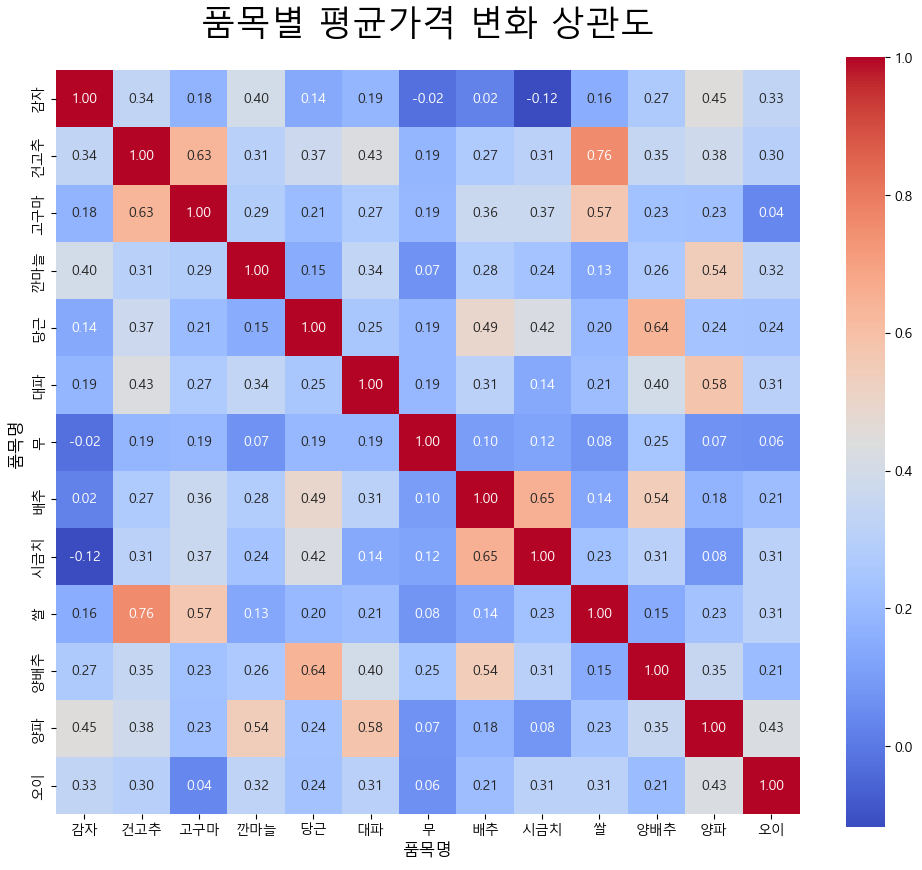

In [50]:
# '날짜'를 인덱스로 설정
df_pivot = df.pivot_table(index='날짜', columns='품목명', values='평균가격')

# 결측값 처리 (선형 보간)
df_pivot = df_pivot.interpolate(method='linear', limit_direction='forward')

print(df_pivot)

# 품목별 상관계수 계산
corr_matrix = df_pivot.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)

# 그래프 설정
plt.title('품목별 평균가격 변화 상관도', fontsize=25, pad=25)
plt.xlabel('품목명', fontsize=12)
plt.ylabel('품목명', fontsize=12)

# 저장 및 출력
plt.savefig('품목별_평균가격_상관도.png', dpi=200)
plt.show()

# 감자 ~ 양파
# 건고추 ~ 고구마, 쌀
# 깐마늘 ~ 양파
# 당근 ~ 배추, 양배추
# 대파 ~ 양파
# 배추 ~ 시금치, 양배추
# 양파 ~ 깐마늘, 대파

In [73]:
df.sample(5)

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격
32870,2017-06-25,시금치,422.0,64.5,488738.1,1.25,6470.0,1240.04,1144.1,4220.0
28169,2015-06-05,배추,3411.0,524.0,456256.6,1.75,5580.0,1367.48,1115.5,3411.0
19436,2023-12-17,당근,3460.0,113.5,565597.6,3.50,9620.0,1515.14,1288.0,3460.0
16511,2015-12-14,당근,2601.0,141.0,466604.0,1.50,5580.0,1216.02,1172.5,2601.0
1860,2019-02-05,감자,453.0,96.0,511286.6,1.75,8350.0,1242.71,1124.7,4530.0


In [56]:
df[df['품목명']=='당근']

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격
15916,2014-01-02,당근,2625.0,299.96384,442669.9,2.5,5210.0,1706.27,1050.0,2625.0
15917,2014-01-03,당근,2606.0,300.00000,442669.9,2.5,5210.0,1707.15,1055.0,2606.0
15918,2014-01-04,당근,2606.0,192.00000,442669.9,2.5,5210.0,1707.61,1059.0,2606.0
15919,2014-01-05,당근,2606.0,205.50000,442669.9,2.5,5210.0,1707.56,1062.0,2606.0
15920,2014-01-06,당근,2663.0,219.00000,442669.9,2.5,5210.0,1707.80,1065.0,2663.0
...,...,...,...,...,...,...,...,...,...,...
19836,2024-09-26,당근,7844.0,129.00000,572413.3,3.5,9860.0,1429.96,1327.0,7844.0
19837,2024-09-27,당근,7822.0,171.00000,572413.3,3.5,9860.0,1427.87,1319.0,7822.0
19838,2024-09-28,당근,7822.0,107.00000,572413.3,3.5,9860.0,1425.01,1315.0,7822.0
19839,2024-09-29,당근,7822.0,153.00000,572413.3,3.5,9860.0,1423.72,1311.0,7822.0


In [108]:
df[df['품목명']=='당근']['날짜']

15800   2014-01-02
15801   2014-01-03
15802   2014-01-04
15803   2014-01-05
15804   2014-01-06
           ...    
19720   2024-09-26
19721   2024-09-27
19722   2024-09-28
19723   2024-09-29
19724   2024-09-30
Name: 날짜, Length: 3925, dtype: datetime64[ns]

In [111]:
df[df['품목명']=='당근']['단위가격']

15800    2625.0
15801    2606.0
15802    2606.0
15803    2606.0
15804    2663.0
          ...  
19720    7844.0
19721    7822.0
19722    7822.0
19723    7822.0
19724    7642.0
Name: 단위가격, Length: 3925, dtype: float64

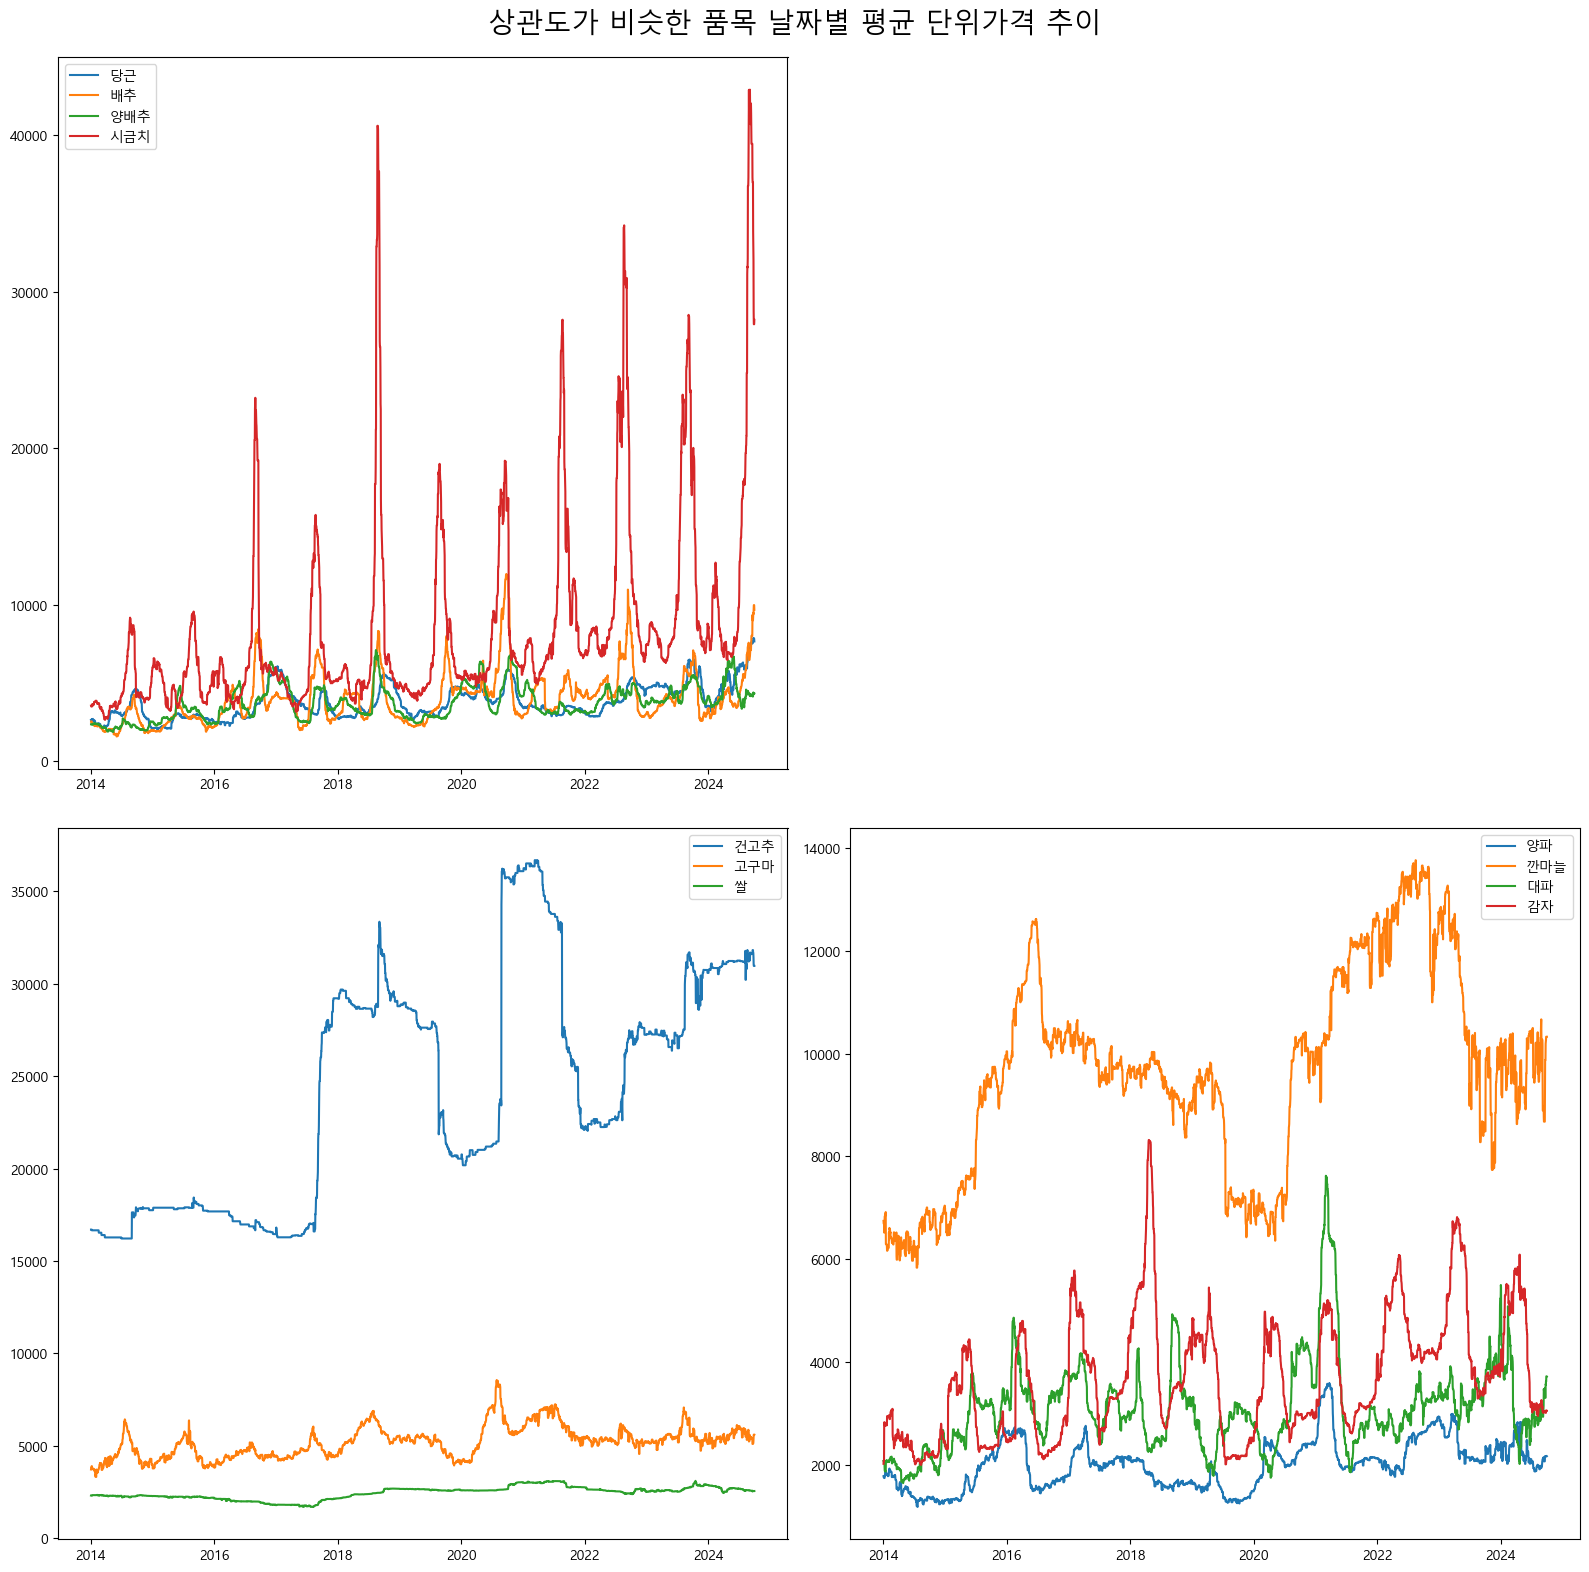

In [112]:
# 그래프 그릴 때 사용할 컬럼 생성
df['년월'] = df['날짜'].dt.strftime('%Y-%m')
df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month

# 상관도가 비슷한 품목 날짜별 단위가격 추이
fig = plt.figure( figsize=(16, 16))

plt.subplot(221)
x221 = df[df['품목명']=='당근']['날짜']
y221 = df[df['품목명']=='당근']['단위가격']
plt.plot(x221, y221, label='당근')
x2212 = df[df['품목명']=='배추']['날짜']
y2212 = df[df['품목명']=='배추']['단위가격']
plt.plot(x2212, y2212, label='배추')
x2213 = df[df['품목명']=='양배추']['날짜']
y2213 = df[df['품목명']=='양배추']['단위가격']
plt.plot(x2213, y2213, label='양배추')
x2214 = df[df['품목명']=='시금치']['날짜']
y2214 = df[df['품목명']=='시금치']['단위가격']
plt.plot(x2214, y2214, label='시금치')
plt.legend()
plt.title(' ')

plt.subplot(223)
x223 = df[df['품목명']=='건고추']['날짜']
y223 = df[df['품목명']=='건고추']['단위가격']
plt.plot(x223, y223, label='건고추')
x2232 = df[df['품목명']=='고구마']['날짜']
y2232 = df[df['품목명']=='고구마']['단위가격']
plt.plot(x2232, y2232, label='고구마')
x2233 = df[df['품목명']=='쌀']['날짜']
y2233 = df[df['품목명']=='쌀']['단위가격']
plt.plot(x2233, y2233, label='쌀')
plt.legend()
plt.title(' ')

plt.subplot(224)
x224 = df[df['품목명']=='양파']['날짜']
y224 = df[df['품목명']=='양파']['단위가격']
plt.plot(x224, y224, label='양파')
x2242 = df[df['품목명']=='깐마늘']['날짜']
y2242 = df[df['품목명']=='깐마늘']['단위가격']
plt.plot(x2242, y2242, label='깐마늘')
x2243 = df[df['품목명']=='대파']['날짜']
y2243 = df[df['품목명']=='대파']['단위가격']
plt.plot(x2243, y2243, label='대파')
x2244 = df[df['품목명']=='감자']['날짜']
y2244 = df[df['품목명']=='감자']['단위가격']
plt.plot(x2244, y2244, label='감자')
plt.legend()
plt.title(' ')

fig.suptitle('상관도가 비슷한 품목 날짜별 평균 단위가격 추이', size=20)
fig.tight_layout()

plt.show()

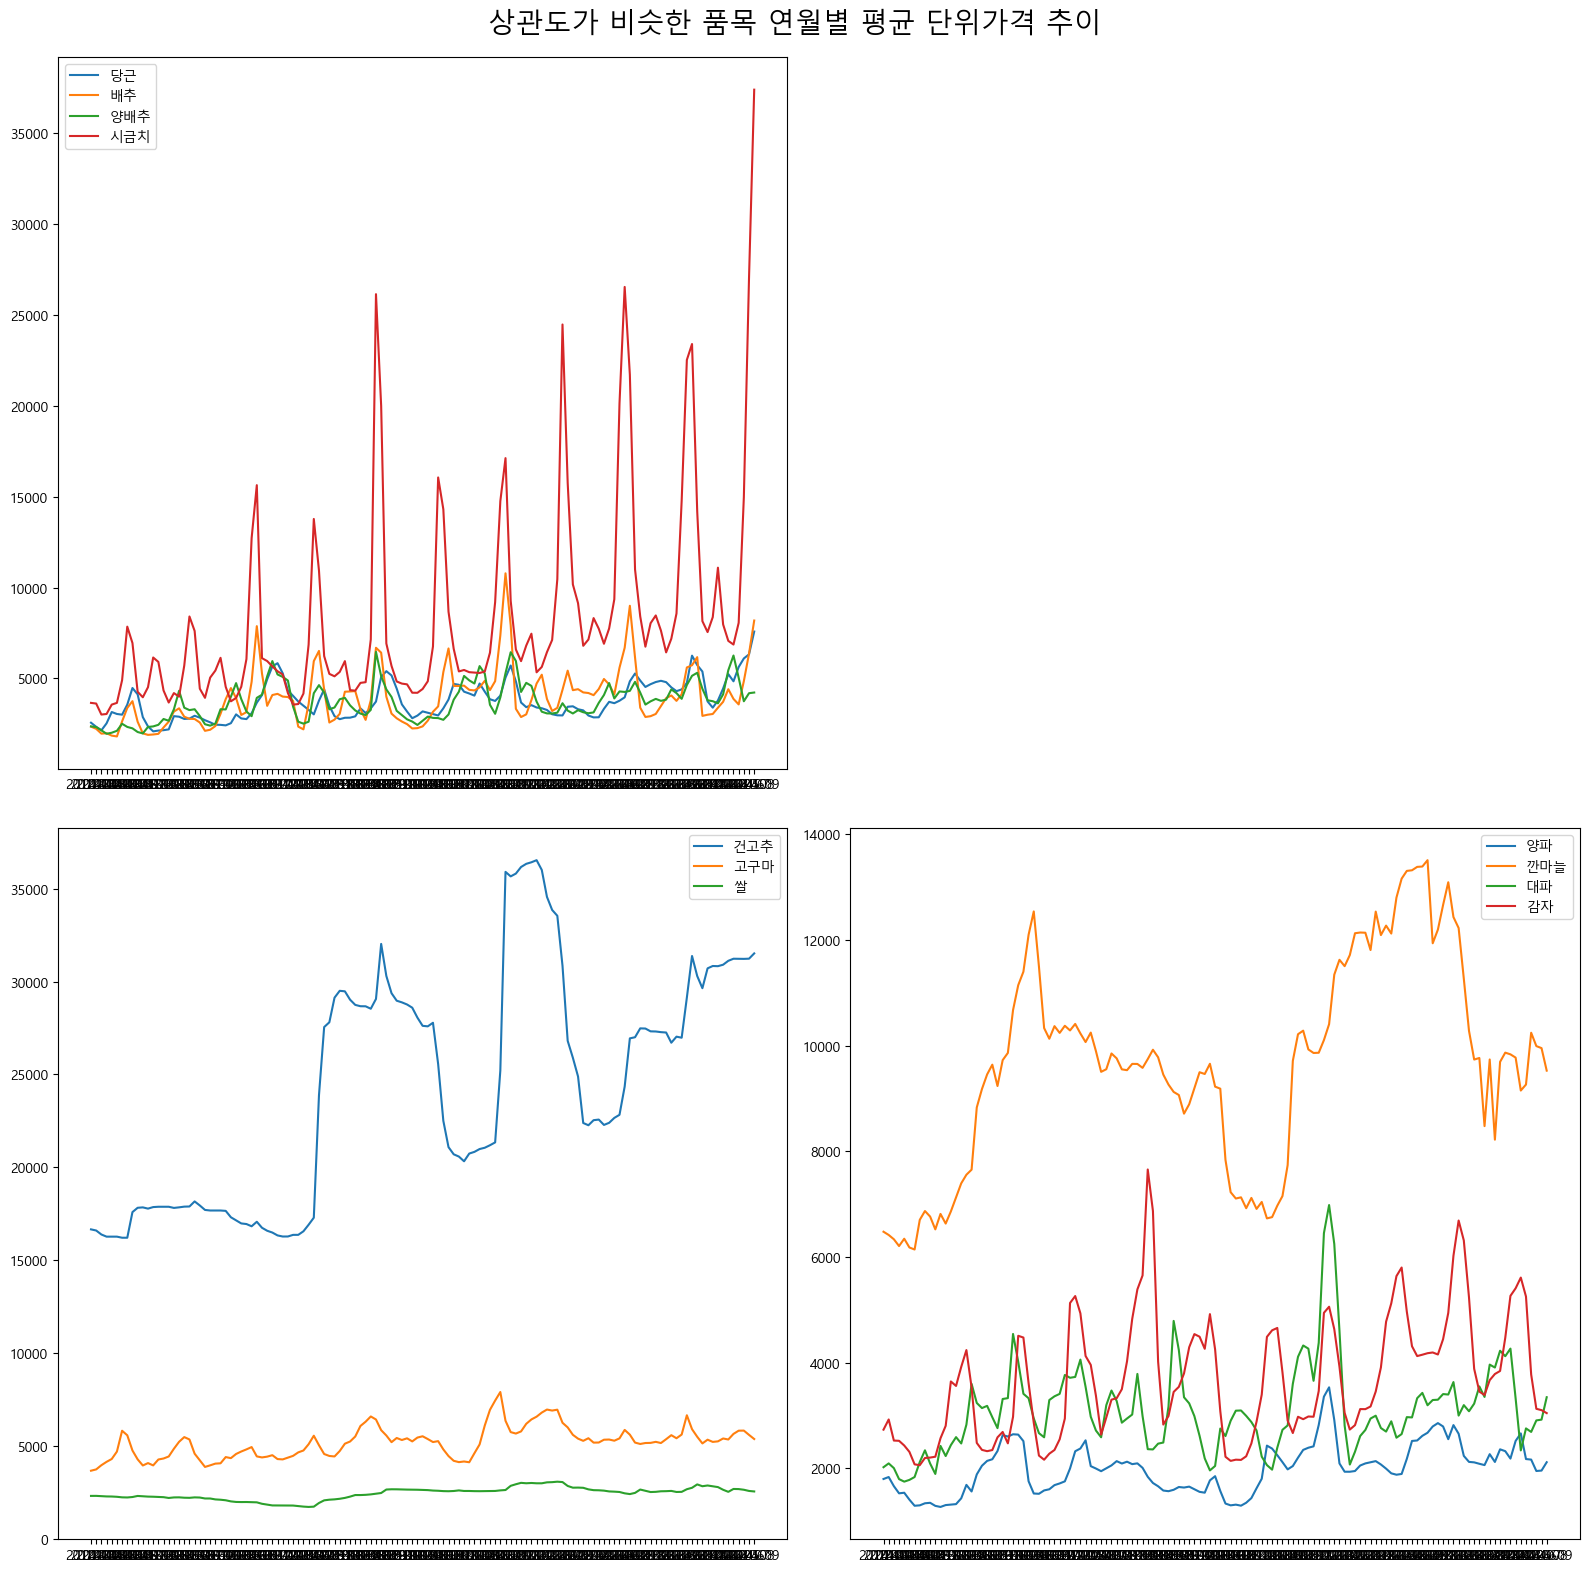

In [140]:
# 그래프 그릴 때 사용할 컬럼 생성
df['년월'] = df['날짜'].dt.strftime('%Y-%m')
df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month

# 상관도가 비슷한 품목 년월별 평균 단위가격 추이
fig = plt.figure( figsize=(16, 16))

plt.subplot(221)
x221 = df[df['품목명']=='당근'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y221 = df[df['품목명']=='당근'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x221, y221, label='당근')
x2212 = df[df['품목명']=='배추'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y2212 = df[df['품목명']=='배추'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2212, y2212, label='배추')
x2213 = df[df['품목명']=='양배추'].groupby('년월').agg(연도별_평균=('단위가격', 'mean')).index
y2213 = df[df['품목명']=='양배추'].groupby('년월').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
plt.plot(x2213, y2213, label='양배추')
x2214 = df[df['품목명']=='시금치'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y2214 = df[df['품목명']=='시금치'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2214, y2214, label='시금치')
plt.legend()
plt.title(' ')

plt.subplot(223)
x223 = df[df['품목명']=='건고추'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y223 = df[df['품목명']=='건고추'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x223, y223, label='건고추')
x2232 = df[df['품목명']=='고구마'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y2232 = df[df['품목명']=='고구마'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2232, y2232, label='고구마')
x2233 = df[df['품목명']=='쌀'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y2233 = df[df['품목명']=='쌀'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2233, y2233, label='쌀')
plt.legend()
plt.title(' ')

plt.subplot(224)
x224 = df[df['품목명']=='양파'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y224 = df[df['품목명']=='양파'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x224, y224, label='양파')
x2242 = df[df['품목명']=='깐마늘'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y2242 = df[df['품목명']=='깐마늘'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2242, y2242, label='깐마늘')
x2243 = df[df['품목명']=='대파'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y2243 = df[df['품목명']=='대파'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2243, y2243, label='대파')
x2244 = df[df['품목명']=='감자'].groupby('년월').agg(평균=('단위가격', 'mean')).index
y2244 = df[df['품목명']=='감자'].groupby('년월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2244, y2244, label='감자')
plt.legend()
plt.title(' ')

fig.suptitle('상관도가 비슷한 품목 연월별 평균 단위가격 추이', size=20)
fig.tight_layout()

plt.show()

In [125]:
monthly_min = df[df['품목명']=='당근'].groupby('월').agg(평균=('단위가격', 'mean')).min()
monthly_max = df[df['품목명']=='당근'].groupby('월').agg(평균=('단위가격', 'mean')).max()
all_mean = df[df['품목명']=='당근']['단위가격'].mean()
price_diff_rate = (monthly_max - monthly_min) / all_mean
print(price_diff_rate)

평균    0.341081
dtype: float64


In [142]:
def get_price_diff_rate(df, period, items):
    """
    df 데이터프레임을 period(년 or 월)별 평균 냈을 때 item(품목)별로 가격 편차를 구하기
    Parameters:
    - df : DataFrame
    - period : 그룹화할 기간 (예: '년', '월', '분기' 등)
    - items : 품목명 리스트

    Returns:
    - dict : {item : price_diff_rate}
    """
    result_dict = {}
    for item in items:
        # 품목별 데이터 필터링
        filtered_df = df[df['품목명'] == item]
        
        # 기간별 평균 단위가격 계산
        grouped = filtered_df.groupby(period).agg(평균=('단위가격', 'mean'))
        
        # 최소, 최대, 전체 평균 계산
        monthly_min = grouped['평균'].min()
        monthly_max = grouped['평균'].max()
        all_mean = filtered_df['단위가격'].mean()
        
        # 가격 편차율 계산
        price_diff_rate = (monthly_max - monthly_min) / all_mean if all_mean != 0 else 0
        
        # 결과 저장
        result_dict[item] = price_diff_rate
    
    return result_dict

In [143]:
get_price_diff_rate(df, '월', list(df['품목명'].unique()))

{'감자': 0.5907924533269255,
 '건고추': 0.08980684385023288,
 '고구마': 0.23042268998737744,
 '깐마늘': 0.05507309358678548,
 '당근': 0.3410808254515839,
 '대파': 0.25984245914026993,
 '무': 0.2737637843788198,
 '배추': 0.8597466288494685,
 '시금치': 1.5928005020911382,
 '쌀': 0.03190101791900642,
 '양배추': 0.20910764162366405,
 '양파': 0.21305829983575994,
 '오이': 0.8133681166105826}

In [199]:
def get_price_diff_rate(df, period, items):
    """
    df 데이터프레임을 period(년 or 월)별 평균 냈을 때 item(품목)별로 가격 편차를 구하기
    Parameters:
    - df : DataFrame
    - period : 그룹화할 기간 (예: '년', '월', '분기' 등)
    - items : 품목명 리스트

    Returns:
    - dict : {item : price_diff_rate}
    """
    result_dict = {}
    for item in items:
        # 품목별 데이터 필터링
        filtered_df = df[df['품목명'] == item]
        
        # 기간별 평균 단위가격 계산
        grouped = filtered_df.groupby(period).agg(평균=('단위가격', 'mean'))
        
        # 최소, 최대, 전체 평균 계산
        monthly_min = grouped['평균'].min()
        monthly_max = grouped['평균'].max()
        all_mean = filtered_df['단위가격'].mean()
        
        # 가격 편차율 계산
        price_diff_rate = (monthly_max - monthly_min) / all_mean if all_mean != 0 else 0
        
        # 결과 저장
        result_dict[item] = price_diff_rate
    
    return result_dict


df_price_diff_rate_hori = pd.DataFrame(
    get_price_diff_rate(df, '월', list(df['품목명'].unique())),
    index = ['품목명', '가격편차'])
df_price_diff_rate = df_price_diff_rate_hori.transpose().reset_index()
df_price_diff_rate.drop(columns = ['가격편차'], inplace = True)
df_price_diff_rate.columns=['품목명', '가격편차']
df_price_diff_rate_top5 = df_price_diff_rate.sort_values('가격편차', ascending = False).head(5)
df_price_diff_rate_tail5 = df_price_diff_rate.sort_values('가격편차', ascending = True).head(5)
print(df_price_diff_rate_top5)
print(df_price_diff_rate_tail5)

    품목명      가격편차
8   시금치  1.592801
7    배추  0.859747
12   오이  0.813368
0    감자  0.590792
4    당근  0.341081
    품목명      가격편차
9     쌀  0.031901
3   깐마늘  0.055073
1   건고추  0.089807
10  양배추  0.209108
11   양파  0.213058


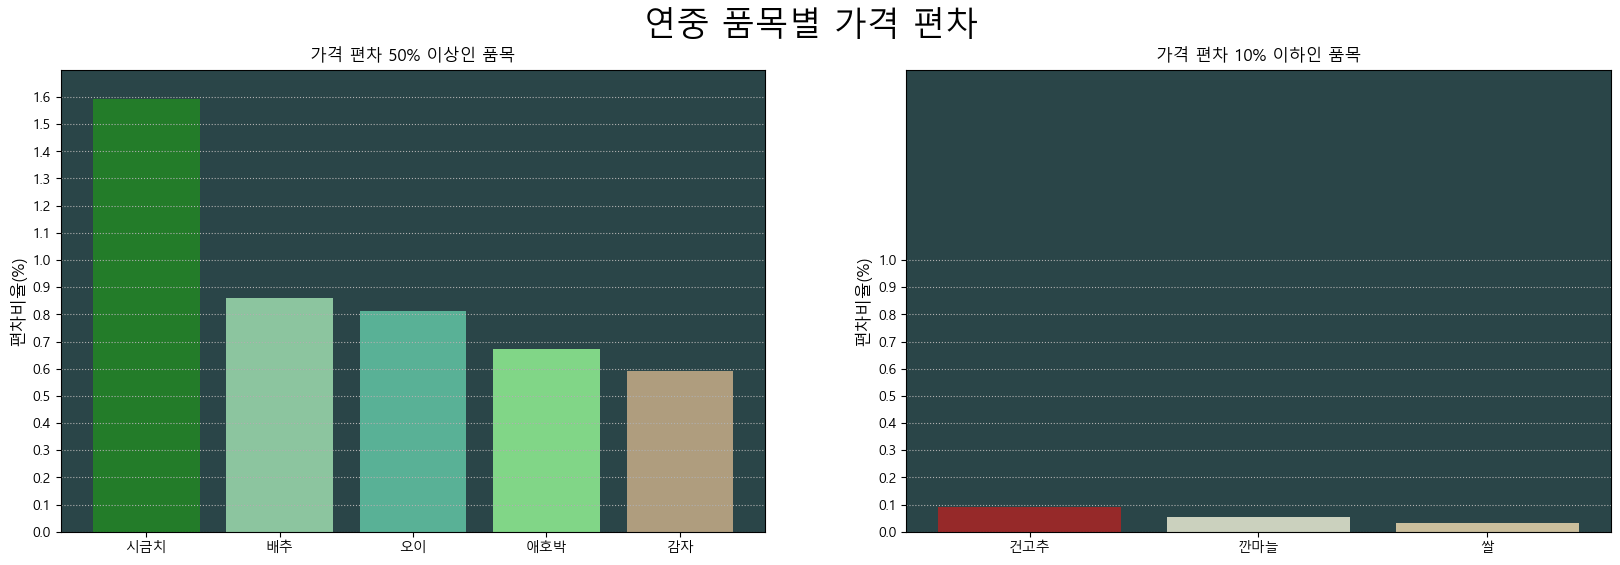

In [62]:
# 품목명과 색상을 매핑하는 딕셔너리 생성
# 품목명_list = list(df['품목명'].unique())
color_mapping = {
    '감자': '#d2b48c',        # 감자의 갈색 껍질
    '건고추': '#b22222',      # 건고추의 진한 붉은색
    '고구마': '#ff8c00',      # 고구마의 주황색
    '깐마늘': '#f5f5dc',      # 마늘 속살의 밝은 베이지색
    '당근': '#ffa500',        # 당근의 밝은 주황색
    '대파': '#32cd32',        # 대파의 신선한 녹색
    '무': '#ffffff',          # 무의 깨끗한 흰색
    '배추': '#a5e6b6',        # 배추의 연녹색
    '새송이버섯': '#dcdcdc',  # 새송이버섯의 밝은 회색
    '시금치': '#228b22',      # 시금치의 짙은 녹색
    '쌀': '#f5deb3',          # 쌀의 밝은 베이지색
    '애호박': '#98fb98',      # 애호박의 연녹색
    '양배추': '#7cfc00',      # 양배추의 선명한 초록색
    '양파': '#f4a460',        # 양파의 황갈색 껍질
    '오이': '#66cdaa',        # 오이의 신선한 초록색
    '콩나물': '#ffff99',      # 콩나물의 연한 노란색
    '팽이': '#f5f5f5'         # 팽이버섯의 밝은 흰색
}
# bar_colors = [color_mapping.get(item) for item in 품목명_list]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x0 = df_price_diff_rate.loc[df_price_diff_rate['가격편차'] >= 0.5].sort_values('가격편차', ascending=False)['품목명']
y0 = df_price_diff_rate.loc[df_price_diff_rate['가격편차'] >= 0.5].sort_values('가격편차', ascending=False)['가격편차']
x0_colors = [color_mapping[item] for item in x0]  # x0에 해당하는 품목명별 색상 생성
ax[0].bar(x0, y0, color=x0_colors, alpha=0.8)

ax[0].set_facecolor('#2a4548')
ax[0].set_ylim(0, 1.7)
ax[0].set_yticks(np.arange(0, 1.7, step=0.1))
ax[0].grid(axis='y', ls=':')
ax[0].set_ylabel('편차비율(%)', fontsize=12)
ax[0].set_title('가격 편차 50% 이상인 품목')


# ax[1]
x01 = df_price_diff_rate.loc[df_price_diff_rate['가격편차'] <= 0.1].sort_values('가격편차', ascending=False)['품목명']
y01 = df_price_diff_rate.loc[df_price_diff_rate['가격편차'] <= 0.1].sort_values('가격편차', ascending=False)['가격편차']
x01_colors = [color_mapping[item] for item in x01]  # x01에 해당하는 품목명별 색상 생성
ax[1].bar(x01, y01, color=x01_colors, alpha=0.8)

ax[1].set_facecolor('#2a4548')
ax[1].set_ylim(0, 1.7)
ax[1].set_yticks(np.arange(0, 1.1, step=0.1))
ax[1].grid(axis='y', ls=':')
ax[1].set_ylabel('편차비율(%)', fontsize=12)
ax[1].set_title('가격 편차 10% 이하인 품목')

# 제목 및 저장
fig.suptitle('연중 품목별 가격 편차', fontsize=24)
# fig.savefig('연중 품목별 가격 편차.png', dpi=200)
plt.show()

In [200]:
df_price_diff_rate_top5.loc[df_price_diff_rate_top5['가격편차'] >= 0.5]

,품목명,가격편차
8,시금치,1.592801
7,배추,0.859747
12,오이,0.813368
0,감자,0.590792


In [201]:
list(df_price_diff_rate_top5.loc[df_price_diff_rate_top5['가격편차'] >= 0.5]['품목명'])

['시금치', '배추', '오이', '감자']

In [241]:
list(df_price_diff_rate.loc[df_price_diff_rate.sort_values('가격편차', ascending = True)['가격편차'] <= 0.1]['품목명'])

['건고추', '깐마늘', '쌀']

In [230]:
list(df_price_diff_rate_tail5['품목명'])

['쌀', '깐마늘', '건고추', '양배추', '양파']

In [202]:
legend_labels = [f"{row['품목명']} ({row['가격편차']:.2f})" for row in df_price_diff_rate_top5]
legend_labels

TypeError: string indices must be integers, not 'str'

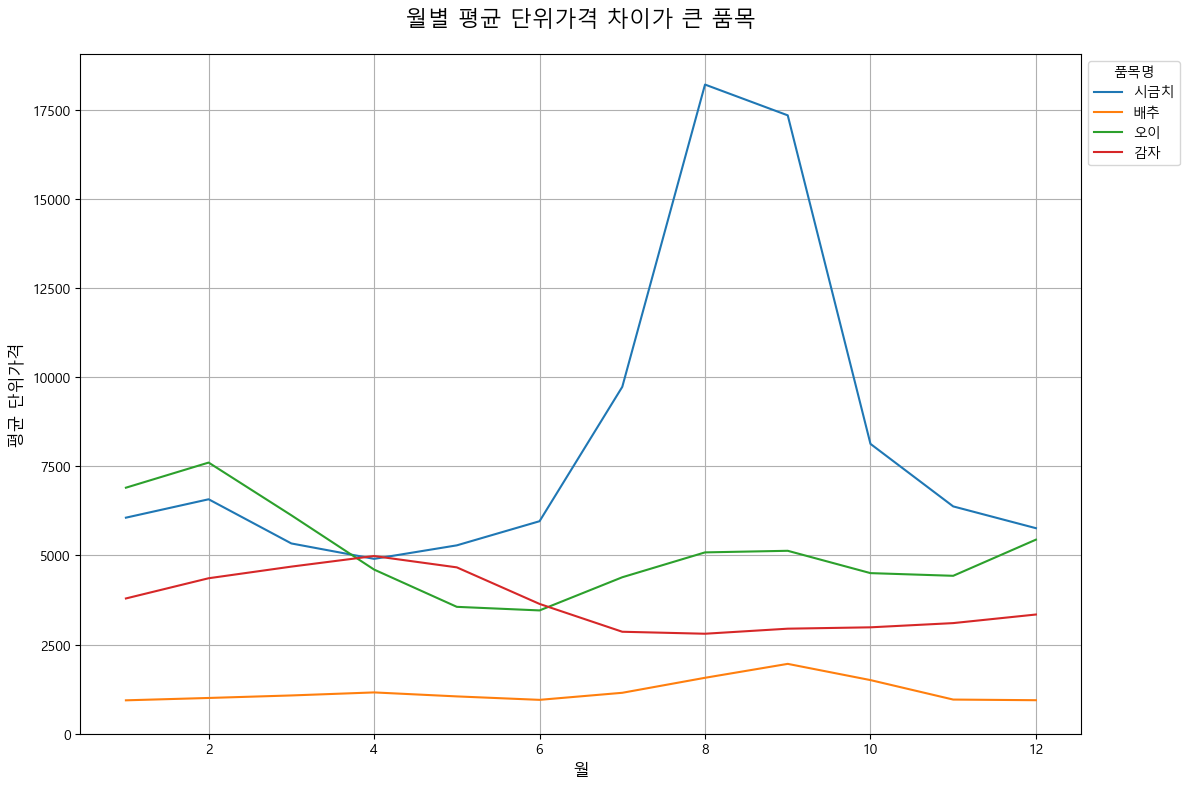

In [203]:
# 품목명 리스트
변동큰품목 = list(df_price_diff_rate_top5.loc[df_price_diff_rate_top5['가격편차'] >= 0.5]['품목명']) # ['시금치', '배추', '오이', '감자']

# 그래프 그리기
plt.figure(figsize=(12, 8))

for item in 변동큰품목:
    x = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
    plt.plot(x, y, label=item)

plt.ylim(0)  # y축 최소값 설정
plt.xlabel('월', fontsize=12)
plt.ylabel('평균 단위가격', fontsize=12)
plt.title('월별 평균 단위가격 차이가 큰 품목', fontsize=16, pad=20)

plt.legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left')


plt.grid(True)
plt.tight_layout()
# plt.savefig('월별_평균_단위가격_차이가_큰_품목.png', dpi=200)
plt.show()

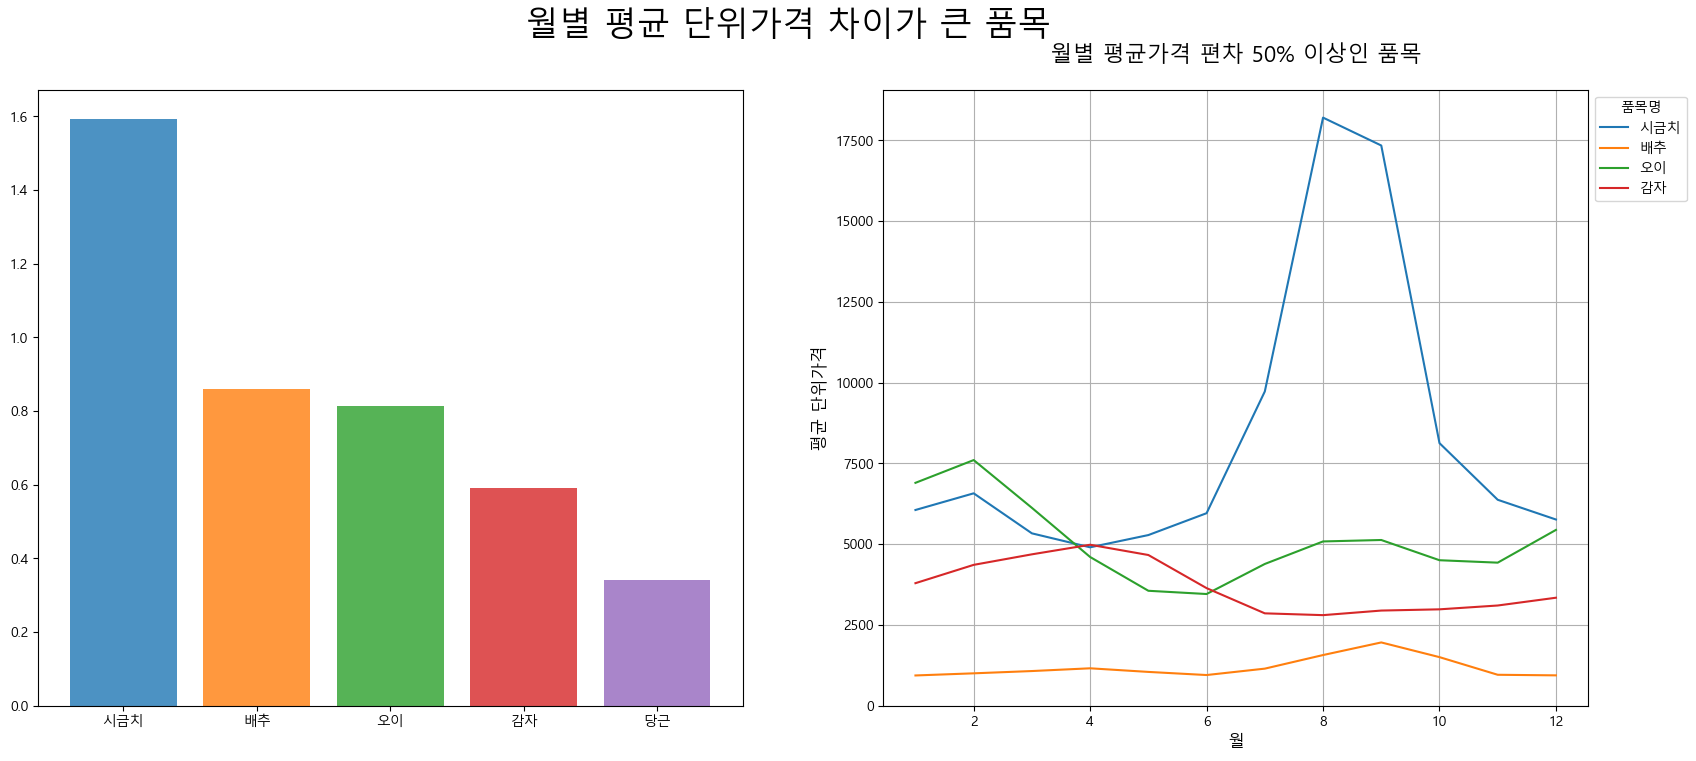

In [249]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
# ax[0]
x0 = df_price_diff_rate_top5['품목명']
y0 = df_price_diff_rate_top5['가격편차']
ax[0].bar(x0, y0, color=default_colors, alpha=0.8)

# ax[1]
# 품목명 리스트
변동큰품목 = list(df_price_diff_rate_top5.loc[df_price_diff_rate_top5['가격편차'] >= 0.5]['품목명']) # ['시금치', '배추', '오이', '감자']

for item in 변동큰품목:
    # 월별 평균 계산
    x = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
    
    # 데이터 플롯
    ax[1].plot(x, y, label=item)

# ax[1] 그래프 설정
ax[1].set_ylim(0)  # y축 최소값 설정
ax[1].set_xlabel('월', fontsize=12)
ax[1].set_ylabel('평균 단위가격', fontsize=12)
ax[1].set_title('월별 평균가격 편차 50% 이상인 품목', fontsize=16, pad=20)
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left')
ax[1].grid(True)

fig.suptitle('월별 평균 단위가격 차이가 큰 품목', fontsize=24)
# fig.savefig('월별 평균가격 편차 큰 품목.png', dpi=200)
# plt.tight_layout()
plt.show()

In [251]:
df_price_diff_rate_hori = pd.DataFrame(
    get_price_diff_rate(df, '월', list(df['품목명'].unique())),
    index = ['품목명', '가격편차'])
df_price_diff_rate = df_price_diff_rate_hori.transpose().reset_index()
df_price_diff_rate.drop(columns = ['가격편차'], inplace = True)
df_price_diff_rate.columns=['품목명', '가격편차']
df_price_diff_rate_top5 = df_price_diff_rate.sort_values('가격편차', ascending = False).head(5)
df_price_diff_rate_tail5 = df_price_diff_rate.sort_values('가격편차', ascending = True).head(5)
print(df_price_diff_rate_top5)
print(df_price_diff_rate_tail5.sort_values('가격편차', ascending = False))

    품목명      가격편차
8   시금치  1.592801
7    배추  0.859747
12   오이  0.813368
0    감자  0.590792
4    당근  0.341081
    품목명      가격편차
11   양파  0.213058
10  양배추  0.209108
1   건고추  0.089807
3   깐마늘  0.055073
9     쌀  0.031901


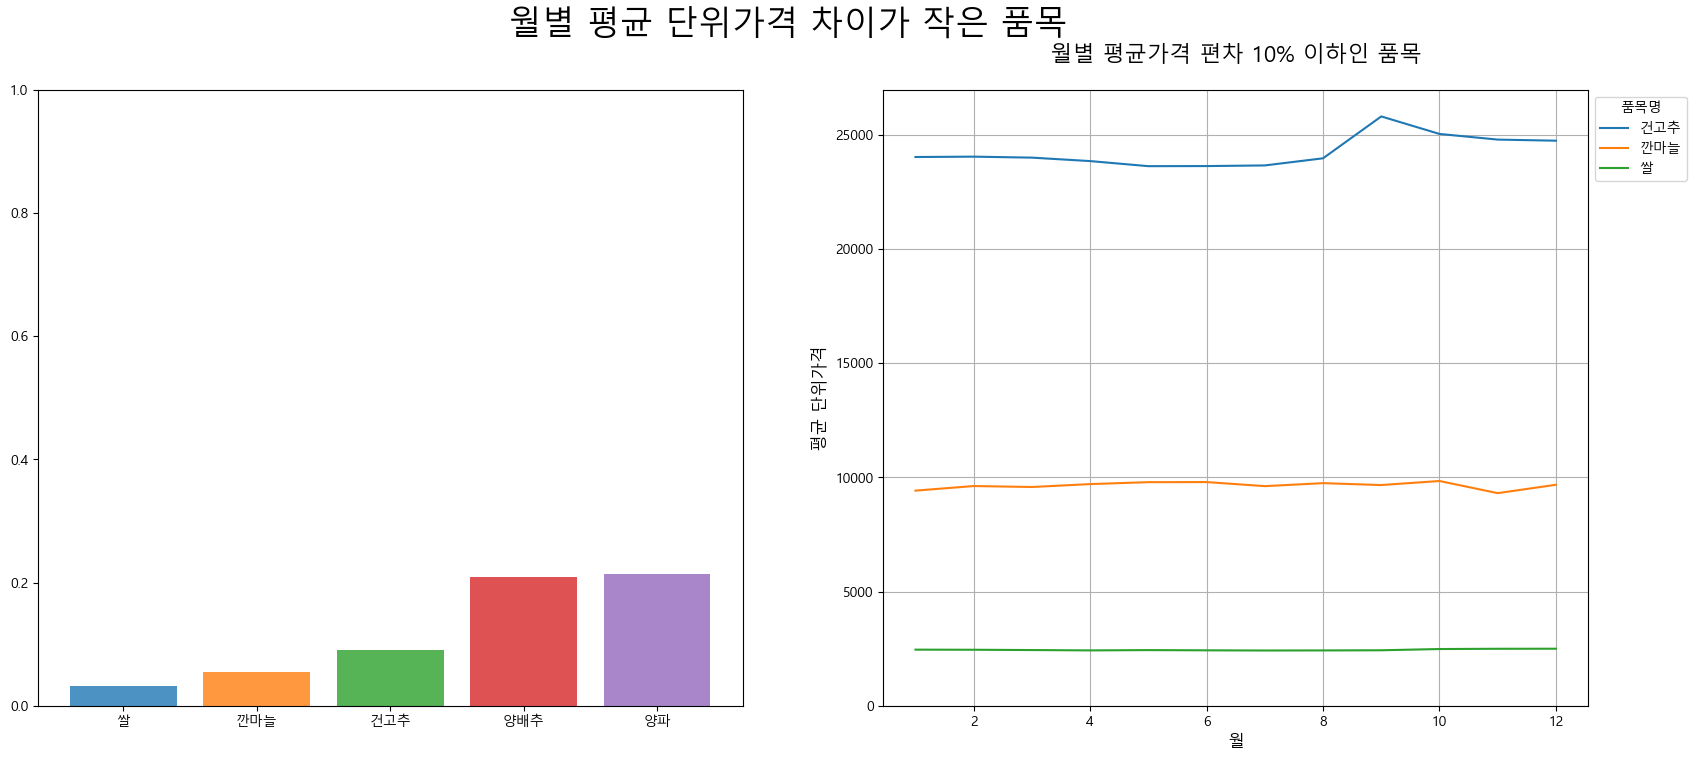

In [253]:
df_price_diff_rate_hori = pd.DataFrame(
    get_price_diff_rate(df, '월', list(df['품목명'].unique())),
    index = ['품목명', '가격편차'])
df_price_diff_rate = df_price_diff_rate_hori.transpose().reset_index()
df_price_diff_rate.drop(columns = ['가격편차'], inplace = True)
df_price_diff_rate.columns=['품목명', '가격편차']
df_price_diff_rate_top5 = df_price_diff_rate.sort_values('가격편차', ascending = False).head(5)
df_price_diff_rate_tail5 = df_price_diff_rate.sort_values('가격편차', ascending = True).head(5)
print(df_price_diff_rate_top5)
print(df_price_diff_rate_tail5.sort_values('가격편차', ascending = False))

# default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
# ax[0]
x0 = df_price_diff_rate_tail5['품목명']
y0 = df_price_diff_rate_tail5['가격편차']
ax[0].bar(x0, y0, color=default_colors, alpha=0.8)
ax[0].set_ylim(0, 1)

# ax[1]
# 품목명 리스트
변동큰품목 = list(df_price_diff_rate.loc[df_price_diff_rate.sort_values('가격편차', ascending = True)['가격편차'] <= 0.1]['품목명']) # ['건고추', '깐마늘', '쌀']

for item in 변동큰품목:
    # 월별 평균 계산
    x = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
    
    # 데이터 플롯
    ax[1].plot(x, y, label=item)

# ax[1] 그래프 설정
ax[1].set_ylim(0)  # y축 최소값 설정
ax[1].set_xlabel('월', fontsize=12)
ax[1].set_ylabel('평균 단위가격', fontsize=12)
ax[1].set_title('월별 평균가격 편차 10% 이하인 품목', fontsize=16, pad=20)
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left')
ax[1].grid(True)

fig.suptitle('월별 평균 단위가격 차이가 작은 품목', fontsize=24)
fig.savefig('월별 평균가격 편차 작은 품목.png', dpi=200)
# plt.tight_layout()
plt.show()

In [268]:
list(df['품목명'].unique())

['감자',
 '건고추',
 '고구마',
 '깐마늘',
 '당근',
 '대파',
 '무',
 '배추',
 '시금치',
 '쌀',
 '양배추',
 '양파',
 '오이']

In [269]:
color_mapping = {
    '감자': 'peru',         # 감자의 갈색 껍질
    '건고추': 'red',        # 건고추의 강렬한 붉은색
    '고구마': 'orange',     # 고구마의 주황색
    '깐마늘': 'ivory',      # 마늘 속살의 흰색
    '당근': 'darkorange',   # 당근의 진한 주황색
    '대파': 'green',        # 대파의 초록색
    '무': 'white',          # 무의 흰색
    '배추': 'lightgreen',   # 배추의 연녹색
    '시금치': 'forestgreen',# 시금치의 짙은 녹색
    '쌀': 'beige',          # 쌀의 베이지색
    '양배추': 'limegreen',  # 양배추의 밝은 초록색
    '양파': 'gold',         # 양파의 노란색
    '오이': 'mediumseagreen'# 오이의 짙은 녹색
}

In [58]:
# 그래프 그릴 때 사용할 컬럼 생성
df['년월'] = df['날짜'].dt.strftime('%Y-%m')
df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month


def get_price_diff_rate(df, period, items):
    """
    df 데이터프레임을 period(년 or 월)별 평균 냈을 때 item(품목)별로 가격 편차를 구하기
    Parameters:
    - df : DataFrame
    - period : 그룹화할 기간 (예: '년', '월', '분기' 등)
    - items : 품목명 리스트

    Returns:
    - dict : {item : price_diff_rate}
    """
    result_dict = {}
    for item in items:
        # 품목별 데이터 필터링
        filtered_df = df[df['품목명'] == item]
        
        # 기간별 평균 단위가격 계산
        grouped = filtered_df.groupby(period).agg(평균=('단위가격', 'mean'))
        
        # 최소, 최대, 전체 평균 계산
        monthly_min = grouped['평균'].min()
        monthly_max = grouped['평균'].max()
        all_mean = filtered_df['단위가격'].mean()
        
        # 가격 편차율 계산
        price_diff_rate = (monthly_max - monthly_min) / all_mean if all_mean != 0 else 0
        
        # 결과 저장
        result_dict[item] = price_diff_rate
    
    return result_dict


df_price_diff_rate_hori = pd.DataFrame(
    get_price_diff_rate(df, '월', list(df['품목명'].unique())),
    index = ['품목명', '가격편차'])
df_price_diff_rate = df_price_diff_rate_hori.transpose().reset_index()
df_price_diff_rate.drop(columns = ['가격편차'], inplace = True)
df_price_diff_rate.columns=['품목명', '가격편차']
df_price_diff_rate_top5 = df_price_diff_rate.sort_values('가격편차', ascending = False).head(5)
df_price_diff_rate_tail5 = df_price_diff_rate.sort_values('가격편차', ascending = True).head(5)
print(df_price_diff_rate_top5)
print(df_price_diff_rate_tail5)

# 품목명과 색상을 매핑하는 딕셔너리 생성
# 모든 가능한 품목명을 포함하도록 조정
품목명_list = pd.concat([df['품목명'], df_price_diff_rate_tail5['품목명'], pd.Series(변동큰품목)]).unique()
color_mapping = {
    '감자': 'peru',         # 감자의 갈색 껍질
    '건고추': 'red',        # 건고추의 강렬한 붉은색
    '고구마': 'orange',     # 고구마의 주황색
    '깐마늘': 'ivory',      # 마늘 속살의 흰색
    '당근': 'darkorange',   # 당근의 진한 주황색
    '대파': 'green',        # 대파의 초록색
    '무': 'white',          # 무의 흰색
    '배추': 'lightgreen',   # 배추의 연녹색
    '시금치': 'forestgreen',# 시금치의 짙은 녹색
    '쌀': 'beige',          # 쌀의 베이지색
    '양배추': 'limegreen',  # 양배추의 밝은 초록색
    '양파': 'gold',         # 양파의 노란색
    '오이': 'mediumseagreen'# 오이의 짙은 녹색
}

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
# ax[0]
ax[0].set_facecolor('#2a4548')
x0 = df_price_diff_rate_tail5['품목명']
y0 = df_price_diff_rate_tail5['가격편차']
bar_colors = [color_mapping.get(item, default_color) for item in x0]  # 기본 색상으로 처리
ax[0].bar(x0, y0, color=bar_colors, alpha=0.8)
ax[0].set_ylabel('편차비율(%)', fontsize=12)
ax[0].set_yticks(np.arange(0, 1, step=0.1))
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', ls=':')
ax[0].set_title('가격편차가 작은 품목 TOP5', fontsize=16)

# ax[1]
ax[1].set_facecolor('#2a4548')
for item in 변동큰품목:
    # 월별 평균 계산
    x = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
    # 데이터 플롯
    ax[1].plot(x, y, label=item, color=color_mapping.get(item, default_color))
# ax[1] 그래프 설정
ax[1].set_ylim(0)  # y축 최소값 설정
ax[1].set_xlabel('월', fontsize=12)
ax[1].set_ylabel('평균 단위가격', fontsize=12)
ax[1].set_title('월별 평균가격 편차 10% 이하인 품목', fontsize=16, pad=20)
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left', facecolor='#5c979d')
ax[1].grid(axis='y', ls=':')
# 공통 제목 설정
fig.suptitle('월별 평균 단위가격 차이가 작은 품목', fontsize=24)
# 그래프 저장 및 표시
fig.savefig('월별 평균가격 편차 작은 품목.png', dpi=200)
plt.show()

    품목명      가격편차
8   시금치  1.592801
7    배추  0.859747
13   오이  0.813368
10  애호박  0.673513
0    감자  0.590792
    품목명      가격편차
9     쌀  0.031901
3   깐마늘  0.055073
1   건고추  0.089807
11  양배추  0.209108
12   양파  0.213058


NameError: name '변동큰품목' is not defined

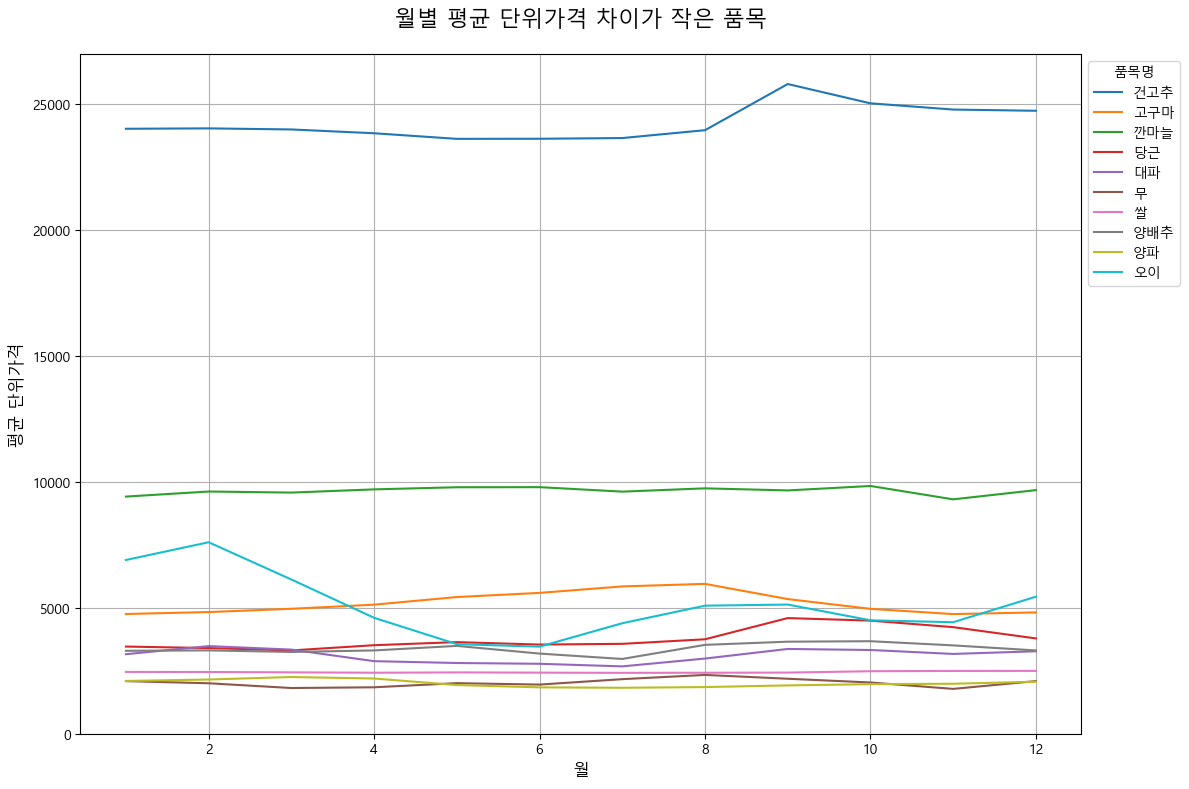

In [54]:
# 품목명 리스트
all_items = list(df['품목명'].unique())
변동큰품목

items = [item for item in all_items if item not in 변동큰품목]

# 그래프 그리기
plt.figure(figsize=(12, 8))

for item in items:
    x = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
    plt.plot(x, y, label=item)

plt.ylim(0)  # y축 최소값 설정
plt.xlabel('월', fontsize=12)
plt.ylabel('평균 단위가격', fontsize=12)
plt.title('월별 평균 단위가격 차이가 작은 품목', fontsize=16, pad=20)
plt.legend(title='품목명', bbox_to_anchor=(1, 1), loc='upper left')  # 범례 위치 조정
plt.grid(True)
plt.tight_layout()
plt.savefig('월별_평균_단위가격_차이가_작은_품목.png', dpi=200)
plt.show()

In [63]:
# '월' 열 추가
df['월'] = pd.to_datetime(df['날짜']).dt.month
# '품목명'별로 '단위가격' 평균값이 최저인 월 구하기
monthly_minprice_df = (
    df.groupby(['품목명', '월'])['단위가격']
    .mean()
    .reset_index()
    .sort_values(['품목명', '단위가격'])
    .drop_duplicates('품목명', keep='first')
)
monthly_minprice_df.sort_values('월')

,품목명,월,단위가격
84,배추,1,936.708824
50,당근,3,3307.821114
99,시금치,4,4903.181818
16,건고추,5,23623.275660
124,애호박,5,1133.844575
161,오이,6,3457.572727
66,대파,7,2674.431085
114,쌀,7,2417.724340
138,양배추,7,2968.826979
150,양파,7,1824.436950


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# 계절 분류 함수
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

# 계절별로 품목 분류
monthly_minprice_df['계절'] = monthly_minprice_df['월'].apply(get_season)
seasons = monthly_minprice_df.groupby('계절')['품목명'].apply(list).to_dict()

# 그래프 생성
fig = plt.figure(figsize=(16, 16))

# 계절별 그래프 위치 설정
subplot_positions = {
    '봄': 221,
    '여름': 222,
    '가을': 223,
    '겨울': 224
}

# 각 계절별 품목의 월별 평균 단위가격 추이 플롯
for season, pos in subplot_positions.items():
    plt.subplot(pos)
    if season in seasons:
        for item in seasons[season]:
            x = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean')).index
            y = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
            plt.plot(x, y, label=item)
        plt.legend()
        plt.title(f'{season}에 저렴한 품목')

# 전체 그래프 제목 및 레이아웃 설정
fig.suptitle('품목별 평균가격이 최저가인 계절', size=20)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# 그래프 저장 및 출력
plt.savefig('품목별 평균가격이 최저가인 계절.png', dpi=200)
plt.show()


NameError: name 'monthly_minprice_df' is not defined

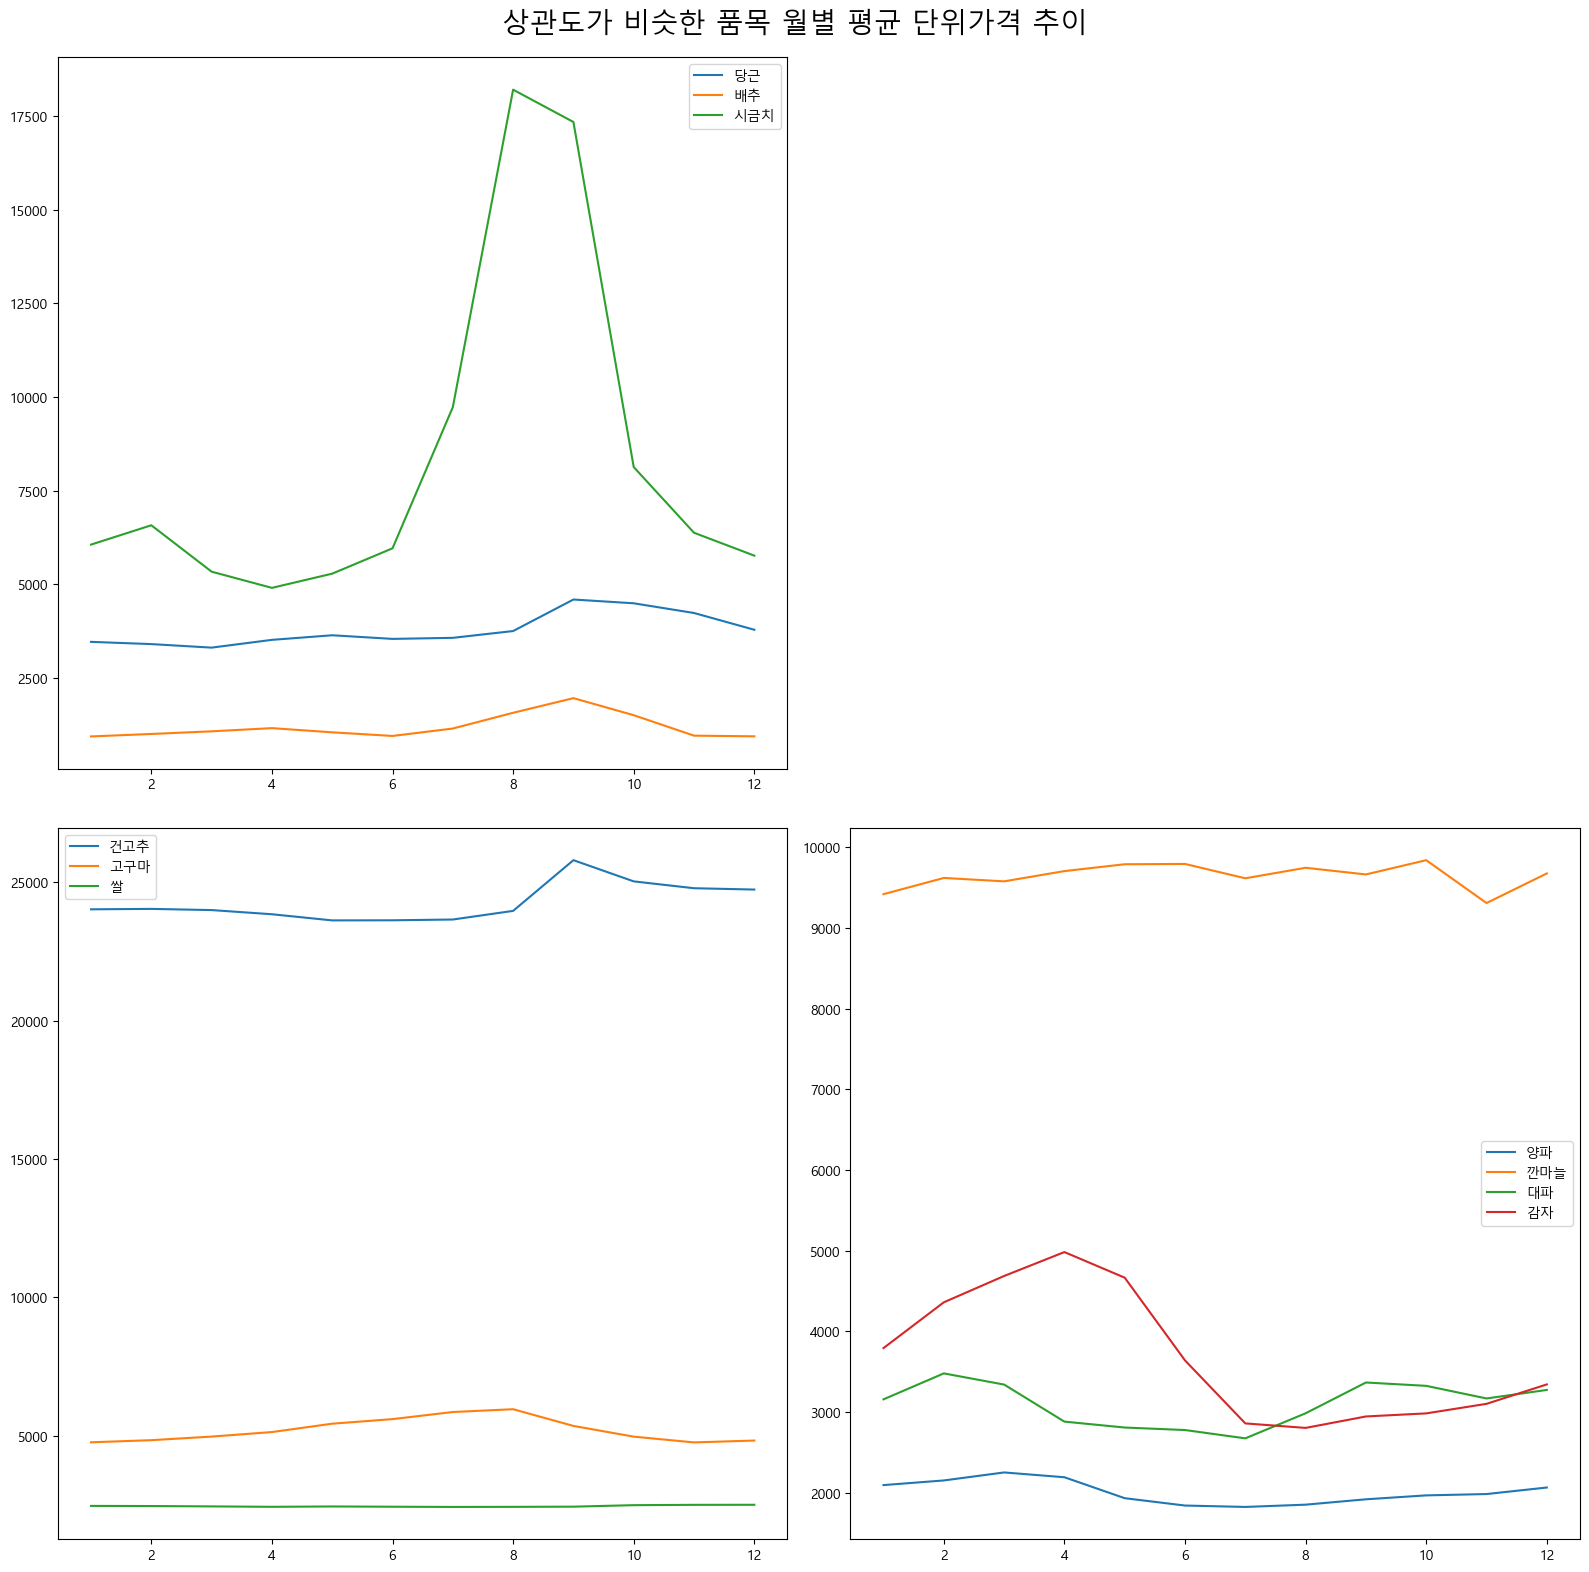

In [150]:
# 그래프 그릴 때 사용할 컬럼 생성
df['년월'] = df['날짜'].dt.strftime('%Y-%m')
df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month

# 상관도가 비슷한 품목 월별 평균 단위가격 추이
fig = plt.figure( figsize=(16, 16))

plt.subplot(221)
x221 = df[df['품목명']=='당근'].groupby('월').agg(평균=('단위가격', 'mean')).index
y221 = df[df['품목명']=='당근'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x221, y221, label='당근')
x2212 = df[df['품목명']=='배추'].groupby('월').agg(평균=('단위가격', 'mean')).index
y2212 = df[df['품목명']=='배추'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2212, y2212, label='배추')
# x2213 = df[df['품목명']=='양배추'].groupby('월').agg(연도별_평균=('단위가격', 'mean')).index
# y2213 = df[df['품목명']=='양배추'].groupby('월').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
# plt.plot(x2213, y2213, label='양배추')
x2214 = df[df['품목명']=='시금치'].groupby('월').agg(평균=('단위가격', 'mean')).index
y2214 = df[df['품목명']=='시금치'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2214, y2214, label='시금치')
plt.legend()
plt.title(' ')

plt.subplot(223)
x223 = df[df['품목명']=='건고추'].groupby('월').agg(평균=('단위가격', 'mean')).index
y223 = df[df['품목명']=='건고추'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x223, y223, label='건고추')
x2232 = df[df['품목명']=='고구마'].groupby('월').agg(평균=('단위가격', 'mean')).index
y2232 = df[df['품목명']=='고구마'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2232, y2232, label='고구마')
x2233 = df[df['품목명']=='쌀'].groupby('월').agg(평균=('단위가격', 'mean')).index
y2233 = df[df['품목명']=='쌀'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2233, y2233, label='쌀')
plt.legend()
plt.title(' ')

plt.subplot(224)
x224 = df[df['품목명']=='양파'].groupby('월').agg(평균=('단위가격', 'mean')).index
y224 = df[df['품목명']=='양파'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x224, y224, label='양파')
x2242 = df[df['품목명']=='깐마늘'].groupby('월').agg(평균=('단위가격', 'mean')).index
y2242 = df[df['품목명']=='깐마늘'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2242, y2242, label='깐마늘')
x2243 = df[df['품목명']=='대파'].groupby('월').agg(평균=('단위가격', 'mean')).index
y2243 = df[df['품목명']=='대파'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2243, y2243, label='대파')
x2244 = df[df['품목명']=='감자'].groupby('월').agg(평균=('단위가격', 'mean')).index
y2244 = df[df['품목명']=='감자'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2244, y2244, label='감자')
plt.legend()
plt.title(' ')

fig.suptitle('상관도가 비슷한 품목 월별 평균 단위가격 추이', size=20)
fig.tight_layout()

plt.savefig('상관도가_비슷한_품목_월별_평균_단위가격(1kg)_추이.png', dpi=200)
plt.show()

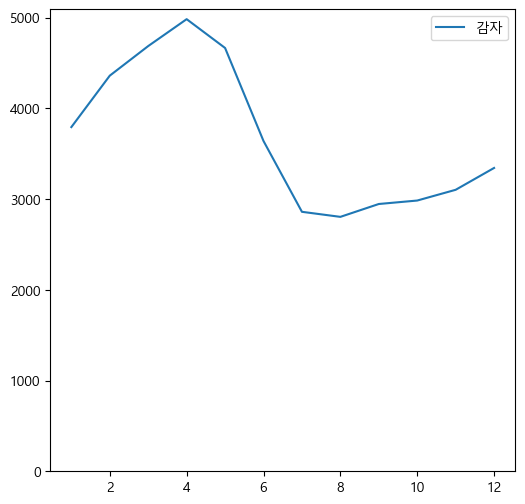

In [95]:
plt.figure(figsize=(6, 6))

x = df[df['품목명']=='감자'].groupby('월').agg(평균=('단위가격', 'mean')).index
y = df[df['품목명']=='감자'].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x, y, label='감자')
plt.ylim(0)
plt.legend()
plt.show()

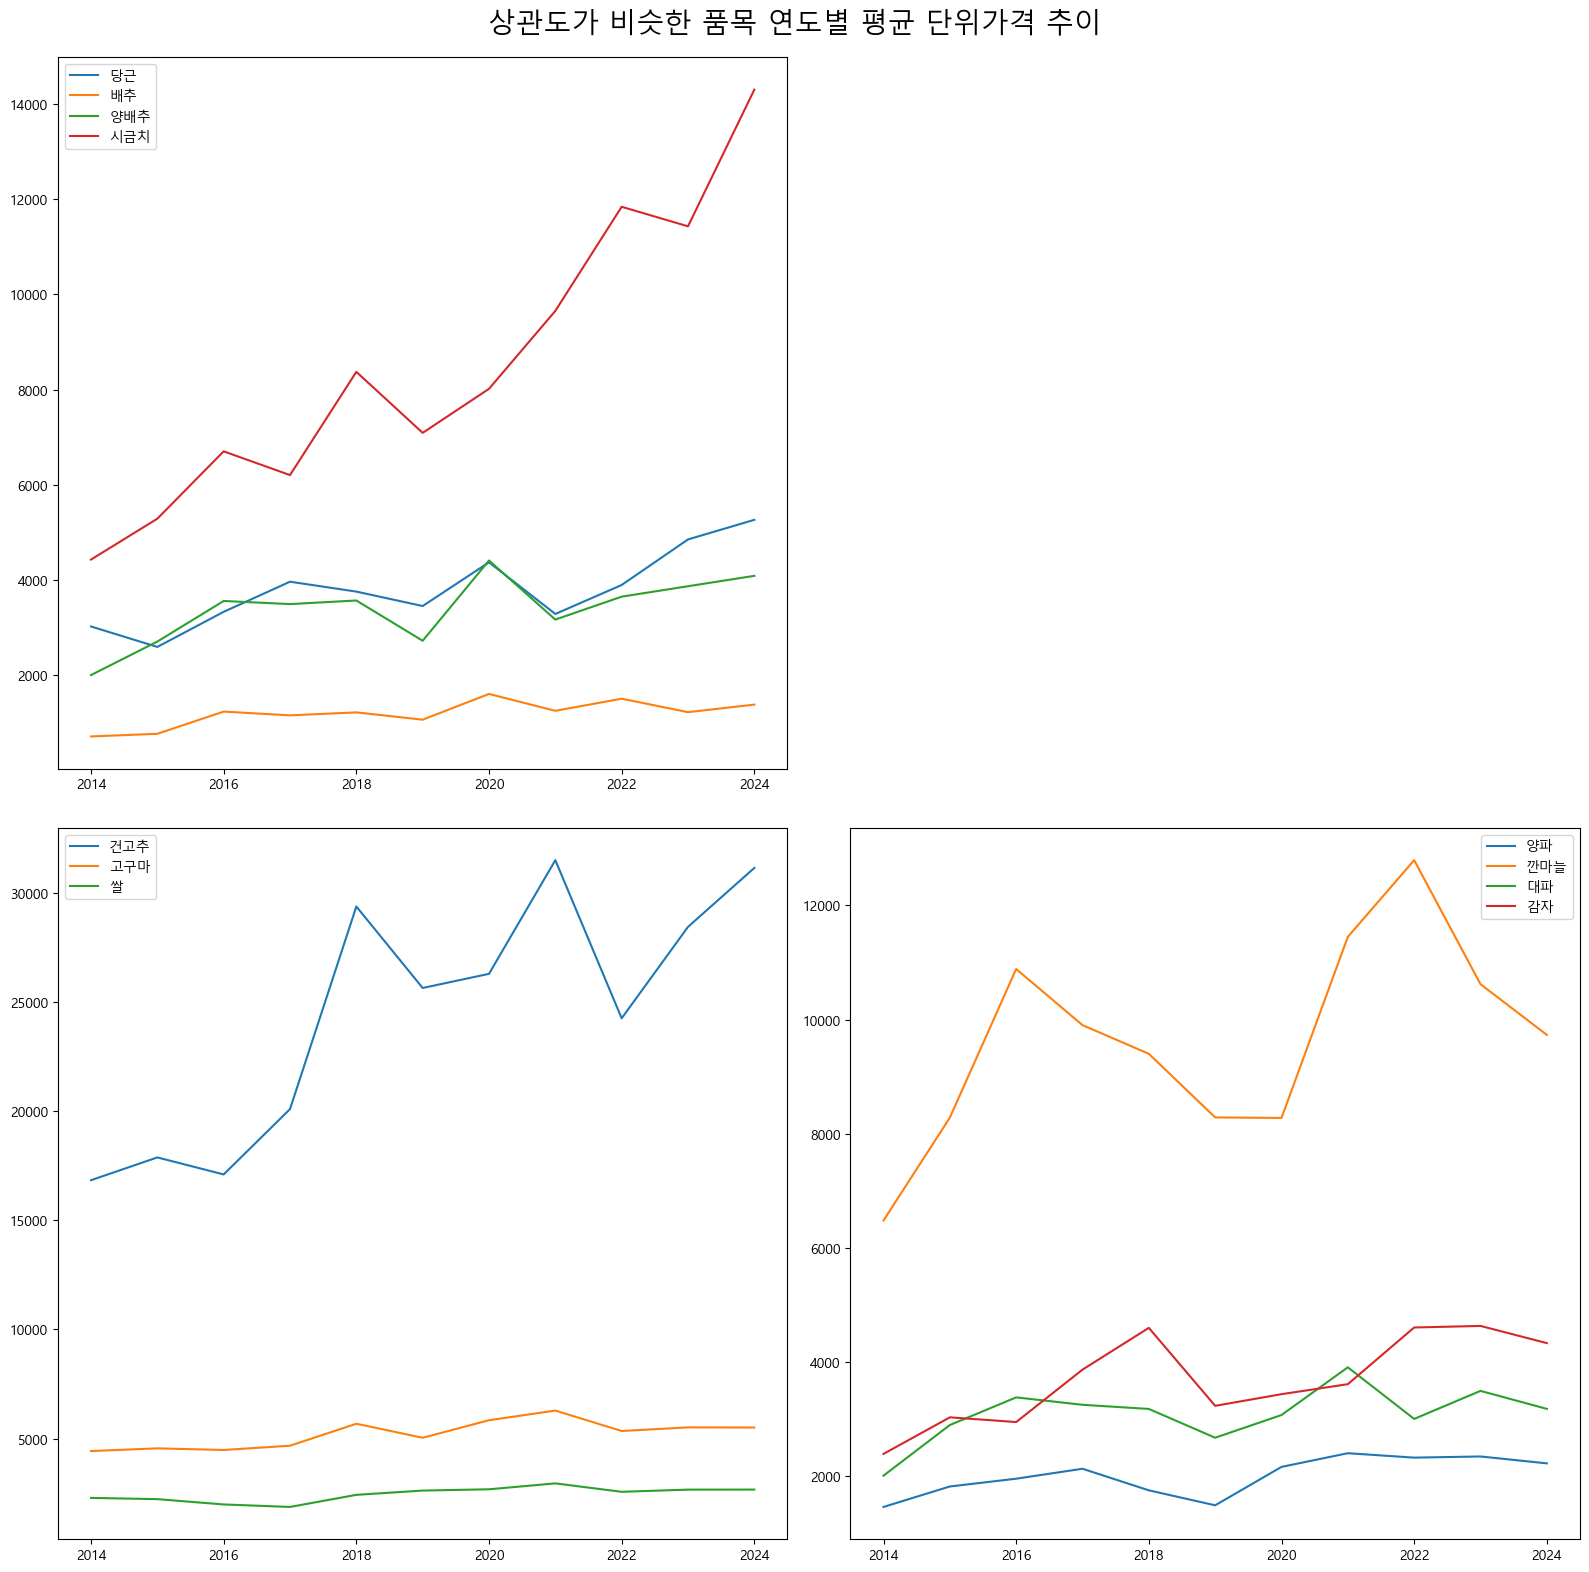

In [55]:
# 상관도가 비슷한 품목 연도별 평균 단위가격 추이
fig = plt.figure( figsize=(16, 16))

plt.subplot(221)
x221 = df[df['품목명']=='당근'].groupby('년').agg(평균=('단위가격', 'mean')).index
y221 = df[df['품목명']=='당근'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x221, y221, label='당근')
x2212 = df[df['품목명']=='배추'].groupby('년').agg(평균=('단위가격', 'mean')).index
y2212 = df[df['품목명']=='배추'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2212, y2212, label='배추')
x2213 = df[df['품목명']=='양배추'].groupby('년').agg(연도별_평균=('단위가격', 'mean')).index
y2213 = df[df['품목명']=='양배추'].groupby('년').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
plt.plot(x2213, y2213, label='양배추')
x2214 = df[df['품목명']=='시금치'].groupby('년').agg(평균=('단위가격', 'mean')).index
y2214 = df[df['품목명']=='시금치'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2214, y2214, label='시금치')
plt.legend()
plt.title(' ')

plt.subplot(223)
x223 = df[df['품목명']=='건고추'].groupby('년').agg(평균=('단위가격', 'mean')).index
y223 = df[df['품목명']=='건고추'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x223, y223, label='건고추')
x2232 = df[df['품목명']=='고구마'].groupby('년').agg(평균=('단위가격', 'mean')).index
y2232 = df[df['품목명']=='고구마'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2232, y2232, label='고구마')
x2233 = df[df['품목명']=='쌀'].groupby('년').agg(평균=('단위가격', 'mean')).index
y2233 = df[df['품목명']=='쌀'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2233, y2233, label='쌀')
plt.legend()
plt.title(' ')

plt.subplot(224)
x224 = df[df['품목명']=='양파'].groupby('년').agg(평균=('단위가격', 'mean')).index
y224 = df[df['품목명']=='양파'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x224, y224, label='양파')
x2242 = df[df['품목명']=='깐마늘'].groupby('년').agg(평균=('단위가격', 'mean')).index
y2242 = df[df['품목명']=='깐마늘'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2242, y2242, label='깐마늘')
x2243 = df[df['품목명']=='대파'].groupby('년').agg(평균=('단위가격', 'mean')).index
y2243 = df[df['품목명']=='대파'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2243, y2243, label='대파')
x2244 = df[df['품목명']=='감자'].groupby('년').agg(평균=('단위가격', 'mean')).index
y2244 = df[df['품목명']=='감자'].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
plt.plot(x2244, y2244, label='감자')
plt.legend()
plt.title(' ')

fig.suptitle('상관도가 비슷한 품목 연도별 평균 단위가격 추이', size=20)
fig.tight_layout()

plt.savefig('상관도가_비슷한_품목_연도별_평균_단위가격(1kg)_추이.png', dpi=200)
plt.show()

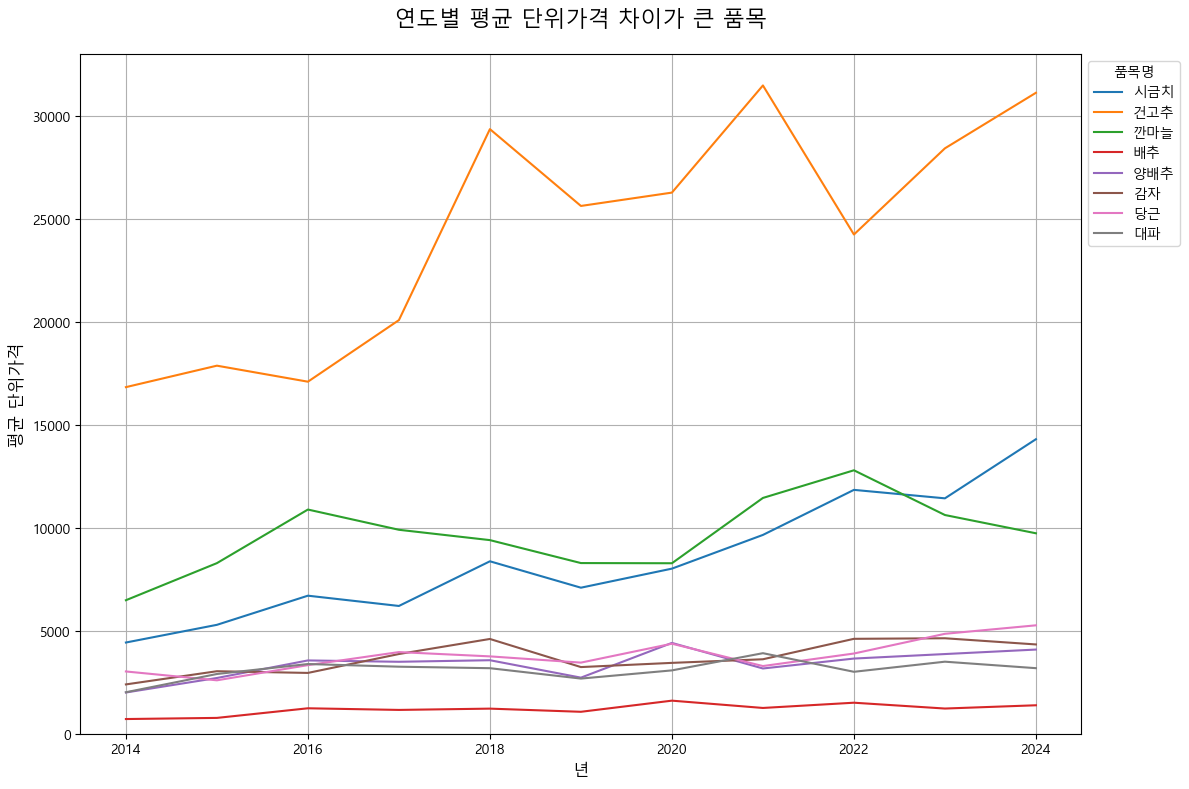

In [56]:
# 품목명 리스트
변동큰품목 = ['시금치', '건고추', '깐마늘', '배추', '양배추', '감자', '당근', '대파']

# 그래프 그리기
plt.figure(figsize=(12, 8))

for item in 변동큰품목:
    x = df[df['품목명'] == item].groupby('년').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
    plt.plot(x, y, label=item)

plt.ylim(0)  # y축 최소값 설정
plt.xlabel('년', fontsize=12)
plt.ylabel('평균 단위가격', fontsize=12)
plt.title('연도별 평균 단위가격 차이가 큰 품목', fontsize=16, pad=20)
plt.legend(title='품목명', bbox_to_anchor=(1, 1), loc='upper left')  # 범례 위치 조정
plt.grid(True)
plt.tight_layout()

plt.savefig('연도별_평균_단위가격_차이가_큰_품목.png', dpi=200)
plt.show()

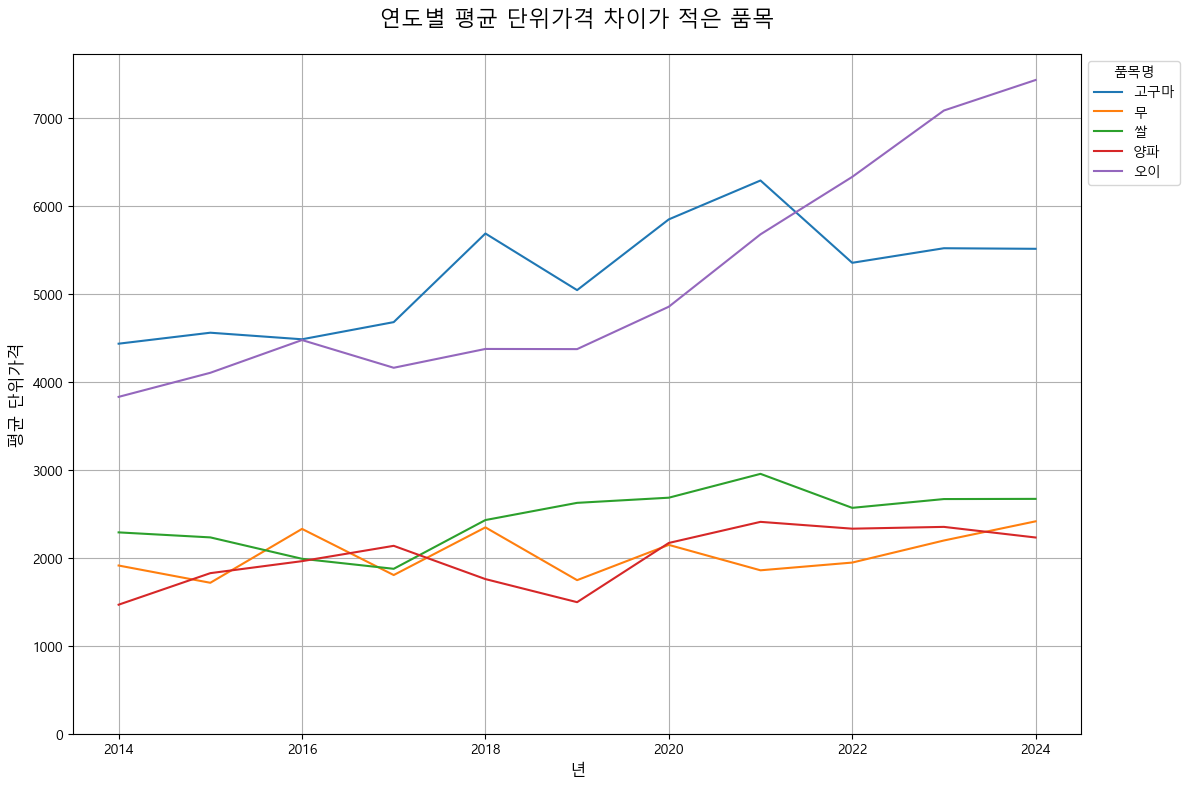

In [57]:
# 품목명 리스트
all_items = list(df['품목명'].unique())
변동큰품목

items = [item for item in all_items if item not in 변동큰품목]

# 그래프 그리기
plt.figure(figsize=(12, 8))

for item in items:
    x = df[df['품목명'] == item].groupby('년').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('년').agg(평균=('단위가격', 'mean'))['평균']
    plt.plot(x, y, label=item)

plt.ylim(0)  # y축 최소값 설정
plt.xlabel('년', fontsize=12)
plt.ylabel('평균 단위가격', fontsize=12)
plt.title('연도별 평균 단위가격 차이가 적은 품목', fontsize=16, pad=20)
plt.legend(title='품목명', bbox_to_anchor=(1, 1), loc='upper left')  # 범례 위치 조정
plt.grid(True)
plt.tight_layout()

plt.savefig('연도별_평균_단위가격_차이가_작은_품목.png', dpi=200)
plt.show()

## 출하량

In [45]:
df

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격
0,2014-01-02,감자,202.0,376.0,442669.9,2.5,5210.0,1706.27,1050.0,2020.0
1,2014-01-03,감자,208.0,376.0,442669.9,2.5,5210.0,1707.15,1055.0,2080.0
2,2014-01-04,감자,208.0,262.0,442669.9,2.5,5210.0,1707.61,1059.0,2080.0
3,2014-01-05,감자,208.0,273.5,442669.9,2.5,5210.0,1707.56,1062.0,2080.0
4,2014-01-06,감자,281.0,285.0,442669.9,2.5,5210.0,1707.80,1065.0,2810.0
...,...,...,...,...,...,...,...,...,...,...
55647,2024-09-26,오이,14994.0,172.0,572413.3,3.5,9860.0,1429.96,1327.0,7497.0
55648,2024-09-27,오이,16108.0,168.0,572413.3,3.5,9860.0,1427.87,1319.0,8054.0
55649,2024-09-28,오이,16108.0,165.0,572413.3,3.5,9860.0,1425.01,1315.0,8054.0
55650,2024-09-29,오이,16108.0,210.5,572413.3,3.5,9860.0,1423.72,1311.0,8054.0


In [52]:
df.loc[(df['품목명']=='배추')][['날짜', '품목명', '평균가격', '가락시장반입량']]

,날짜,품목명,평균가격,가락시장반입량
27853,2014-01-02,배추,2515.0,653.0
27854,2014-01-03,배추,2515.0,527.0
27855,2014-01-04,배추,2515.0,387.0
27856,2014-01-05,배추,2515.0,466.5
27857,2014-01-06,배추,2530.0,546.0
...,...,...,...,...
31773,2024-09-26,배추,9680.0,653.0
31774,2024-09-27,배추,9963.0,625.0
31775,2024-09-28,배추,9963.0,474.0
31776,2024-09-29,배추,9963.0,470.5


NameError: name 'df_price_diff_rate_tail5' is not defined

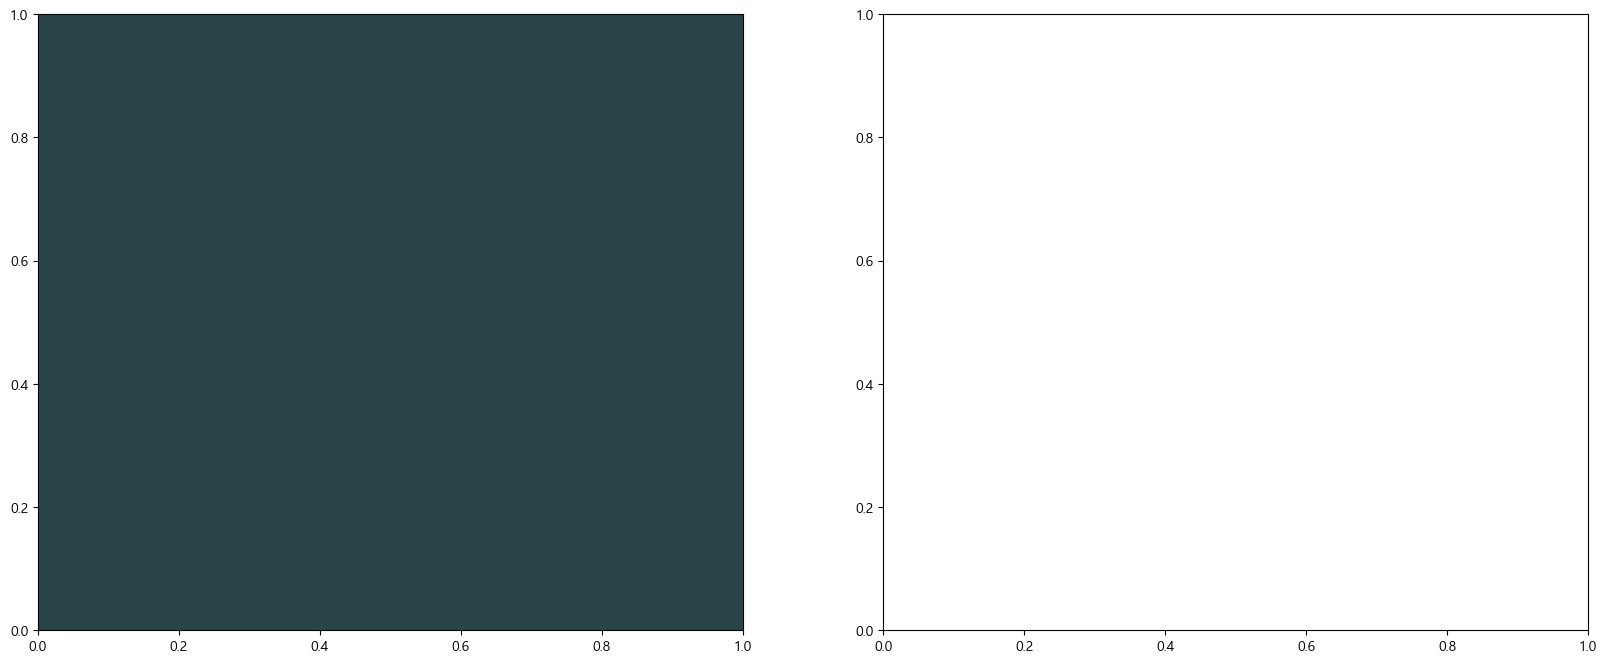

In [54]:
# 품목명과 색상을 매핑하는 딕셔너리 생성
# 모든 가능한 품목명을 포함하도록 조정
color_mapping = {
    '감자': 'peru',         # 감자의 갈색 껍질
    '건고추': 'red',        # 건고추의 강렬한 붉은색
    '고구마': 'orange',     # 고구마의 주황색
    '깐마늘': 'ivory',      # 마늘 속살의 흰색
    '당근': 'darkorange',   # 당근의 진한 주황색
    '대파': 'green',        # 대파의 초록색
    '무': 'white',          # 무의 흰색
    '배추': 'lightgreen',   # 배추의 연녹색
    '시금치': 'forestgreen',# 시금치의 짙은 녹색
    '쌀': 'beige',          # 쌀의 베이지색
    '양배추': 'limegreen',  # 양배추의 밝은 초록색
    '양파': 'gold',         # 양파의 노란색
    '오이': 'mediumseagreen'# 오이의 짙은 녹색
}
# bar_colors = [color_mapping.get(item, default_color) for item in x0]  # 기본 색상으로 처리


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
# ax[0]
ax[0].set_facecolor('#2a4548')
x0 = df_price_diff_rate_tail5['품목명']
y0 = df_price_diff_rate_tail5['가격편차']

ax[0].bar(x0, y0, color=bar_colors, alpha=0.8)

ax[0].set_ylabel('편차비율(%)', fontsize=12)
ax[0].set_yticks(np.arange(0, 1, step=0.1))
ax[0].set_ylim(0, 1)
ax[0].grid(axis='y', ls=':')
ax[0].set_title('가격편차가 작은 품목 TOP5', fontsize=16)

# ax[1]
ax[1].set_facecolor('#2a4548')

for item in 변동큰품목:
    # 월별 평균 계산
    x = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean')).index
    y = df[df['품목명'] == item].groupby('월').agg(평균=('단위가격', 'mean'))['평균']
    # 데이터 플롯
    ax[1].plot(x, y, label=item, color=color_mapping.get(item, default_color))

ax[1].set_ylim(0)  # y축 최소값 설정
ax[1].set_xlabel('월', fontsize=12)
ax[1].set_ylabel('평균 단위가격', fontsize=12)
ax[1].set_title('월별 평균가격 편차 10% 이하인 품목', fontsize=16, pad=20)
ax[1].legend(title="품목명", bbox_to_anchor=(1, 1), loc='upper left', facecolor='#5c979d')
ax[1].grid(axis='y', ls=':')

# 공통 제목 설정
fig.suptitle('월별 평균 단위가격 차이가 작은 품목', fontsize=24)

# 그래프 저장 및 표시
fig.savefig('월별 평균가격 편차 작은 품목.png', dpi=200)
plt.show()

# 군집화

In [9]:
df.sample(5)

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격
49929,2020-12-05,오이,8276.0,124.0,522706.6,0.50,8590.0,1134.35,1086.3,827.6
2800,2021-09-02,감자,303.0,206.0,538085.7,0.75,8720.0,1437.55,1184.0,3030.0
35486,2024-08-23,시금치,3675.0,5.0,572413.3,3.50,9860.0,1517.69,1336.0,36750.0
51106,2024-02-25,오이,20485.0,135.5,572951.0,3.50,9860.0,1535.47,1331.5,2048.5
11776,2024-08-13,고구마,5700.0,107.0,572413.3,3.50,9860.0,1534.35,1336.0,5700.0


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 데이터 전처리
df['연도'] = pd.to_datetime(df['날짜']).dt.year
df['월'] = pd.to_datetime(df['날짜']).dt.month
df_cluster = df[['연도', '월', '평균가격', '가락시장반입량']]

df_cluster

,연도,월,평균가격,가락시장반입량
0,2014,1,202.0,376.0
1,2014,1,208.0,376.0
2,2014,1,208.0,262.0
3,2014,1,208.0,273.5
4,2014,1,281.0,285.0
...,...,...,...,...
51320,2024,9,14994.0,172.0
51321,2024,9,16108.0,168.0
51322,2024,9,16108.0,165.0
51323,2024,9,16108.0,210.5


In [22]:
# 스케일링
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

# K-Means 군집화
kmeans = KMeans(n_clusters=3, random_state=42)
df['클러스터'] = kmeans.fit_predict(scaled_data)

df.sample(5)

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,연도,월,클러스터
39618,2014-04-30,양배추,1939.0,326.000000,446872.4,2.50,5210.0,1685.24,1033.2,1939.0,2014,4,2
28191,2015-06-27,배추,3140.0,291.000000,456256.6,1.50,5580.0,1369.41,1115.5,3140.0,2015,6,2
8147,2014-09-06,고구마,4707.0,27.000000,448023.5,2.25,5210.0,1625.44,1055.2,4707.0,2014,9,1
12574,2015-12-27,깐마늘,9963.0,184.215941,466604.0,1.50,5580.0,1195.84,1172.5,9963.0,2015,12,1
41819,2020-05-09,양배추,6115.0,202.000000,503484.6,0.75,8590.0,1062.51,1238.5,6115.0,2020,5,0


In [23]:
cluster_items = df.groupby('클러스터')['품목명'].unique()

for cluster, items in cluster_items.items():
    print(f"클러스터 {cluster}: {list(items)}")

클러스터 0: ['감자', '건고추', '고구마', '깐마늘', '당근', '대파', '무', '배추', '시금치', '쌀', '양배추', '양파', '오이']
클러스터 1: ['감자', '건고추', '고구마', '깐마늘', '당근', '대파', '무', '배추', '시금치', '쌀', '양배추', '양파', '오이']
클러스터 2: ['감자', '건고추', '고구마', '깐마늘', '당근', '대파', '무', '배추', '시금치', '쌀', '양배추', '양파', '오이']


In [17]:
from sklearn.decomposition import PCA

In [21]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df[['품목명', '평균가격', '가락시장반입량', '클러스터']])

ValueError: could not convert string to float: '감자'

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)

# 수확기간

In [165]:
df_temp = pd.read_csv("C:\\Users\\acorn\\Downloads\\채소사는날\\품목별기간.csv")
df_temp1 = df_temp.transpose().reset_index()

df_temp1.columns = df_temp1.iloc[0, :]
df_temp1.drop(index=[0], inplace=True)
df_temp1['품목명'] = df_temp1['품목명'].str.strip()
df_temp1

,품목명,씨뿌림1,씨뿌림2,씨뿌림3,아주심기1,아주심기2,아주심기3,수확기1,수확기2,수확기3,성출하기1,성출하기2,성출하기3
1,감자,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,건고추,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,고구마,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,깐마늘,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,당근,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,대파,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,무,3월 중순~4월 하순,7월 중순~9월 상순,NaN,NaN,NaN,NaN,5월 중순~7월 상순,9월상~12월 중순,NaN,5월 하순~6월 중순,10월 중순~11월 하순,NaN
8,배추,1월 상순~3월 상순,3월 중순~4월 하순,8월 상순~8월 하순,2월 상순~4월 중순,4월 상순~5월 중순,8월 하순~9월 상순,3월 중순~5월 하순,5월 하순~6월 중순,10월 중순~12월 상순,4월 중순,6중 월순,10월 중순~12월 상순
9,새송이버섯,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,시금치,2월 상순~5월 하순,6월 상순~8월 하순,9월 중순~11월 하순,NaN,NaN,NaN,3월 중순~7월 상순,7월 상순~10월 상순,10월 상순~3월 하순,6월 상순~6월 하순,7월 중순~9월 중순,11월 중순~2월 중순


In [162]:
df_temp1.loc[df_temp1['품목명'].isin(['배추', '시금치', '양파', '오이'])]

,품목명,씨뿌림1,씨뿌림2,씨뿌림3,아주심기1,아주심기2,아주심기3,수확기1,수확기2,수확기3,성출하기1,성출하기2,성출하기3
8,배추,1월 상순~3월 상순,3월 중순~4월 하순,8월 상순~8월 하순,2월 상순~4월 중순,4월 상순~5월 중순,8월 하순~9월 상순,3월 중순~5월 하순,5월 하순~6월 중순,10월 중순~12월 상순,4월 중순,6중 월순,10월 중순~12월 상순
10,시금치,2월 상순~5월 하순,6월 상순~8월 하순,9월 중순~11월 하순,NaN,NaN,NaN,3월 중순~7월 상순,7월 상순~10월 상순,10월 상순~3월 하순,6월 상순~6월 하순,7월 중순~9월 중순,11월 중순~2월 중순
14,양파,8월 중순~9월 중순,3월 상순~3월 중순,NaN,10월 중순~11월 중순,4월 하순~5월 상순,NaN,4월 상순~6월 중순,8월~9월,NaN,6월 상순~7월 상순,9월~10월,NaN
15,오이,10월 상순~11월 중순,12월 상순~1월 중순,2월 상순~3월 중순,11월 상순~12월 중순,1월 상순~2월 중순,3월 상순~4월 중순,1월 중순~4월 하순,3월 중순~6월 하순,5월 중순~7월 하순,2월 상순~3월 중순,4월 상순~6월 중순,6월 상순


In [ ]:
import re

In [166]:
# 기간 변환 함수
def convert_period(period):
    if pd.isna(period):
        return None

    # 월 상순, 중순, 하순 범위 정의
    period_mapping = {
        "상순": ("01", "10"),
        "중순": ("11", "20"),
        "하순": ("21", "30"),
    }
    
    def convert_single_period(month, part):
        start, end = period_mapping[part]
        return f"{int(month):02d}-{start}", f"{int(month):02d}-{end}"
    
    # 패턴 매칭
    ranges = re.findall(r"(\d+)월\s(상순|중순|하순)", period)
    if len(ranges) == 2:
        start_month, start_part = ranges[0]
        end_month, end_part = ranges[1]
        
        start_date = convert_single_period(start_month, start_part)[0]
        end_date = convert_single_period(end_month, end_part)[1]
        
        return f"{start_date}~{end_date}"
    return period

# 데이터프레임 수정
columns_to_update = ["씨뿌림1", "씨뿌림2", "씨뿌림3"]
for column in columns_to_update:
    df_temp1[column] = df_temp1[column].apply(convert_period)

df_temp1

,품목명,씨뿌림1,씨뿌림2,씨뿌림3,아주심기1,아주심기2,아주심기3,수확기1,수확기2,수확기3,성출하기1,성출하기2,성출하기3
1,감자,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,건고추,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,고구마,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,깐마늘,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,당근,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,대파,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,무,03-11~04-30,07-11~09-10,None,NaN,NaN,NaN,5월 중순~7월 상순,9월상~12월 중순,NaN,5월 하순~6월 중순,10월 중순~11월 하순,NaN
8,배추,01-01~03-10,03-11~04-30,08-01~08-30,2월 상순~4월 중순,4월 상순~5월 중순,8월 하순~9월 상순,3월 중순~5월 하순,5월 하순~6월 중순,10월 중순~12월 상순,4월 중순,6중 월순,10월 중순~12월 상순
9,새송이버섯,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,시금치,02-01~05-30,06-01~08-30,09-11~11-30,NaN,NaN,NaN,3월 중순~7월 상순,7월 상순~10월 상순,10월 상순~3월 하순,6월 상순~6월 하순,7월 중순~9월 중순,11월 중순~2월 중순


In [96]:
# 그래프 그릴 때 사용할 컬럼 생성
df['년월'] = df['날짜'].dt.strftime('%Y-%m')
df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month

# 특정 수확 기간에 대해 그래프 영역을 채우는 함수
def plot_harvest_period(ax, df, start_month_day, end_month_day, color, alpha, hatch, label):
    """
    Parameters:
    - ax: matplotlib Axes 객체
    - df: DataFrame (날짜와 유통업체 데이터를 포함해야 함)
    - start_month_day: 수확 시작 날짜 (MM-DD 형식) 예)'05-11'
    - end_month_day: 수확 종료 날짜 (MM-DD 형식) 예)'05-11'
    - color: 채울 영역의 색상
    - alpha: 투명도
    - hatch: 패턴 (예: '/')
    - label: 범례에 사용할 레이블 (첫 번째 반복에서만 적용)
    """
    first = True  # 첫 번째 반복인지 여부를 나타내는 플래그
    for year in range(df['날짜'].dt.year.min(), df['날짜'].dt.year.max()):
        harvest_start = pd.Timestamp(f'{year}-{start_month_day}')
        harvest_end = pd.Timestamp(f'{year}-{end_month_day}')

        mask = (df['날짜'] >= harvest_start) & (df['날짜'] <= harvest_end)
        
        if first:
            ax.fill_between(df['날짜'][mask], df['평균가격'][mask], 
                            color=color, alpha=alpha, hatch=hatch, label=label)
            first = False  # 이후 호출에서는 label을 추가하지 않음
        else:
            ax.fill_between(df['날짜'][mask], df['평균가격'][mask], 
                            color=color, alpha=alpha, hatch=hatch)

df.sample(5)

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,년월,년,월
40898,2017-10-31,양배추,3409.0,261.0,494353.9,1.25,6470.0,1299.33,1120.0,3099.0,2017-10,2017,10
7964,2014-03-07,고구마,3692.0,83.0,442669.9,2.50,5210.0,1697.76,1061.0,3692.0,2014-03,2014,3
40460,2016-08-19,양배추,2846.0,286.0,476110.0,1.25,6030.0,1202.91,1118.0,2587.0,2016-08,2016,8
5627,2018-08-06,건고추,16993.0,0.0,508102.0,1.50,7530.0,1416.92,1124.0,28322.0,2018-08,2018,8
3507,2023-08-10,감자,355.0,206.0,563035.7,3.50,9620.0,1548.16,1316.0,3550.0,2023-08,2023,8


In [ ]:
# # 수학기간 fill_between으로 표시하기
# # 수학기간_1
# plot_harvest_period(
#     ax=ax2,
#     df=df,
#     start_month_day='05-11',
#     end_month_day='06-20',
#     color='skyblue', alpha=0.5, hatch='/', label='봄배추 수확기간'
# )
# # 수학기간_2
# plot_harvest_period(
#     ax=ax2,
#     df=df,
#     start_month_day='11-01',
#     end_month_day='12-20',
#     color='blue', alpha=0.3, hatch='/', label='김장배추 수확기간'
# )

In [5]:
df[df['품목명']=='배추']

,날짜,품목명,평균가격,가락시장반입량,GDP,한은금리,최저시급,경유가격,환율,단위가격,년월,년,월
27650,2014-01-02,배추,2515.0,653.0,442669.9,2.5,5210.0,1706.27,1070.4,2515.0,2014-01,2014,1
27651,2014-01-03,배추,2515.0,527.0,442669.9,2.5,5210.0,1707.15,1070.4,2515.0,2014-01,2014,1
27652,2014-01-04,배추,2515.0,387.0,442669.9,2.5,5210.0,1707.61,1070.4,2515.0,2014-01,2014,1
27653,2014-01-05,배추,2515.0,466.5,442669.9,2.5,5210.0,1707.56,1070.4,2515.0,2014-01,2014,1
27654,2014-01-06,배추,2530.0,546.0,442669.9,2.5,5210.0,1707.80,1070.4,2530.0,2014-01,2014,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31570,2024-09-26,배추,9680.0,653.0,572413.3,3.5,9860.0,1429.96,1307.8,9680.0,2024-09,2024,9
31571,2024-09-27,배추,9963.0,625.0,572413.3,3.5,9860.0,1427.87,1307.8,9963.0,2024-09,2024,9
31572,2024-09-28,배추,9963.0,474.0,572413.3,3.5,9860.0,1425.01,1307.8,9963.0,2024-09,2024,9
31573,2024-09-29,배추,9963.0,470.5,572413.3,3.5,9860.0,1423.72,1307.8,9963.0,2024-09,2024,9


In [11]:
print(df[df['품목명']=='배추']['날짜'])
print(df[df['품목명']=='배추']['평균가격'])

27650   2014-01-02
27651   2014-01-03
27652   2014-01-04
27653   2014-01-05
27654   2014-01-06
           ...    
31570   2024-09-26
31571   2024-09-27
31572   2024-09-28
31573   2024-09-29
31574   2024-09-30
Name: 날짜, Length: 3925, dtype: datetime64[ns]
27650    2515.0
27651    2515.0
27652    2515.0
27653    2515.0
27654    2530.0
          ...  
31570    9680.0
31571    9963.0
31572    9963.0
31573    9963.0
31574    9662.0
Name: 평균가격, Length: 3925, dtype: float64


In [18]:
df_monthly_mean = df.groupby(['월', '품목명']).agg(월별_평균가격=('평균가격', 'mean'))
df_monthly_mean

월별_평균가격
월  품목명              
1  감자     379.305882
   건고추  14414.311765
   고구마   4754.623529
   깐마늘   9417.244118
   당근    3461.694118
...              ...
12 시금치    576.361290
   쌀    49915.374194
   양배추   3637.651613
   양파    2065.148387
   오이   10884.254839

[156 rows x 1 columns]

In [22]:
df_monthly_mean.head(8)

월별_평균가격
월 품목명              
1 감자     379.305882
  건고추  14414.311765
  고구마   4754.623529
  깐마늘   9417.244118
  당근    3461.694118
  대파    3157.702941
  무     2088.391176
  배추    3122.373529

In [13]:
df[df['품목명']=='배추'].groupby('월').agg(월별_평균가격=('평균가격', 'mean'))

,월별_평균가격
월,
1,3122.373529
2,3342.401929
3,3577.821114
4,3860.881818
5,3488.082111
6,3166.151515
7,3826.011730
8,5228.041056
9,6529.472727


In [101]:
df.groupby('년').agg(연도별_평균=('최저시급', 'mean'))

,연도별_평균
년,
2014,5210.0
2015,5580.0
2016,6030.0
2017,6470.0
2018,7530.0
2019,8350.0
2020,8590.0
2021,8720.0
2022,9160.0


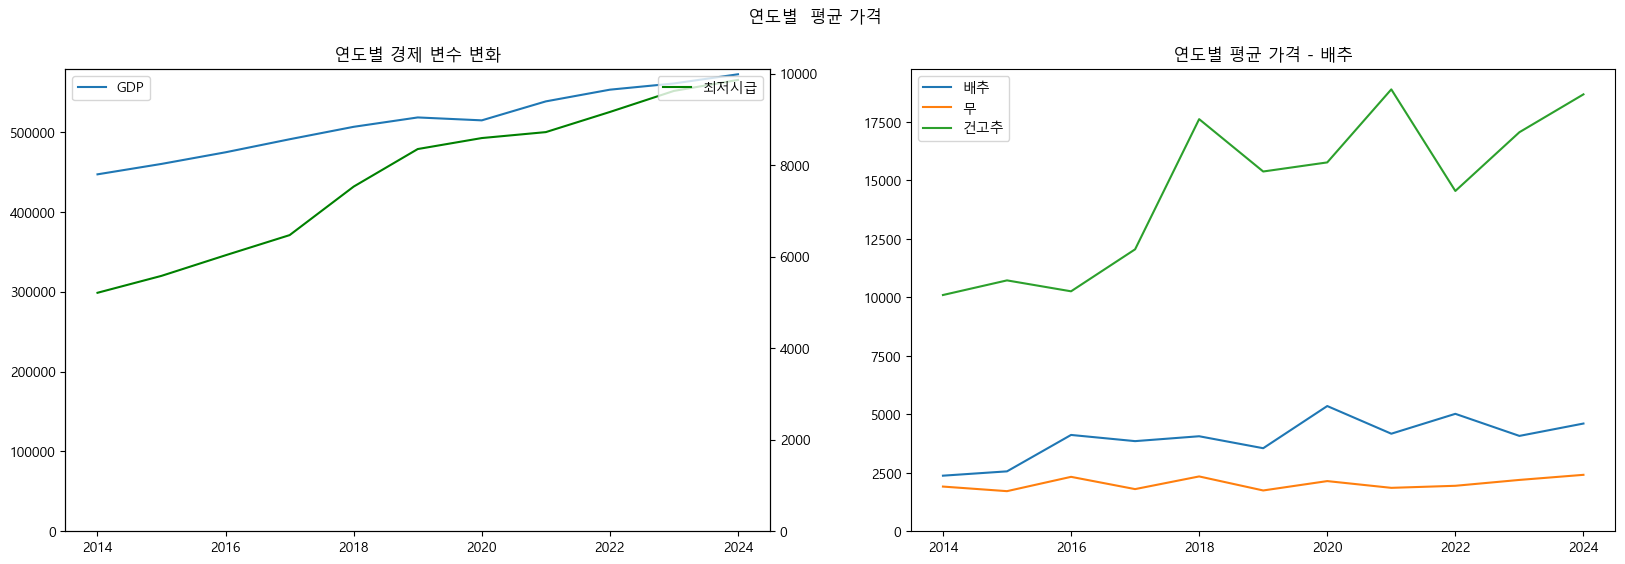

In [105]:
# 연도별
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x00 = df.groupby('년').agg(연도별_평균=('GDP', 'mean')).index
y00 = df.groupby('년').agg(연도별_평균=('GDP', 'mean'))['연도별_평균']
ax[0].plot(x00, y00, label='GDP')

ax2 = ax[0].twinx()
x001 = df.groupby('년').agg(연도별_평균=('최저시급', 'mean')).index
y001 = df.groupby('년').agg(연도별_평균=('최저시급', 'mean'))['연도별_평균']
ax2.plot(x001, y001, label='최저시급', color='green')

ax[0].set_ylim(0)
ax2.set_ylim(0)
ax[0].legend(loc=2)
ax2.legend(loc=1)
ax[0].set_title('연도별 경제 변수 변화')

# ax[1]
x01 = df[df['품목명']=='배추'].groupby('년').agg(연도별_평균=('평균가격', 'mean')).index
y01 = df[df['품목명']=='배추'].groupby('년').agg(연도별_평균=('평균가격', 'mean'))['연도별_평균']
ax[1].plot(x01, y01, label='배추')

x011 = df[df['품목명']=='무'].groupby('년').agg(연도별_평균=('평균가격', 'mean')).index
y011 = df[df['품목명']=='무'].groupby('년').agg(연도별_평균=('평균가격', 'mean'))['연도별_평균']
ax[1].plot(x011, y011, label='무')

x012 = df[df['품목명']=='건고추'].groupby('년').agg(연도별_평균=('평균가격', 'mean')).index
y012 = df[df['품목명']=='건고추'].groupby('년').agg(연도별_평균=('평균가격', 'mean'))['연도별_평균']
ax[1].plot(x012, y012, label='건고추')

ax[1].set_ylim(0)
ax[1].legend()
ax[1].set_title('연도별 평균 가격 - 배추')

# 전체 제목
fig.suptitle('연도별  평균 가격')
plt.show()

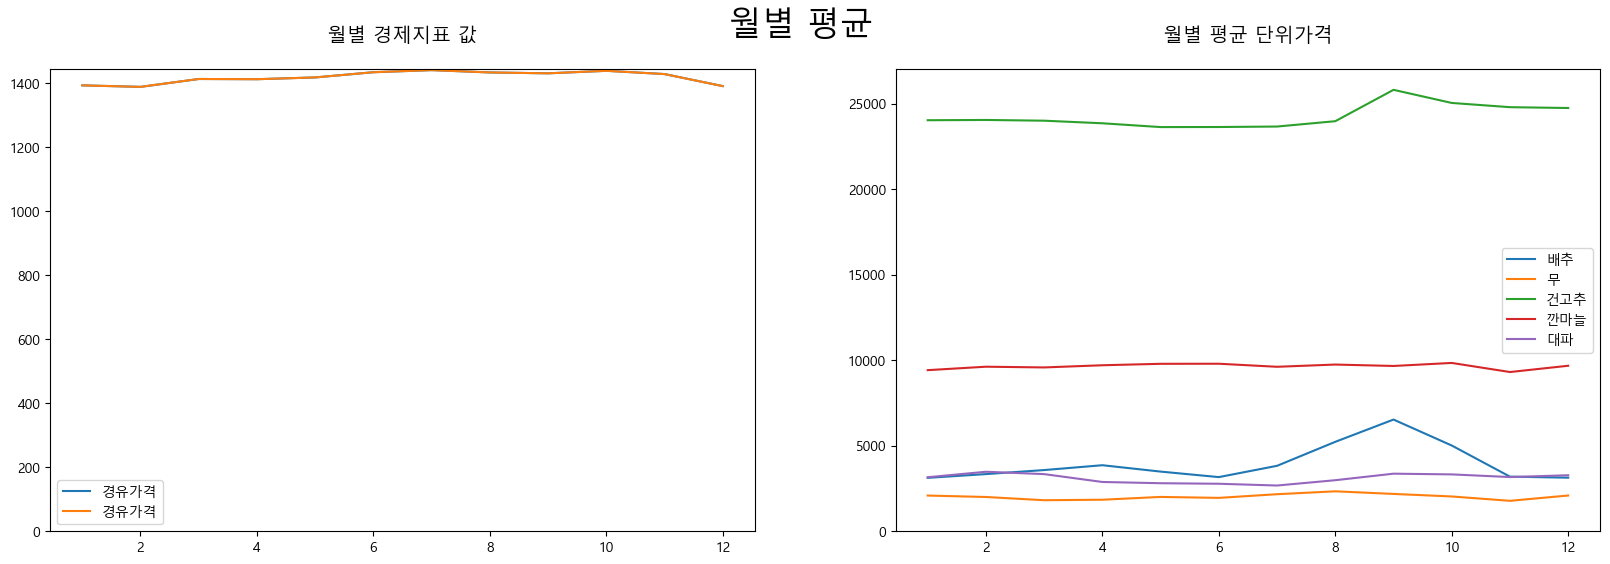

In [51]:
# 월별
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x01 = df.groupby('월').agg(연도별_평균=('경유가격', 'mean')).index
y01 = df.groupby('월').agg(연도별_평균=('경유가격', 'mean'))['연도별_평균']
ax[0].plot(x01, y01, label='경유가격')

x01 = df.groupby('월').agg(연도별_평균=('경유가격', 'mean')).index
y01 = df.groupby('월').agg(연도별_평균=('경유가격', 'mean'))['연도별_평균']
ax[0].plot(x01, y01, label='경유가격')

ax[0].set_ylim(0)
ax[0].legend()
ax[0].set_title('월별 경제지표 값', fontsize=14, pad=20)


# ax[1]
x11 = df[df['품목명']=='배추'].groupby('월').agg(연도별_평균=('단위가격', 'mean')).index
y11 = df[df['품목명']=='배추'].groupby('월').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
ax[1].plot(x11, y11, label='배추')

x12 = df[df['품목명']=='무'].groupby('월').agg(연도별_평균=('단위가격', 'mean')).index
y12 = df[df['품목명']=='무'].groupby('월').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
ax[1].plot(x12, y12, label='무')

x13 = df[df['품목명']=='건고추'].groupby('월').agg(연도별_평균=('단위가격', 'mean')).index
y13 = df[df['품목명']=='건고추'].groupby('월').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
ax[1].plot(x13, y13, label='건고추')

x14 = df[df['품목명']=='깐마늘'].groupby('월').agg(연도별_평균=('단위가격', 'mean')).index
y14 = df[df['품목명']=='깐마늘'].groupby('월').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
ax[1].plot(x14, y14, label='깐마늘')

x15 = df[df['품목명']=='대파'].groupby('월').agg(연도별_평균=('단위가격', 'mean')).index
y15 = df[df['품목명']=='대파'].groupby('월').agg(연도별_평균=('단위가격', 'mean'))['연도별_평균']
ax[1].plot(x15, y15, label='대파')


ax[1].set_ylim(0)
ax[1].legend()
ax[1].set_title('월별 평균 단위가격', fontsize=14, pad=20)

# 전체 제목
fig.suptitle('월별 평균', fontsize=24)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


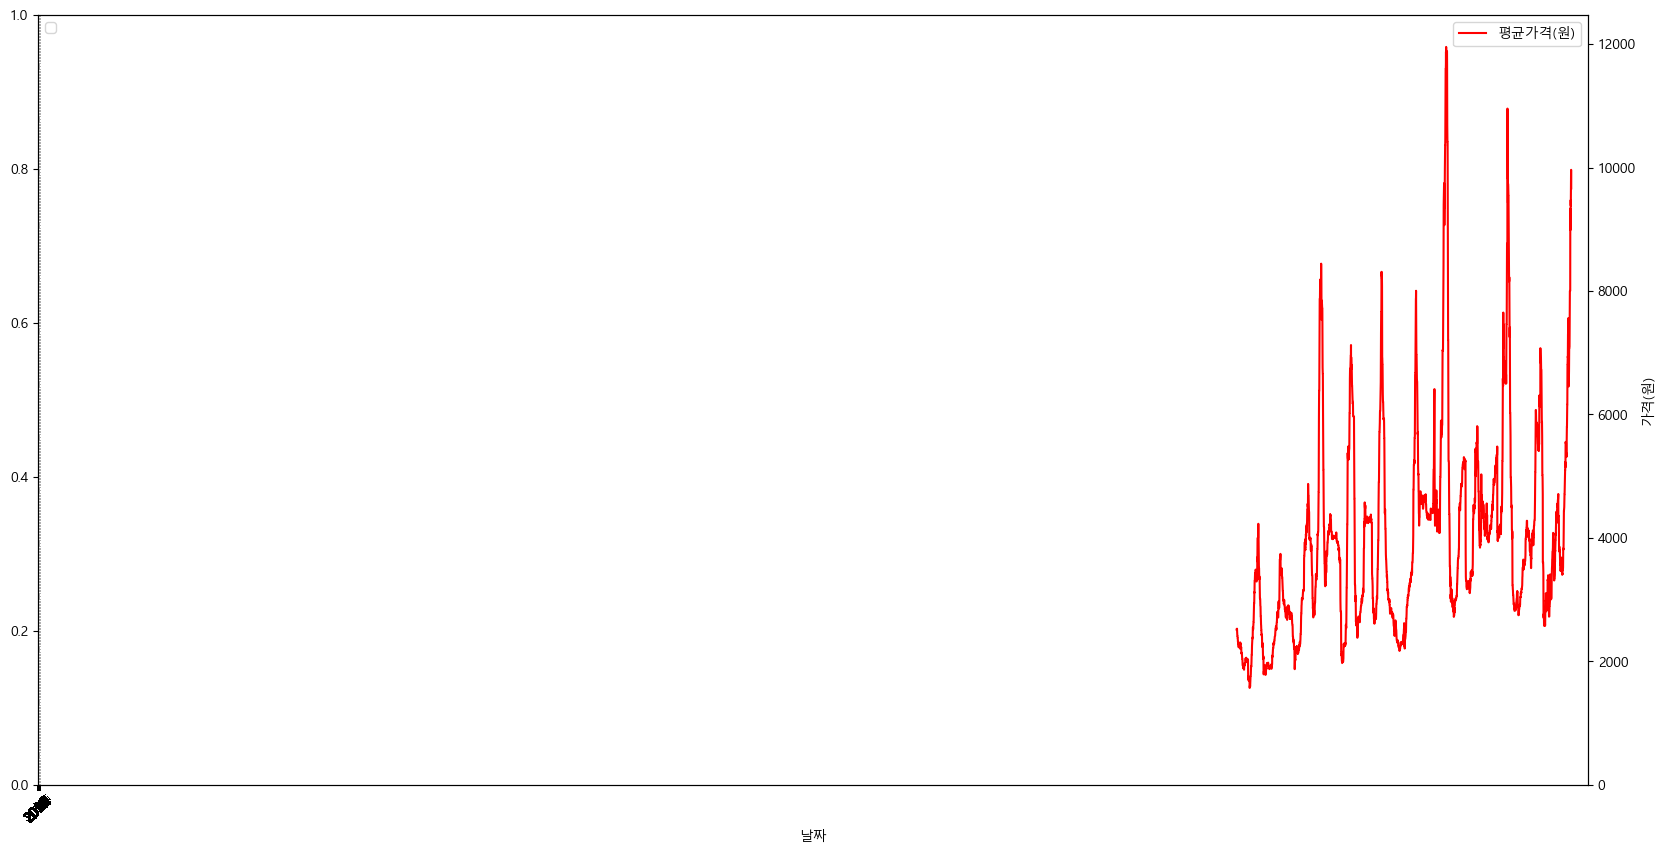

In [9]:
fig, ax1 = plt.subplots(figsize=(20, 10))

# (단위가 다른 문제를 MinMaxScaling 하면 ax1에 여러가지 변수 같이 그릴 수 있음)

# 총반입량
# ax1.plot(df['날짜'], df['가락시장반입량'], alpha=0.6, color='green', label='가락시장반입량')

# GDP
# ax1.plot(df['날짜'], df['GDP(10억원단위)'], alpha=0.6, color='green', label='GDP')

# 한은금리
# ax1.plot(df['날짜'], df['한은금리'], alpha=0.6, color='green', label='한은금리')

# 시간급
# ax1.plot(df['날짜'], df['시간급'], alpha=0.6, color='green', label='시간급여')

# 자동차용경유
# ax1.plot(df['날짜'], df['경유가격'], color='black', label='경유가격')

# 수입금액
# ax1.plot(df['날짜'], df['수입금액($)'], color='black', label='수입금액')

# 수입중량
# ax1.plot(df['날짜'], df['수입중량(kg)'], color='black', label='수입중량')




# x축 공유하는 오른쪽 y축 그래프
ax2 = ax1.twinx() 
ax2.plot(df[df['품목명']=='배추']['날짜'], df[df['품목명']=='배추']['평균가격'], color='red', label='평균가격(원)')

# 단위가격(원/kg)
# ax2.plot(df['날짜'], df['단위가격(원/kg)']*3, color='blue', label='수입배추단위가격(원/kg)')

# xticks 위치 설정
# xticks_list = df[df['월'] % 6 == 0]['년월']
xticks_list = df['년']
ax1.set_xticks(xticks_list)
ax1.set_xticklabels(xticks_list, rotation=45)


# # 수학기간 fill_between으로 표시하기
# # 수학기간_1
# plot_harvest_period(
#     ax=ax2,
#     df=df,
#     start_month_day='05-11',
#     end_month_day='06-20',
#     color='skyblue', alpha=0.5, hatch='/', label='봄배추 수확기간'
# )
# # 수학기간_2
# plot_harvest_period(
#     ax=ax2,
#     df=df,
#     start_month_day='11-01',
#     end_month_day='12-20',
#     color='blue', alpha=0.3, hatch='/', label='김장배추 수확기간'
# )


# 레이블과 축 설정
ax1.set_xlabel('날짜')
# ax1.set_ylabel('GDP(10억원단위)')
ax2.set_ylabel('가격(원)')
ax2.set_ylim(0)
ax1.grid(axis='x', alpha=0.2, ls=':') # , ls=':'


# 범례 위치
ax1.legend(loc=2)
ax2.legend(loc=1)


# 제목
# ax1.set_title('')

# plt.savefig('가격변화.png', dpi=200)
plt.show()


# 년도별로 보기

In [16]:
# df.groupby('년').agg(년도별_평균가격 = ('유통업체가격', 'mean'))

# 년도별 평균 가격 데이터프레임 생성
df_yearly_mean_price = df.groupby('년').agg(연평균_유통업체가격=('유통업체가격', 'mean')).reset_index()
# df_yearly_mean_price

# 전년도 값과의 차이 계산
df_yearly_mean_price['증감률(%)'] = df_yearly_mean_price['연평균_유통업체가격'].diff() / df_yearly_mean_price['연평균_유통업체가격'].shift(1) * 100
df_yearly_mean_price

,년,연평균_유통업체가격,증감률(%)
0,2014,1843.313187,NaN
1,2015,1999.282192,8.461340
2,2016,3362.398907,68.180306
3,2017,2880.673973,-14.326823
4,2018,3297.410959,14.466649
5,2019,2836.589041,-13.975265
6,2020,4073.937158,43.620986
7,2021,3534.416438,-13.243226
8,2022,4160.736986,17.720621
9,2023,3605.271233,-13.350177


In [15]:
def calculate_grouped_mean_and_rate(df, period, col_name):
    """
    특정 기간(period)별 평균값과 증감률을 계산하여 딕셔너리로 반환하는 함수
    
    Parameters:
    - df : DataFrame
    - period : 그룹화할 기간 (예: '년', '월', '분기' 등)
    - col_name : 평균값을 계산할 대상 컬럼명 (예: '유통업체가격')
    
    Returns:
    - dict : {'평균값': DataFrame, '증감률': DataFrame}
    """
    # 그룹화하여 평균값 계산
    grouped_df = (
        df.groupby(period)
        .agg({col_name: 'mean'})
        .rename(columns={col_name: f"{period}_평균_{col_name}"})
        .reset_index()
    )
    
    # 증감률 계산
    grouped_df[f"{period}_증감률(%)"] = (
        grouped_df[f"{period}_평균_{col_name}"].diff() / grouped_df[f"{period}_평균_{col_name}"].shift(1) * 100
    )
    
    # 딕셔너리에 결과 저장
    result_dict = {
        '평균값': grouped_df[[period, f"{period}_평균_{col_name}"]],
        '증감률': grouped_df[[period, f"{period}_증감률(%)"]]
    }
    
    return result_dict

In [19]:
# 예: '년' 단위로 '유통업체가격'의 평균값과 증감률 계산
result = calculate_grouped_mean_and_rate(df, '년', '유통업체가격')

# 평균값 결과
mean_df = result['평균값']
print("평균값 DataFrame:")
print(mean_df)

# 증감률 결과
rate_df = result['증감률']
print("\n증감률 DataFrame:")
print(rate_df)

평균값 DataFrame:
       년  년_평균_유통업체가격
0   2014  1843.313187
1   2015  1999.282192
2   2016  3362.398907
3   2017  2880.673973
4   2018  3297.410959
5   2019  2836.589041
6   2020  4073.937158
7   2021  3534.416438
8   2022  4160.736986
9   2023  3605.271233
10  2024  3860.306569

증감률 DataFrame:
       년   년_증감률(%)
0   2014        NaN
1   2015   8.461340
2   2016  68.180306
3   2017 -14.326823
4   2018  14.466649
5   2019 -13.975265
6   2020  43.620986
7   2021 -13.243226
8   2022  17.720621
9   2023 -13.350177
10  2024   7.073957


In [36]:
yearly_result_GDP['평균값'].head()

,년,년_평균_GDP
0,2014,447029.719505
1,2015,460104.982967
2,2016,474673.037534
3,2017,490986.621154
4,2018,506569.581593


In [37]:
yearly_result_GDP['증감률'].head()

,년,년_증감률(%)
0,2014,NaN
1,2015,2.924920
2,2016,3.166246
3,2017,3.436804
4,2018,3.173806


In [38]:
yearly_result_GDP['증감률']['년_증감률(%)']

0          NaN
1     2.924920
2     3.166246
3     3.436804
4     3.173806
5     2.316329
6    -0.708654
7     4.622547
8     2.720796
9     1.407301
10    2.047411
Name: 년_증감률(%), dtype: float64

In [101]:
yearly_result_GDP = calculate_grouped_mean_and_rate(df, '년', 'GDP')
yearly_result_한은금리 = calculate_grouped_mean_and_rate(df, '년', '한은금리')
yearly_result_최저시급 = calculate_grouped_mean_and_rate(df, '년', '최저시급')
yearly_result_환율 = calculate_grouped_mean_and_rate(df, '년', '환율')
yearly_result_경유가격 = calculate_grouped_mean_and_rate(df, '년', '경유가격')

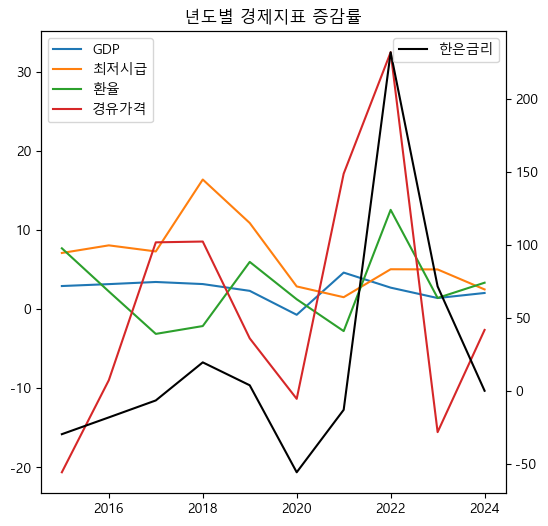

In [102]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x_GDP = yearly_result_GDP['증감률']['년']
y_GDP = yearly_result_GDP['증감률']['년_증감률(%)']
ax1.plot(x_GDP, y_GDP, label='GDP')

x_최저시급 = yearly_result_최저시급['증감률']['년']
y_최저시급 = yearly_result_최저시급['증감률']['년_증감률(%)']
ax1.plot(x_최저시급, y_최저시급, label='최저시급')

x_환율 = yearly_result_환율['증감률']['년']
y_환율 = yearly_result_환율['증감률']['년_증감률(%)']
ax1.plot(x_환율, y_환율, label='환율')

x_경유가격 = yearly_result_경유가격['증감률']['년']
y_경유가격 = yearly_result_경유가격['증감률']['년_증감률(%)']
ax1.plot(x_경유가격, y_경유가격, label='경유가격')

ax2 = ax1.twinx() 
x_한은금리 = yearly_result_한은금리['증감률']['년']
y_한은금리 = yearly_result_한은금리['증감률']['년_증감률(%)']
ax2.plot(x_한은금리, y_한은금리, label='한은금리', color='black')

ax1.legend(loc=2)
ax2.legend(loc=1)

plt.title('년도별 경제지표 증감률')
plt.show()

In [16]:
yearly_result_GDP_scaled = calculate_grouped_mean_and_rate(df_경제독립변수_scaled, '년', 'GDP')
yearly_result_한은금리_scaled = calculate_grouped_mean_and_rate(df_경제독립변수_scaled, '년', '한은금리')
yearly_result_최저시급_scaled = calculate_grouped_mean_and_rate(df_경제독립변수_scaled, '년', '최저시급')
yearly_result_환율_scaled = calculate_grouped_mean_and_rate(df_경제독립변수_scaled, '년', '환율')
yearly_result_경유가격_scaled = calculate_grouped_mean_and_rate(df_경제독립변수_scaled, '년', '경유가격')

NameError: name 'df_경제독립변수_scaled' is not defined

NameError: name 'yearly_result_GDP_scaled' is not defined

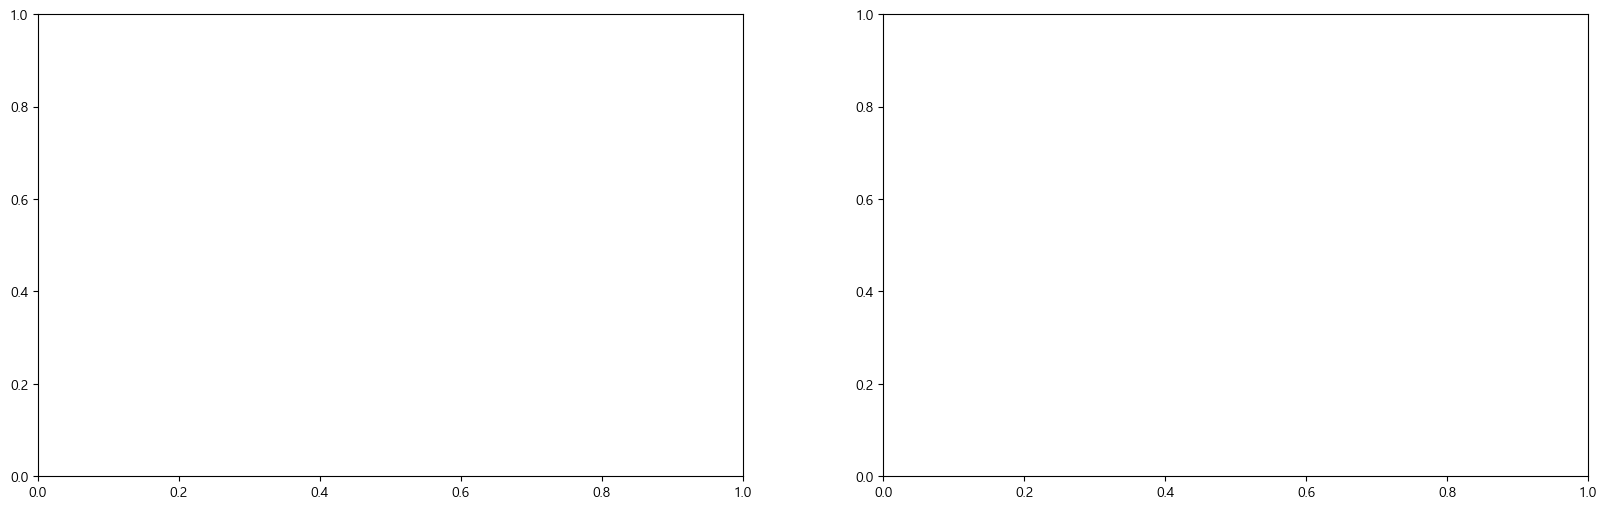

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

x_GDP_scaled = yearly_result_GDP_scaled['평균값']['년']
y_GDP_scaled = yearly_result_GDP_scaled['평균값']['년_평균_GDP']
ax[0].plot(x_GDP_scaled, y_GDP_scaled, label='GDP')

x_한은금리_scaled = yearly_result_한은금리_scaled['평균값']['년']
y_한은금리_scaled = yearly_result_한은금리_scaled['평균값']['년_평균_한은금리']
ax[0].plot(x_한은금리_scaled, y_한은금리_scaled, label='한은금리')

x_최저시급_scaled = yearly_result_최저시급_scaled['평균값']['년']
y_최저시급_scaled = yearly_result_최저시급_scaled['평균값']['년_평균_최저시급']
ax[0].plot(x_최저시급_scaled, y_최저시급_scaled, label='최저시급')

x_환율_scaled = yearly_result_환율_scaled['평균값']['년']
y_환율_scaled = yearly_result_환율_scaled['평균값']['년_평균_환율']
ax[0].plot(x_환율_scaled, y_환율_scaled, label='환율')

x_경유가격_scaled = yearly_result_경유가격_scaled['평균값']['년']
y_경유가격_scaled = yearly_result_경유가격_scaled['평균값']['년_평균_경유가격']
ax[0].plot(x_경유가격_scaled, y_경유가격_scaled, label='경유가격')

ax[0].legend(loc=2)
ax2.legend(loc=1)



# ax[1]
x01 = df.groupby('월').agg(월별_평균가격=('가락시장반입량', 'mean')).index
y01 = df.groupby('월').agg(월별_평균가격=('가락시장반입량', 'mean'))['월별_평균가격']
ax[1].plot(x01, y01)
ax[1].set_title('가락시장 월별 평균 반입량')

# 전체 제목
plt.title('년도별 변화')

plt.show()

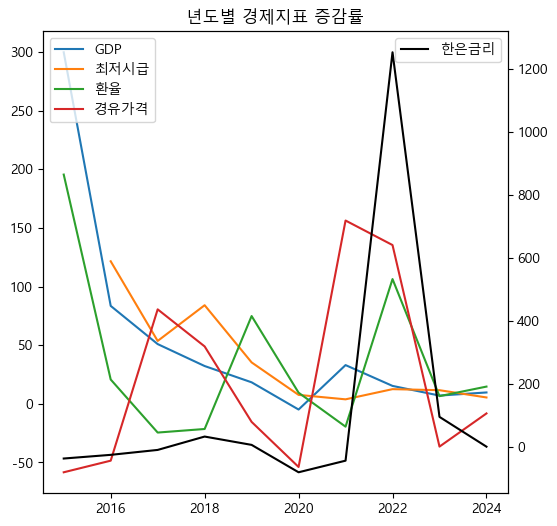

In [100]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x_GDP_scaled = yearly_result_GDP_scaled['증감률']['년']
y_GDP_scaled = yearly_result_GDP_scaled['증감률']['년_증감률(%)']
ax1.plot(x_GDP_scaled, y_GDP_scaled, label='GDP')

x_최저시급_scaled = yearly_result_최저시급_scaled['증감률']['년']
y_최저시급_scaled = yearly_result_최저시급_scaled['증감률']['년_증감률(%)']
ax1.plot(x_최저시급_scaled, y_최저시급_scaled, label='최저시급')

x_환율_scaled = yearly_result_환율_scaled['증감률']['년']
y_환율_scaled = yearly_result_환율_scaled['증감률']['년_증감률(%)']
ax1.plot(x_환율_scaled, y_환율_scaled, label='환율')

x_경유가격_scaled = yearly_result_경유가격_scaled['증감률']['년']
y_경유가격_scaled = yearly_result_경유가격_scaled['증감률']['년_증감률(%)']
ax1.plot(x_경유가격_scaled, y_경유가격_scaled, label='경유가격')

ax2 = ax1.twinx() 
x_한은금리_scaled = yearly_result_한은금리_scaled['증감률']['년']
y_한은금리_scaled = yearly_result_한은금리_scaled['증감률']['년_증감률(%)']
ax2.plot(x_한은금리_scaled, y_한은금리_scaled, label='한은금리', color='black')

ax1.legend(loc=2)
ax2.legend(loc=1)

plt.title('년도별 경제지표 증감률')
plt.show()

In [78]:
df.groupby('년').agg(년도별_GDP = ('GDP', 'mean'))

,년도별_GDP
년,
2014,447029.719505
2015,460104.982967
2016,474673.037534
2017,490986.621154
2018,506569.581593
2019,518303.400275
2020,514630.420274
2021,538419.451923
2022,553068.744231


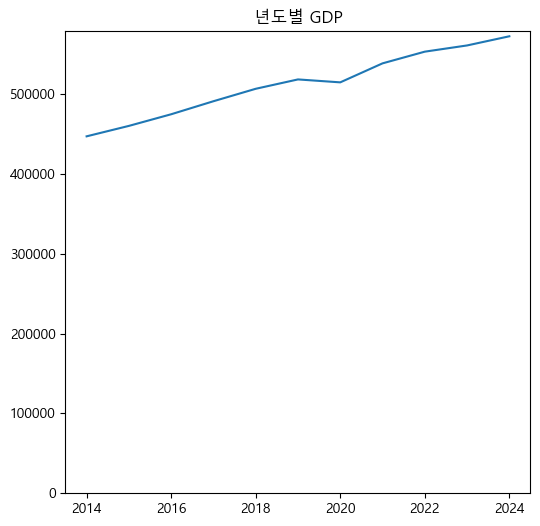

In [31]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(년도별_GDP = ('GDP', 'mean')).index
y= df.groupby('년').agg(년도별_GDP = ('GDP', 'mean'))['년도별_GDP']
ax1.plot(x, y)

ax1.set_ylim(0)

plt.title('년도별 GDP')
plt.show()

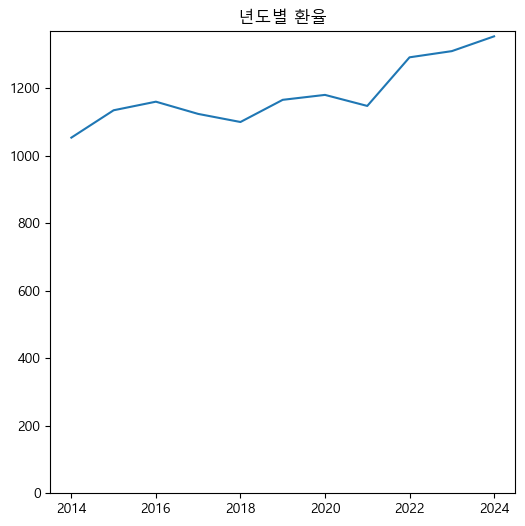

In [32]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(년도별_환율 = ('환율', 'mean')).index
y= df.groupby('년').agg(년도별_환율 = ('환율', 'mean'))['년도별_환율']
ax1.plot(x, y)

ax1.set_ylim(0)

plt.title('년도별 환율')
plt.show()

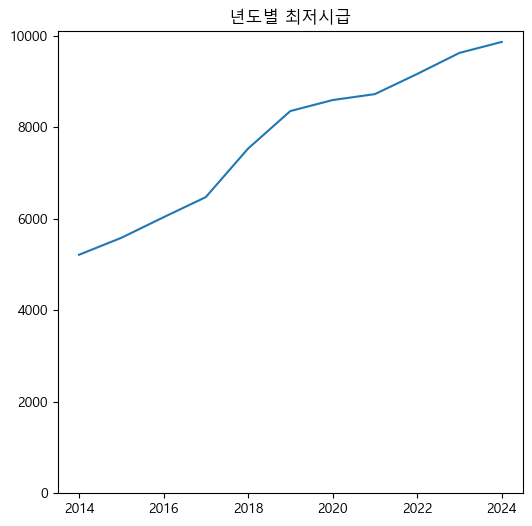

In [33]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(년도별_최저시급 = ('최저시급', 'mean')).index
y= df.groupby('년').agg(년도별_최저시급 = ('최저시급', 'mean'))['년도별_최저시급']
ax1.plot(x, y)

ax1.set_ylim(0)

plt.title('년도별 최저시급')
plt.show()

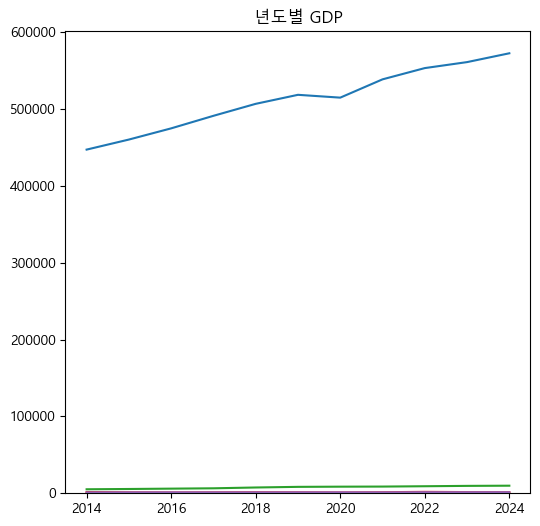

In [63]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(년도별_GDP = ('GDP', 'mean')).index
y= df.groupby('년').agg(년도별_GDP = ('GDP', 'mean'))['년도별_GDP']
ax1.plot(x, y)

x = df.groupby('년').agg(년도별_한은금리 = ('한은금리', 'mean')).index
y= df.groupby('년').agg(년도별_한은금리 = ('한은금리', 'mean'))['년도별_한은금리']
ax1.plot(x, y)

x = df.groupby('년').agg(년도별_최저시급 = ('최저시급', 'mean')).index
y= df.groupby('년').agg(년도별_최저시급 = ('최저시급', 'mean'))['년도별_최저시급']
ax1.plot(x, y)

x = df.groupby('년').agg(년도별_경유가격 = ('경유가격', 'mean')).index
y= df.groupby('년').agg(년도별_경유가격 = ('경유가격', 'mean'))['년도별_경유가격']
ax1.plot(x, y)

x = df.groupby('년').agg(년도별_환율 = ('환율', 'mean')).index
y= df.groupby('년').agg(년도별_환율 = ('환율', 'mean'))['년도별_환율']
ax1.plot(x, y)

ax1.set_ylim(0)

plt.title('년도별 GDP')
plt.show()

# 월별 보기

In [42]:
df.groupby(['년', '월']).agg(년월별_평균가격 = ('유통업체가격', 'mean'))

년월별_평균가격
년    월             
2014 1  1882.200000
     2  1659.964286
     3  1370.096774
     4  1472.600000
     5  1311.709677
...             ...
2024 5  2938.225806
     6  3207.933333
     7  4557.935484
     8  5537.870968
     9  6383.666667

[129 rows x 1 columns]

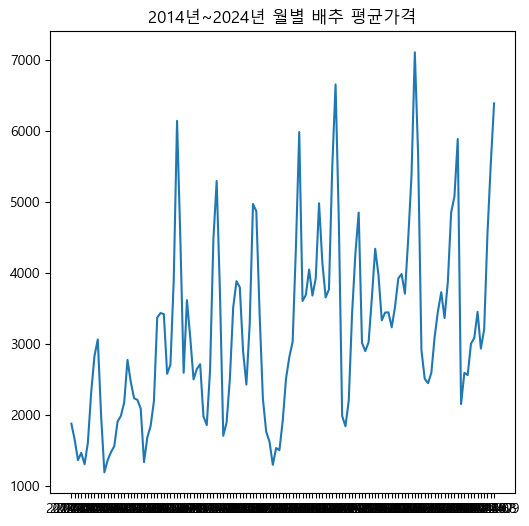

In [81]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년월').agg(년도별_평균가격 = ('유통업체가격', 'mean')).index
y= df.groupby('년월').agg(년도별_평균가격 = ('유통업체가격', 'mean'))['년도별_평균가격']
ax1.plot(x, y)

plt.title('2014년~2024년 월별 배추 평균가격')
plt.show()

In [43]:
df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean'))

,월별_평균가격
월,
1,2471.488235
2,2612.067524
3,2966.941349
4,3236.378788
5,2867.331378
6,2784.490909
7,3268.055718
8,4214.120235
9,5045.387879


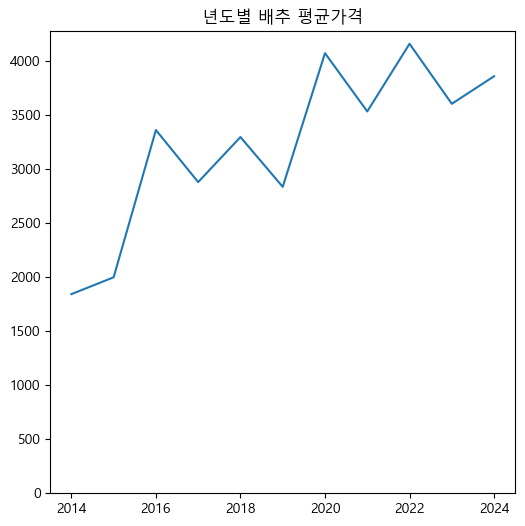

In [109]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(연평균_유통업체가격 = ('유통업체가격', 'mean')).index
y= df.groupby('년').agg(연평균_유통업체가격 = ('유통업체가격', 'mean'))['연평균_유통업체가격']
ax1.plot(x, y)

ax1.set_ylim(0)

plt.title('년도별 배추 평균가격')
plt.show()

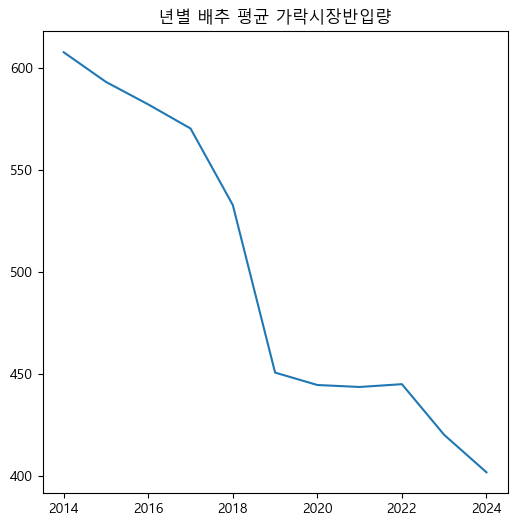

In [110]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(월별_평균가격 = ('가락시장반입량', 'mean')).index
y = df.groupby('년').agg(월별_평균가격 = ('가락시장반입량', 'mean'))
ax1.plot(x, y)

plt.title('년별 배추 평균 가락시장반입량')
plt.show()

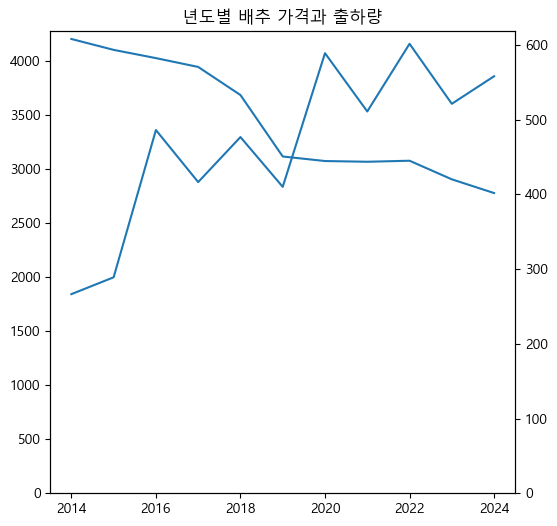

In [111]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(연평균_유통업체가격 = ('유통업체가격', 'mean')).index
y= df.groupby('년').agg(연평균_유통업체가격 = ('유통업체가격', 'mean'))['연평균_유통업체가격']
ax1.plot(x, y, label=")

ax2 = ax1.twinx()
x = df.groupby('년').agg(월별_평균가격 = ('가락시장반입량', 'mean')).index
y = df.groupby('년').agg(월별_평균가격 = ('가락시장반입량', 'mean'))
ax2.plot(x, y)

ax1.set_ylim(0)
ax2.set_ylim(0)

plt.title('년도별 배추 가격과 출하량')
plt.show()

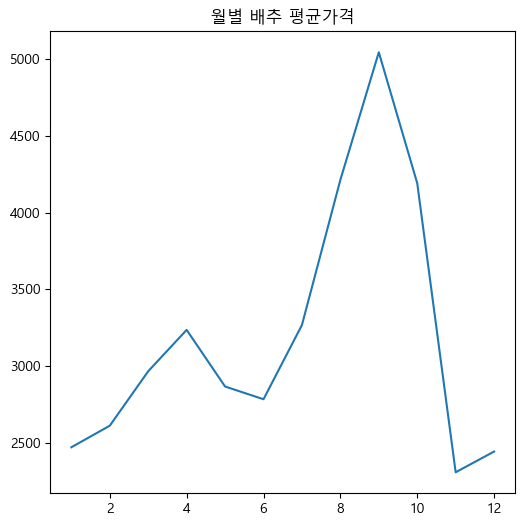

In [49]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean')).index
y= df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean'))
ax1.plot(x, y)

plt.title('월별 배추 평균가격')
plt.show()

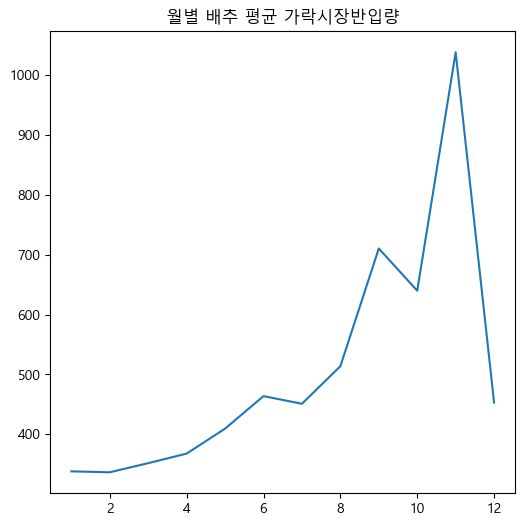

In [50]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('월').agg(월별_평균가격 = ('가락시장반입량', 'mean')).index
y = df.groupby('월').agg(월별_평균가격 = ('가락시장반입량', 'mean'))
ax1.plot(x, y)

plt.title('월별 배추 평균 가락시장반입량')
plt.show()

# 봄배추 생산량이 더 많다고 했는데, 이 그래프만 보면 김장배추 생산량(출하량)이 2배 많음.
# 다른 도매시장 출하량도 다운 받아서 확인해볼 수 있음
# 봄배추는 김치공장으로 대부분 간다고 생각할 수 있음 <- 김치공장 데이터가 있지 않은 한 확인은 불가능
# 김장 전에 언론에서 배추가격이 높다, 물가가 높다고 보도하지만 사실 늘상 있는 자연스러운 현상임

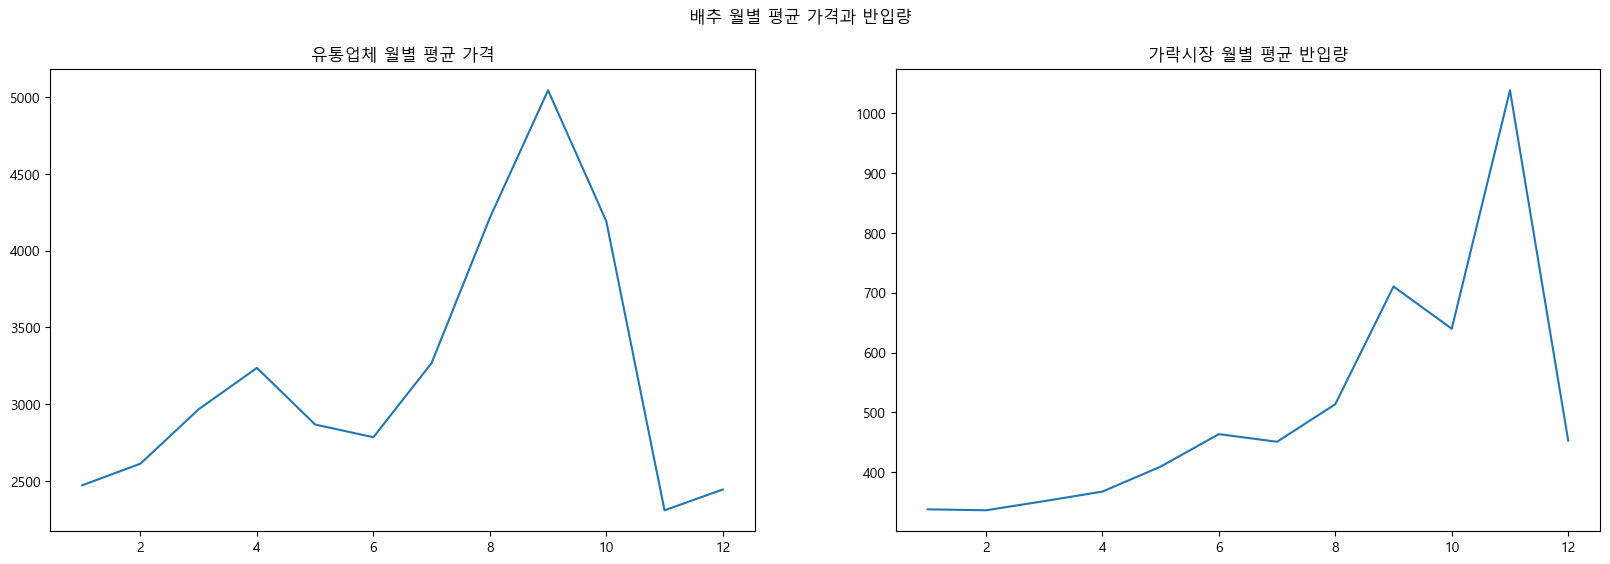

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# ax[0]
x00 = df.groupby('월').agg(월별_평균가격=('유통업체가격', 'mean')).index
y00 = df.groupby('월').agg(월별_평균가격=('유통업체가격', 'mean'))['월별_평균가격']
ax[0].plot(x00, y00)
ax[0].set_title('유통업체 월별 평균 가격')

# ax[1]
x01 = df.groupby('월').agg(월별_평균가격=('가락시장반입량', 'mean')).index
y01 = df.groupby('월').agg(월별_평균가격=('가락시장반입량', 'mean'))['월별_평균가격']
ax[1].plot(x01, y01)
ax[1].set_title('가락시장 월별 평균 반입량')

# 전체 제목
fig.suptitle('배추 월별 평균 가격과 반입량')
plt.show()

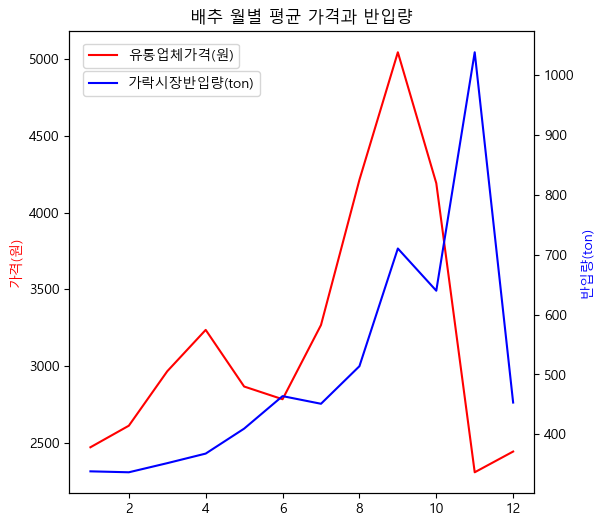

In [76]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean')).index
y= df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean'))
ax1.plot(x, y, color='red', label='유통업체가격(원)')

ax2 = ax1.twinx()
x2 = df.groupby('월').agg(월별_평균가격 = ('가락시장반입량', 'mean')).index
y2 = df.groupby('월').agg(월별_평균가격 = ('가락시장반입량', 'mean'))
ax2.plot(x2, y2, color='blue', label='가락시장반입량(ton)')

ax1.set_ylabel('가격(원)', color='red')
ax2.set_ylabel('반입량(ton)', color='blue')

ax1.legend(loc= (0.03, 0.92))
ax2.legend(loc= (0.03, 0.86))

plt.title('배추 월별 평균 가격과 반입량')
plt.show()

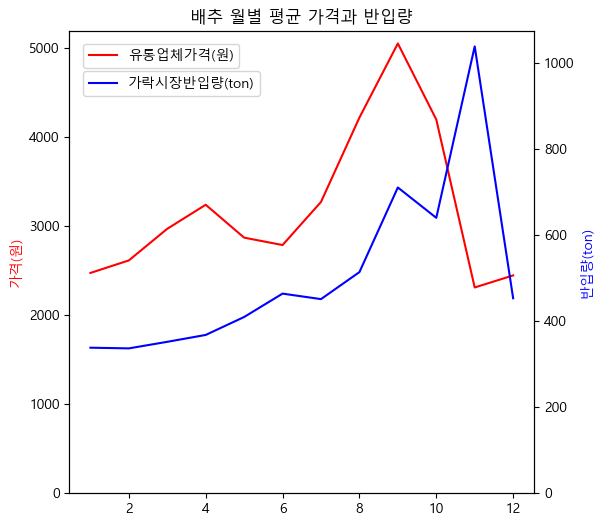

In [108]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean')).index
y= df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean'))
ax1.plot(x, y, color='red', label='유통업체가격(원)')

ax2 = ax1.twinx()
x2 = df.groupby('월').agg(월별_평균가격 = ('가락시장반입량', 'mean')).index
y2 = df.groupby('월').agg(월별_평균가격 = ('가락시장반입량', 'mean'))
ax2.plot(x2, y2, color='blue', label='가락시장반입량(ton)')

ax1.set_ylim(0)
ax2.set_ylim(0)

ax1.set_ylabel('가격(원)', color='red')
ax2.set_ylabel('반입량(ton)', color='blue')

ax1.legend(loc= (0.03, 0.92))
ax2.legend(loc= (0.03, 0.86))

plt.title('배추 월별 평균 가격과 반입량')
plt.show()

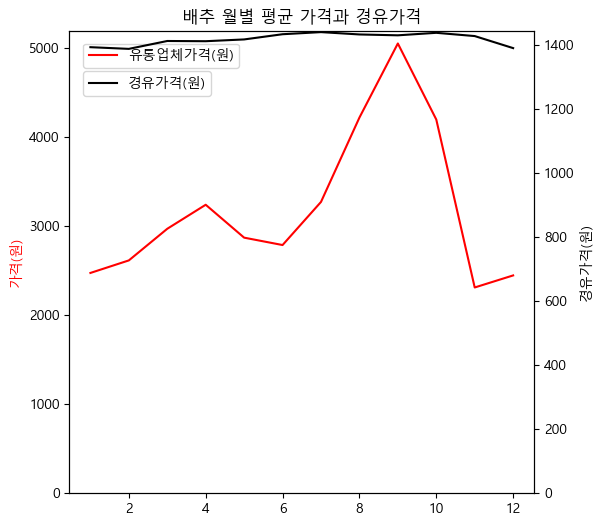

In [26]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean')).index
y= df.groupby('월').agg(월별_평균가격 = ('유통업체가격', 'mean'))
ax1.plot(x, y, color='red', label='유통업체가격(원)')

ax2 = ax1.twinx()
x2 = df.groupby('월').agg(월별_평균가격 = ('경유가격', 'mean')).index
y2 = df.groupby('월').agg(월별_평균가격 = ('경유가격', 'mean'))
ax2.plot(x2, y2, color='black', label='경유가격(원)')

ax1.set_ylim(0)
ax2.set_ylim(0)

ax1.set_ylabel('가격(원)', color='red')
ax2.set_ylabel('경유가격(원)', color='black')

ax1.legend(loc= (0.03, 0.92))
ax2.legend(loc= (0.03, 0.86))

plt.title('배추 월별 평균 가격과 경유가격')
plt.show()

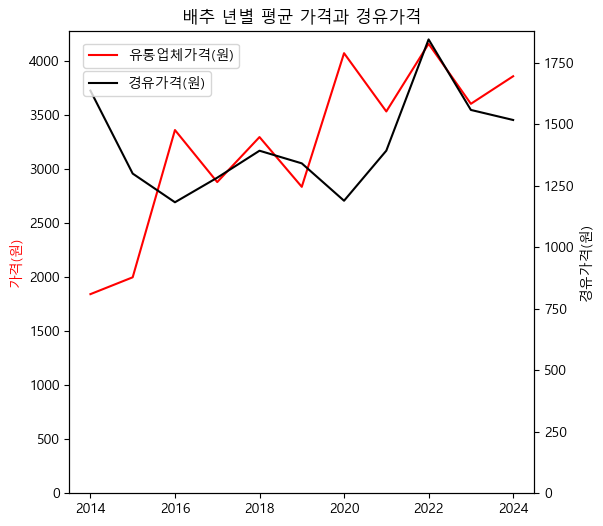

In [27]:
fig, ax1 = plt.subplots(figsize=(6, 6))

x = df.groupby('년').agg(월별_평균가격 = ('유통업체가격', 'mean')).index
y= df.groupby('년').agg(월별_평균가격 = ('유통업체가격', 'mean'))
ax1.plot(x, y, color='red', label='유통업체가격(원)')

ax2 = ax1.twinx()
x2 = df.groupby('년').agg(월별_평균가격 = ('경유가격', 'mean')).index
y2 = df.groupby('년').agg(월별_평균가격 = ('경유가격', 'mean'))
ax2.plot(x2, y2, color='black', label='경유가격(원)')

ax1.set_ylim(0)
ax2.set_ylim(0)

ax1.set_ylabel('가격(원)', color='red')
ax2.set_ylabel('경유가격(원)', color='black')

ax1.legend(loc= (0.03, 0.92))
ax2.legend(loc= (0.03, 0.86))

plt.title('배추 년별 평균 가격과 경유가격')
plt.show()